In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.float_format', '{:.5e}'.format)

In [2]:
eta_list=["-1.00","-0.75","-0.50","-0.25","0.00","0.25","0.50","0.75","1.00"]

for J in ["0.14","0.2","0.28","0.4"]:
    for N in ["200","400","800","1600","3200","6400"]:
        fn = f'../Desktop/KuramotoData/data_MLE_J{J}/N{N}_finite_MLE.dat'
        sorted_fn = f'../Desktop/KuramotoData/data_MLE_J{J}/sorted_N{N}_finite_MLE.dat'
        with open(fn,'r') as first_file:
            rows = first_file.readlines()
            sorted_rows = sorted(rows, key=lambda x: (eta_list.index(x.split()[1]),int(x.split()[0])), reverse=False)
            with open(sorted_fn,'w') as second_file:
                for row in sorted_rows:
                    second_file.write(row)

# Some general coding functions

In [2]:
import warnings
def handle_warning(message, category, filename, lineno, file=None, line=None):
    print('A warning occurred:')
    print(message)
"""
    print('Do you wish to continue?')

    while True:
        response = input('y/n: ').lower()
        if response not in {'y', 'n'}:
            print('Not understood.')
        else:
            break

    if response == 'n':
        raise category(message)

warnings.showwarning = handle_warning
""";

In [15]:
def generate_colormap(n, palette_type="continuous"):
    """
    Generate a colormap depending on dataset size.

    Parameters
    ----------
    n : int
        Number of distinct values in the dataset
    palette_type : str
        'auto', 'categorical', or 'continuous'

    Returns
    -------
    list of colors (RGBA tuples)
    """

    if n <= 0:
        raise ValueError("n must be a positive integer")

    # Auto mode: choose based on size
    if palette_type == "auto":
        if n <= 20:
            palette_type = "categorical"
        else:
            palette_type = "continuous"

    if palette_type == "categorical":
        # Use high-quality categorical palettes
        base_cmaps = ["tab10", "tab20", "Set3"]
        cmap_name = base_cmaps[min(len(base_cmaps) - 1, n // 10)]
        cmap = plt.get_cmap(cmap_name)
        colors = [cmap(i % cmap.N) for i in range(n)]

    elif palette_type == "continuous":
        # Perceptually uniform colormap
        cmap = plt.get_cmap("rainbow")
        colors = [cmap(i) for i in np.linspace(0, 1, n)]

    else:
        raise ValueError("palette_type must be 'auto', 'categorical', or 'continuous'")

    return colors

# Checks for trajectories and tangent space evolution.

## Check temalization and transition times for the simulations

This corresponds to modes 0 and 2 in the kuramoto simulation for the trajectories global order parameter termalization and the tangent space termalization respectively.

### Global order termalization (m=0)

In [3]:
filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/dataT/"

200


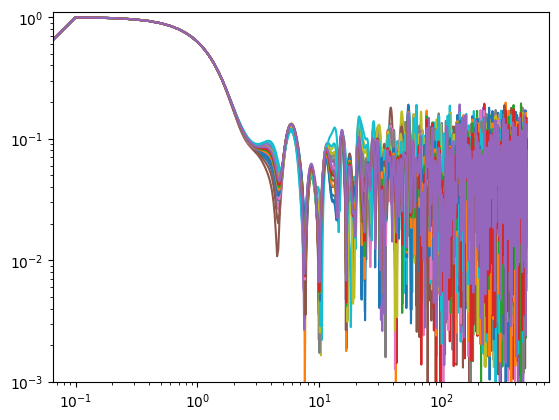

400


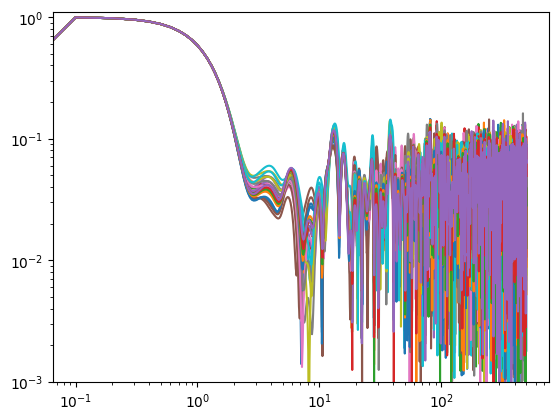

800


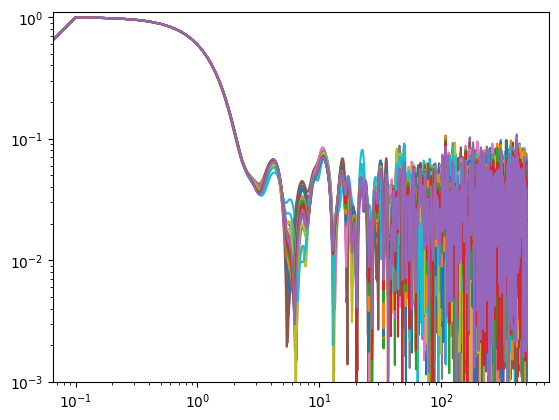

1600


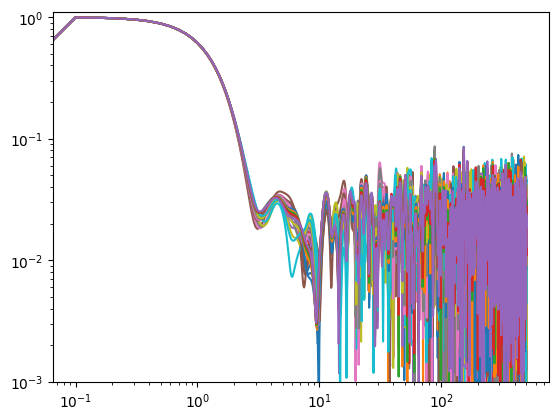

3200


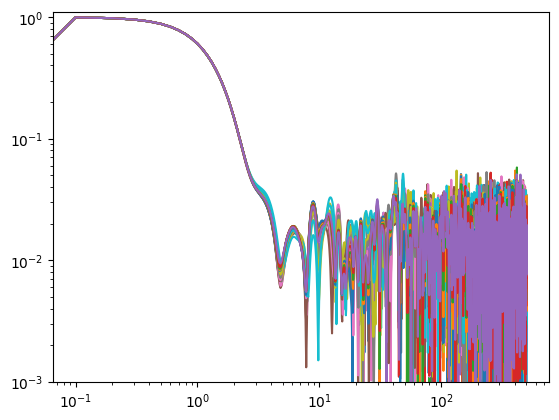

6400


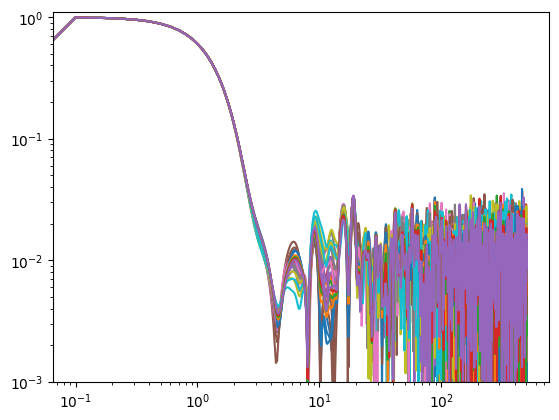

In [5]:
J_list=["0.1","0.2","0.07","0.14","0.05"]
N_list=[200,400,800,1600,3200,6400]
eta_list = ["-1.00","-0.50","0.00","0.50","1.00"]

for N in N_list:
    print(N)
    for J in J_list:
        
        for e in eta_list:
            strfile=f"N{N:d}/J{J}_e{e}"
            times=np.fromfile(filebase+strfile+"_times.dat",dtype=np.float64)
            r=np.fromfile(filebase+strfile+'_order.dat',dtype=np.float64)
        
            plt.plot(times,r)
    plt.yscale("log")            
    plt.xscale("log")
    plt.ylim(1e-3,1.1)
    plt.show()

We can easily conclude that the system starts termalizing for all J, $\eta$ and N at the **100 simulation time units**.

### Tangent space thermalization (m=1)

I'm checking the termalization using the $\log(\lvert\delta\theta\rvert)$ since it is much easier to observe the point where the system reaches a steady state.

For lower values of J, it takes longer to reach thermalization since the dynamics of the system slows down. Probably in a quadratic way, be carefull!

<div class="alert alert-block alert-warning">
Might need avoid N=200 since it gives a Lyapunov exponent lower than the rest (probably because of relevant finite size effects)
</div>

In [35]:
from scipy.stats import moment, kurtosis,skew

filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/"

J_list=["0.05","0.07","0.1","0.14","0.2"]#["0.1","0.2","0.07","0.14","0.05"]
N_list=[200,400,800,1600,3200,6400]
eta_list = ["-1.00","-0.50","0.00","0.50","1.00"]

J=0.05
N=200
N=400
N=800
N=1600
N=3200
N=6400


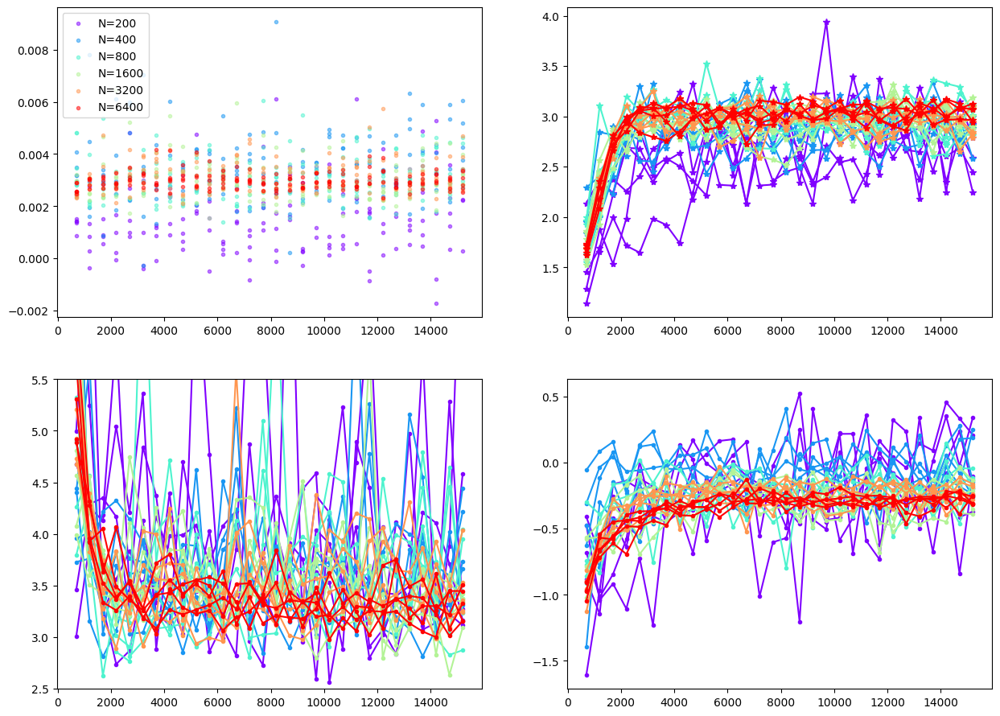

J=0.07
N=200
N=400
N=800
N=1600
N=3200
N=6400


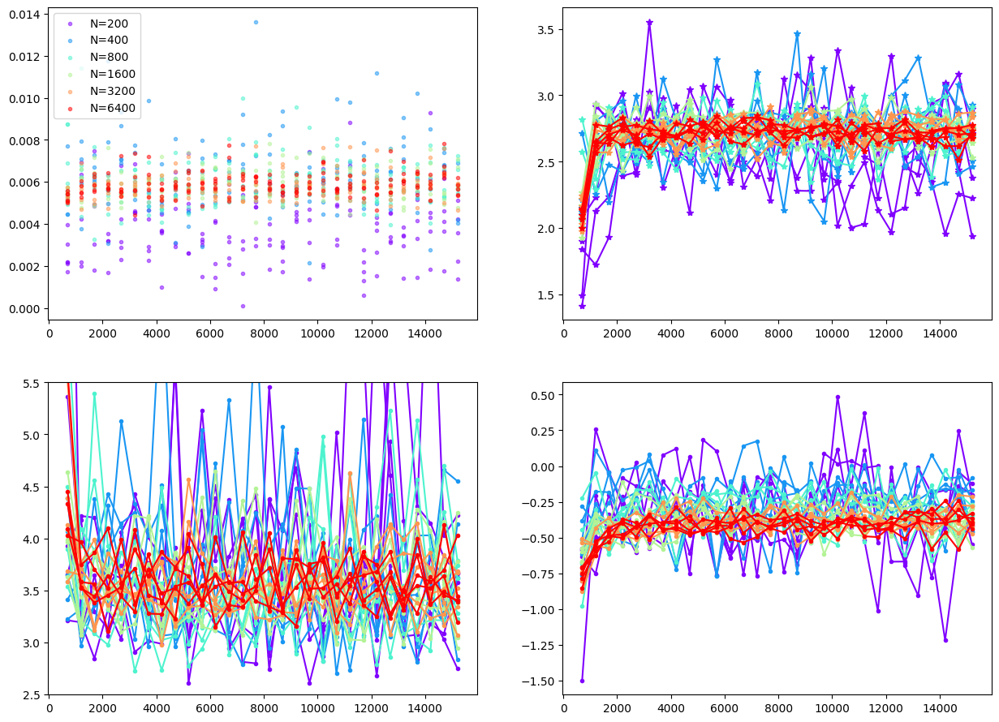

J=0.1
N=200
N=400
N=800
N=1600
N=3200
N=6400


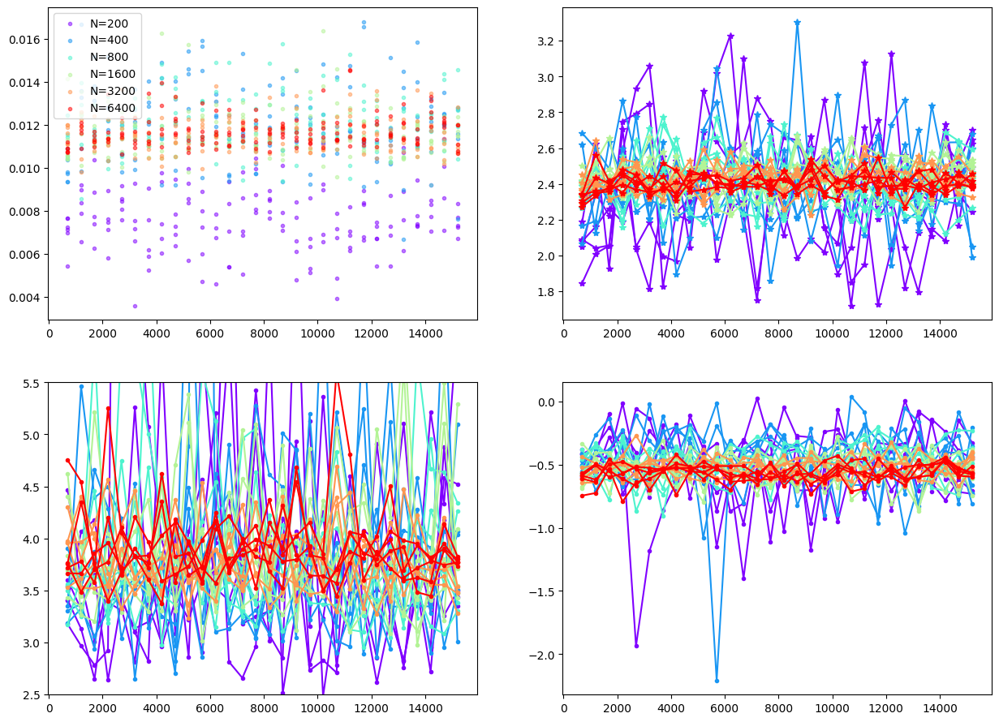

J=0.14
N=200
N=400
N=800
N=1600
N=3200
N=6400


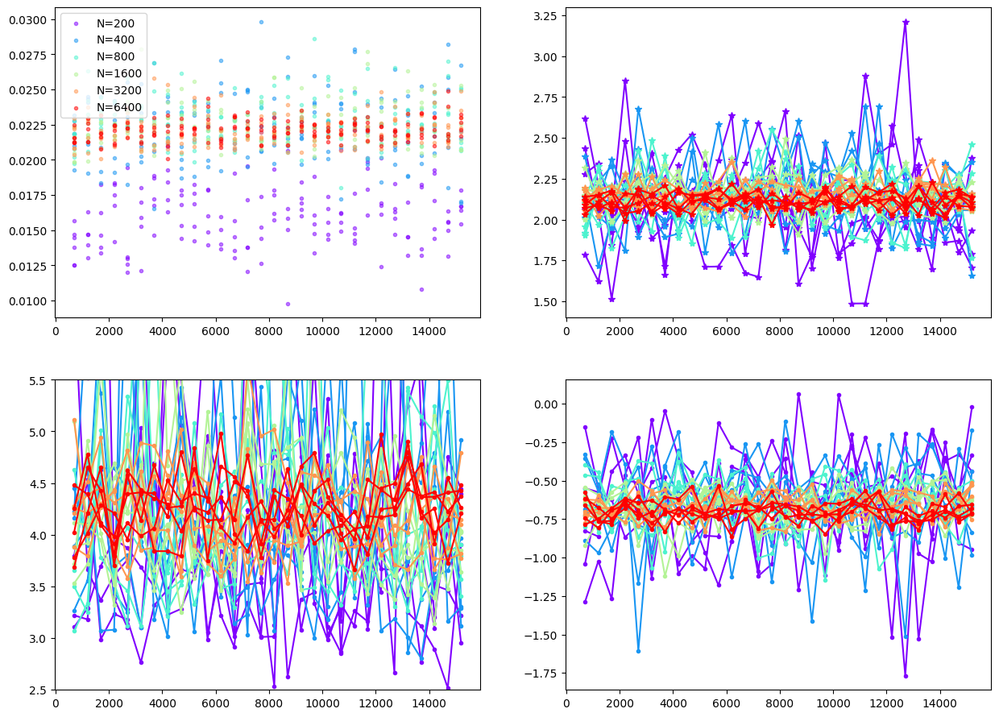

J=0.2
N=200
N=400
N=800
N=1600
N=3200
N=6400


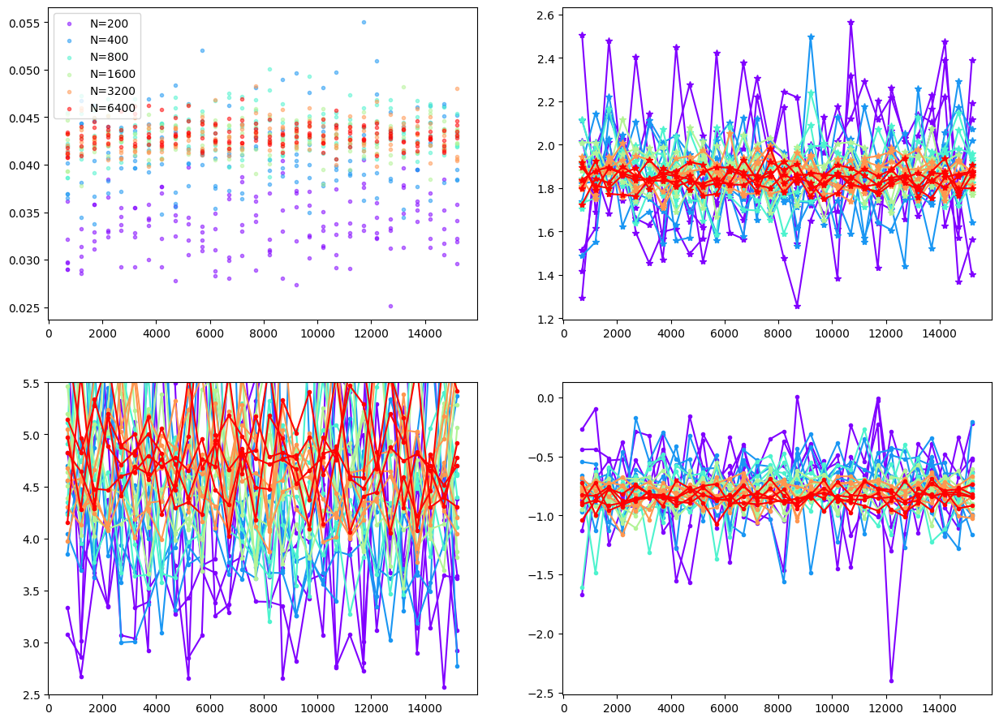

In [37]:
cmap = generate_colormap(len(N_list), palette_type="continuous")

for J in J_list:
    print(f"J={J}")
    fig,axs=plt.subplots(2,2,figsize=(15,11))
    for i in range(len(N_list)):
        N=N_list[i]
        print(f"N={N}")
        for e in eta_list:
            try:
                tlimit=0
                Tout=np.fromfile(filebase+f"dataLV/N{N:d}/J{J}_e{e}_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)
                mle=Tout[tlimit:,2*N+1]
                times=Tout[tlimit:,2*N]
                dtheta=Tout[tlimit:,N:2*N]

                axs[0,0].scatter(times,mle,color=cmap[i],alpha=0.5,marker=".")
                #plt.hist(np.log(np.abs(dtheta[1,:])),bins=100)
                axs[0,1].plot(times,np.var(np.log(np.abs(dtheta)),axis=1),color=cmap[i],marker="*")
                axs[1,0].plot(times,kurtosis(np.log(np.abs(dtheta)),fisher=False,axis=1),color=cmap[i],marker=".")
                axs[1,1].plot(times,skew(np.log(np.abs(dtheta)),axis=1),color=cmap[i],marker=".")
            except Exception as err:
                print(f"Unexpected {err=}, {type(err)=}")
        axs[0,0].scatter(times[0],mle[0],color=cmap[i],alpha=0.5,marker=".",label=f"N={N}")
    axs[0,0].legend(loc="upper left")
    axs[1,0].set_ylim(2.5,5.5)
#    axs[1,1].set_ylim(0,-1.5)
#     axs[0,1].set_ylim(1.5,3.5)
    #plt.setp(axs, xlim=(0,1200))#,xscale="log")
    plt.show()

## Overview of the Maximum Exponent Lyapunov vector and its dynamics

This is a draft on how the Lyapunov vector changes over time-units. To do this we look at the projection between two normalized vectors separated a specific amount of time.
We observe that the dynamics (proyection) slow down with ~J^2 (as expected) and after a long time the Lyapunov exponents become uncorrelated.

In [129]:
filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/ttrans5000/"

J_list=["0.1","0.05"]
N_list=[200,400,800,1600,3200,6400,12800]
eta_list = ["0"]#["-1","-0.5","0","0.5","1"]

cmap = generate_colormap(len(N_list), palette_type="continuous")

data=[]
for J in J_list:
    print(f"J={J}")
    dataN=[]
    for i in range(len(N_list)):
        N=N_list[i]
        print(f"N={N}")
        datae=[]
        for e in eta_list:
#            print(f"$\\eta={e}$")
            try:
                Tout=np.fromfile(filebase+f"dataLV2/N{N:d}/J{J}_e{e}_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)
                freq=np.fromfile(filebase+f"dataLV2/N{N:d}/J{J}_e{e}_freq.dat",dtype=np.float64)
                
                times=Tout[:,2*N]
                dtheta=Tout[:,N:2*N]
                dtheta0=np.mean(dtheta,axis=0)
                
                idxFreq=np.argsort(freq)
                #plt.plot(np.arange(0,N),dtheta[0,idxFreq],label=f"$\\eta={e}$")
                #plt.plot(np.arange(0,N),dtheta[1,idxFreq])
    
                dot0last=np.vdot(dtheta[0,idxFreq],dtheta[-1,idxFreq])
                s=f"Ini->Last: {dot0last:.5f} "
                for t in range(1,6):
                    a=[]
                    for j in range(len(times)-t):
                        a.append(np.vdot(dtheta[j,idxFreq],dtheta[j+t,idxFreq]))
                    dot01=np.mean(a)

                    s+=f"\t j->j+{t}: {dot01:.5f}"
                    
                print(s)
                datae.append([e,dot0last,dot01])
            except Exception as err:
                print(f"Unexpected {err=}, {type(err)=}")
        dataN.append([N,datae])
    data.append([J,dataN])
    print("")
        #plt.legend(loc="upper left")
        #plt.xlim(5900,6100)
        #plt.ylim(-0.05,0.05)
        #plt.show()

J=0.1
N=200
Ini->Last: -0.05548 	 j->j+1: 0.17932	 j->j+2: 0.00876	 j->j+3: 0.08550	 j->j+4: 0.00895	 j->j+5: -0.08535
N=400
Ini->Last: 0.12760 	 j->j+1: 0.07180	 j->j+2: -0.05394	 j->j+3: 0.02912	 j->j+4: 0.02234	 j->j+5: 0.00900
N=800
Ini->Last: -0.01088 	 j->j+1: 0.10884	 j->j+2: 0.00435	 j->j+3: 0.02205	 j->j+4: 0.01188	 j->j+5: -0.00028
N=1600
Ini->Last: 0.02463 	 j->j+1: 0.11819	 j->j+2: 0.02493	 j->j+3: 0.00542	 j->j+4: 0.02351	 j->j+5: -0.00816
N=3200
Ini->Last: -0.00019 	 j->j+1: 0.08988	 j->j+2: 0.03040	 j->j+3: -0.00450	 j->j+4: 0.01482	 j->j+5: -0.00380
N=6400
Ini->Last: 0.01278 	 j->j+1: 0.09748	 j->j+2: 0.00664	 j->j+3: -0.00307	 j->j+4: -0.00390	 j->j+5: -0.00647
N=12800
Ini->Last: -0.01882 	 j->j+1: 0.10068	 j->j+2: 0.00926	 j->j+3: 0.00659	 j->j+4: -0.00290	 j->j+5: 0.00528

J=0.05
N=200
Ini->Last: -0.09230 	 j->j+1: 0.57827	 j->j+2: 0.33544	 j->j+3: 0.17367	 j->j+4: -0.01223	 j->j+5: -0.10643
N=400
Ini->Last: -0.00428 	 j->j+1: 0.49663	 j->j+2: 0.24151	 j->j+3: 0.0840

## Dependency of absolute value of Lyapunov component with frequency $\omega$

There is a **NOT** normal (maybe lorentzian, idk) dependency between the component of the tangent space and the natural frequency distribution.
Overall, the Lyapunov vector alignes with oscillators that have a closer to 0 natural frequency.

J=0.1
N=200


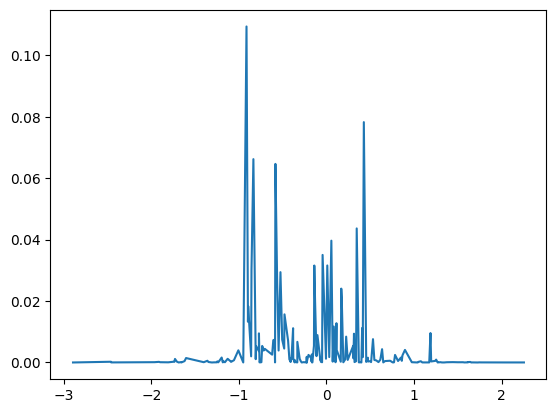

N=400


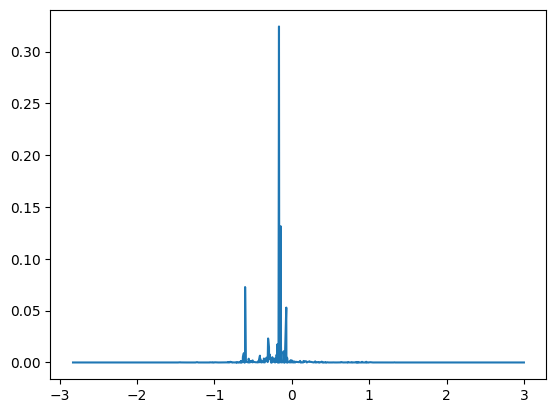

N=800


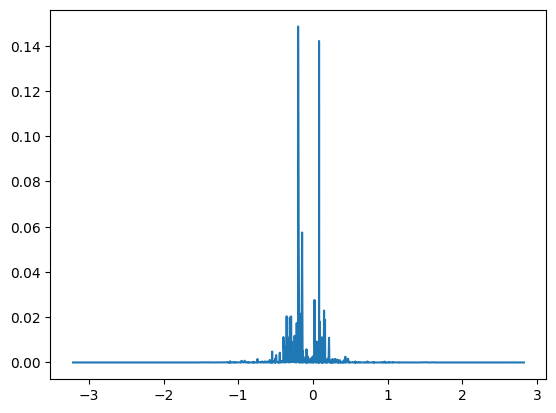

N=1600


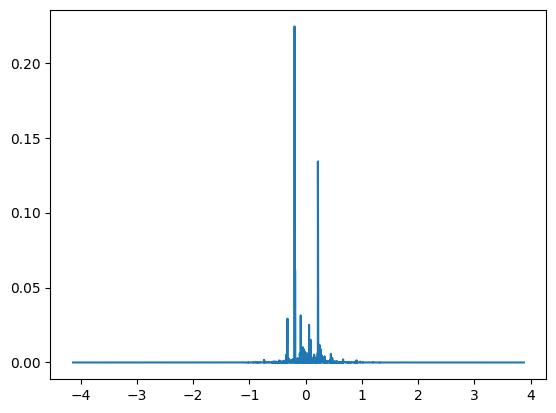

N=3200


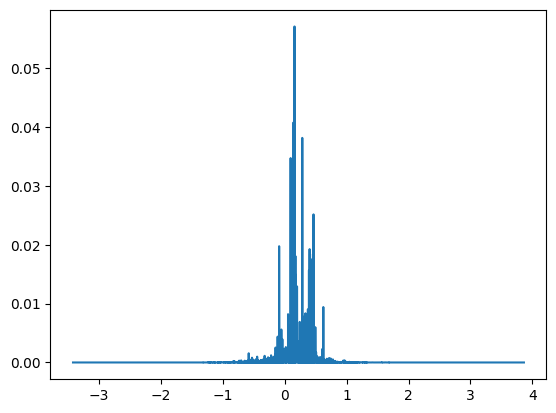

N=6400


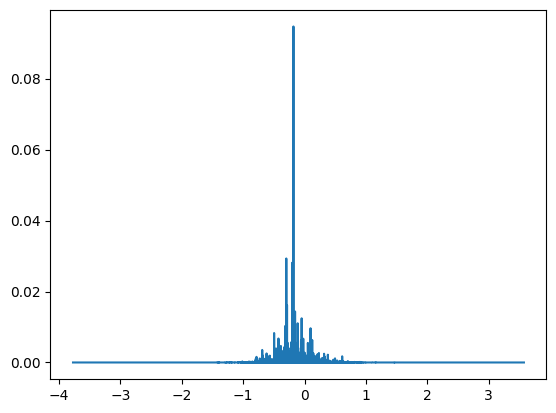

N=12800


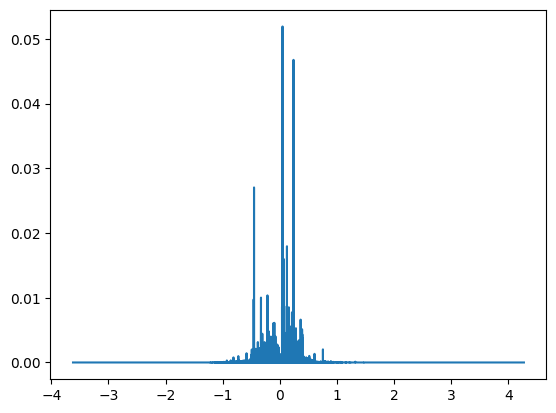

In [11]:
filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/ttrans5000/"

J_list=["0.1"]#,"0.05"]
N_list=[200,400,800,1600,3200,6400,12800]
eta_list = ["0"]#["-1","-0.5","0","0.5","1"]

cmap = generate_colormap(len(N_list), palette_type="continuous")

data=[]
for J in J_list:
    print(f"J={J}")
    dataN=[]
    for i in range(len(N_list)):
        N=N_list[i]
        print(f"N={N}")
        datae=[]
        for e in eta_list:
#            print(f"$\\eta={e}$")
            try:
                Tout=np.fromfile(filebase+f"dataLV2/N{N:d}/J{J}_e{e}_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)
                freq=np.fromfile(filebase+f"dataLV2/N{N:d}/J{J}_e{e}_freq.dat",dtype=np.float64)
                
                times=Tout[:,2*N]
                dtheta=Tout[:,N:2*N]
                dtheta0=np.mean(dtheta,axis=0)
                
                idxFreq=np.argsort(freq)
                #plt.plot(np.arange(0,N),dtheta[0,idxFreq],label=f"$\\eta={e}$")
                #plt.plot(np.arange(0,N),dtheta[1,idxFreq])

                #plt.plot(freq[idxFreq],np.mean(np.abs(dtheta[:,idxFreq])**2,axis=0))#,label=f"$\\eta={e}$")
                plt.plot(freq[idxFreq],np.abs(dtheta[1,idxFreq])**2)
                #plt.plot(freq[idxFreq],dtheta[1,idxFreq])
    
                dot0last=np.vdot(dtheta[0,idxFreq],dtheta[-1,idxFreq])
                s=f"Ini->Last: {dot0last:.5f} "
                for t in range(1,6):
                    a=[]
                    for j in range(len(times)-t):
                        a.append(np.vdot(dtheta[j,idxFreq],dtheta[j+t,idxFreq]))
                    dot01=np.mean(a)

                    s+=f"\t j->j+{t}: {dot01:.5f}"
                    
               # print(s)
                A=np.column_stack((freq[idxFreq],np.abs(dtheta[1,idxFreq])**2))
                #np.savetxt(f"N{N}_freq_dtheta.dat", A,fmt='%.5e')
                datae.append([e,dot0last,dot01])
            except Exception as err:
                print(f"Unexpected {err=}, {type(err)=}")
        dataN.append([N,datae])
        #plt.legend(loc="upper left")
        #plt.xlim(5900,6100)
        #plt.ylim(-0.05,0.05)
        plt.show()
    data.append([J,dataN])
    print("")
        

J=0.1
N=6400
N=12800
J=0.05
N=6400
N=12800


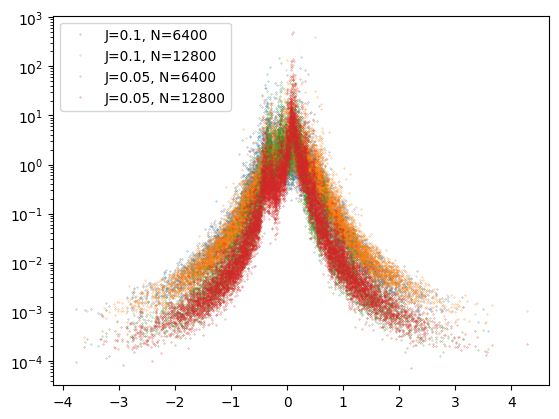

In [4]:
filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/ttrans5000/"

J_list=["0.1","0.05"]
N_list=[6400,12800]#[200,400,800,1600,3200,6400,12800]
eta_list = ["0"]#["-1","-0.5","0","0.5","1"]

cmap = generate_colormap(len(N_list), palette_type="continuous")

data=[]
for J in J_list:
    print(f"J={J}")
    dataN=[]
    for i in range(len(N_list)):
        N=N_list[i]
        print(f"N={N}")
        datae=[]
        for e in eta_list:
#            print(f"$\\eta={e}$")
            try:
                Tout=np.fromfile(filebase+f"dataLV2/N{N:d}/J{J}_e{e}_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)
                freq=np.fromfile(filebase+f"dataLV2/N{N:d}/J{J}_e{e}_freq.dat",dtype=np.float64)
                
                times=Tout[:,2*N]
                dtheta=Tout[:,N:2*N]
                dtheta0=np.mean(dtheta,axis=0)
                
                idxFreq=np.argsort(freq)
                #plt.plot(np.arange(0,N),dtheta[0,idxFreq],label=f"$\\eta={e}$")
                #plt.plot(np.arange(0,N),dtheta[1,idxFreq])

                plt.semilogy(freq[idxFreq],N*np.mean(np.abs(dtheta[:,idxFreq])**2,axis=0),".",markersize=0.5,label=f"J={J}, N={N:d}",alpha=0.8)
                
                
            except Exception as err:
                print(f"Unexpected {err=}, {type(err)=}")
                
    plt.legend(loc="upper left")
        #plt.xlim(5900,6100)
        #plt.ylim(-0.05,0.05)
plt.show()
#    data.append([J,dataN])
#    print("")
        

In [5]:
from matplotlib.lines import Line2D

[0.01171859 0.01268368 0.01166962 0.01124855 0.01121692 0.01182259
 0.01206993 0.01223881 0.01181812 0.01093844 0.01164621 0.01146517
 0.01121105 0.01218033 0.0115346  0.01213737 0.01110396 0.013124
 0.01204418 0.01109363]
[0.0427794  0.04240953 0.04172955 0.04469923 0.04344505 0.04478891
 0.04198925 0.04302949 0.04335241 0.04477274 0.04576013 0.04188525
 0.04421574 0.04243889 0.04309432 0.0424969  0.04460762 0.04296022
 0.04131387 0.04350293]
[0.00653179 0.00592343 0.00509137 0.00639431 0.00526261 0.00593365
 0.00535462 0.00549272 0.00600428 0.00696504 0.00550826 0.0063217
 0.00522851 0.00541096 0.00550099 0.00605122 0.00540697 0.00568874
 0.00630679 0.00583481]
[0.02285909 0.02134464 0.02318865 0.02226828 0.02216148 0.02229452
 0.0219213  0.02274182 0.02169465 0.02164262 0.02177095 0.02247192
 0.02136609 0.02234406 0.022161   0.02177693 0.0215698  0.0216875
 0.02166377 0.02297635]
[0.00255367 0.00271578 0.00295345 0.00293869 0.00313325 0.00250258
 0.00284633 0.00290427 0.00293609 0.0

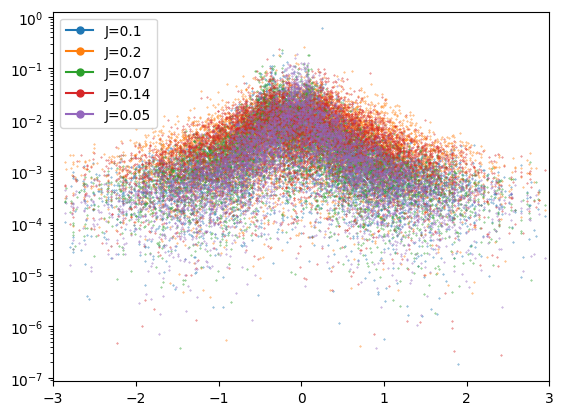

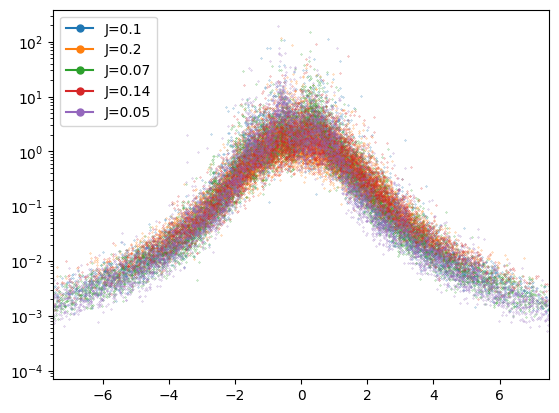

In [32]:
filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/"

J_list=["0.1","0.2","0.07","0.14","0.05"]
N_list=[6400]#[200,400,800,1600,3200,6400]
eta_list=["0.00"]#["-1.00","-0.50","0.00","0.50","1.00"]
cmap = generate_colormap(len(J_list), palette_type="categorical")

legend_element=[]
for Ji in range(len(J_list)):
    J=J_list[Ji]
    #print(f"J={J}")
    dataN=[]
    for i in range(len(N_list)):
        N=N_list[i]
        #print(f"N={N}")
        datae=[]
        for e in eta_list:
#            print(f"$\\eta={e}$")
            try:
                Tout=np.fromfile(filebase+f"dataLV/N{N:d}/J{J}_e{e}_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)
                freq=np.fromfile(filebase+f"dataLV/N{N:d}/J{J}_e{e}_freq.dat",dtype=np.float64)
                
                times=Tout[10:,2*N]
                lyap=Tout[10:,-1]
                dtheta=Tout[10:,N:2*N]
                dtheta0=np.mean(dtheta,axis=0)
                print(lyap)
                #print(np.linalg.norm(dtheta,axis=1))
                
                idxFreq=np.argsort(freq)
                #plt.plot(np.arange(0,N),dtheta[0,idxFreq],label=f"$\\eta={e}$")
                #plt.plot(np.arange(0,N),dtheta[1,idxFreq])
                #for a in range(len(times)):
                #    plt.scatter(freq[idxFreq],N*np.abs(dtheta[a,idxFreq]**2),marker=".",color=cmap[Ji],s=0.5,alpha=0.8)

                plt.scatter(freq[idxFreq],np.abs(dtheta[1,idxFreq]),marker=".",color=cmap[Ji],s=0.5,alpha=0.8)
                
                #A=np.column_stack((freq[idxFreq],dtheta[:,idxFreq].T))
                #np.savetxt(f"Lvec_data/J{J}_N{N:d}_freq_dtheta.dat", A,fmt='%.5e')
                legend_element.append(Line2D([0], [0], marker='o', color=cmap[Ji],label=f"J={J}", markersize=5))
                
            except Exception as err:
                print(f"Unexpected {err=}, {type(err)=}")
                
plt.legend(handles=legend_element,loc="upper left")
plt.yscale("log")
plt.xlim(-3,3)
plt.show()

legend_element=[]
for Ji in range(len(J_list)):
    J=J_list[Ji]
    #print(f"J={J}")
    dataN=[]
    for i in range(len(N_list)):
        N=N_list[i]
        #print(f"N={N}")
        datae=[]
        for e in eta_list:
#            print(f"$\\eta={e}$")
            try:
                Tout=np.fromfile(filebase+f"dataLV/N{N:d}/J{J}_e{e}_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)
                freq=np.fromfile(filebase+f"dataLV/N{N:d}/J{J}_e{e}_freq.dat",dtype=np.float64)
                
                times=Tout[10:,2*N]
                dtheta=Tout[10:,N:2*N]
                dtheta0=np.mean(dtheta,axis=0)

                
                idxFreq=np.argsort(freq)
                #plt.plot(np.arange(0,N),dtheta[0,idxFreq],label=f"$\\eta={e}$")
                #plt.plot(np.arange(0,N),dtheta[1,idxFreq])

                plt.plot(freq[idxFreq]/np.sqrt(float(J)),N*np.mean(np.abs(dtheta[:,idxFreq])**2,axis=0),".",color=cmap[Ji],markersize=0.5,alpha=0.8)

                legend_element.append(Line2D([0], [0], marker='o', color=cmap[Ji],label=f"J={J}", markersize=5))
                
            except Exception as err:
                print(f"Unexpected {err=}, {type(err)=}")
                
plt.legend(handles=legend_element,loc="upper left")
plt.xlim(-7.5,7.5)
#plt.ylim(0,10)
plt.yscale("log")
plt.show()
        

## Check for fixed natural frequencies

### Generating frequencies

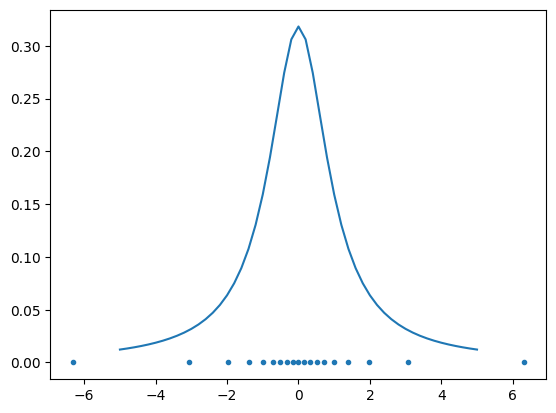

In [42]:
from scipy.stats import cauchy

x=np.linspace(-5,5,num=51)
y=cauchy.pdf(x)

N=20
x2=cauchy.ppf(np.arange(0,1+1/(2*N),1/N))[1:-1]
plt.plot(x,y)
plt.scatter(x2,np.zeros(len(x2)),marker=".")

In [43]:
A=np.repeat(x2,500).astype(np.float64)
A.shape

(9500,)

In [ ]:
from scipy.stats

(array([1.3000000e+01, 9.5000000e+01, 3.9100000e+02, 1.4910000e+03,
        6.0360000e+03, 1.9522000e+04, 5.9619000e+04, 1.6513100e+05,
        4.0499300e+05, 9.0011300e+05, 1.8028720e+06, 3.2471390e+06,
        5.2745100e+06, 7.7079640e+06, 1.0159744e+07, 1.2053000e+07,
        1.2883425e+07, 1.2401842e+07, 1.0753990e+07, 8.4097560e+06,
        5.9289660e+06, 3.7893330e+06, 2.2536560e+06, 1.3894540e+06,
        1.1725220e+06, 1.5956570e+06, 2.6787270e+06, 4.4246740e+06,
        6.7188490e+06, 9.2104130e+06, 1.1398270e+07, 1.2703628e+07,
        1.2749715e+07, 1.1530677e+07, 9.3942860e+06, 6.8945810e+06,
        4.5573070e+06, 2.7115290e+06, 1.4551650e+06, 7.0425600e+05,
        3.0635500e+05, 1.1965700e+05, 4.2290000e+04, 1.3317000e+04,
        3.7880000e+03, 9.9800000e+02, 2.2700000e+02, 4.8000000e+01,
        8.0000000e+00, 1.0000000e+00]),
 array([-7.90169424, -7.57702332, -7.25235239, -6.92768146, -6.60301053,
        -6.2783396 , -5.95366867, -5.62899775, -5.30432682, -4.97965589

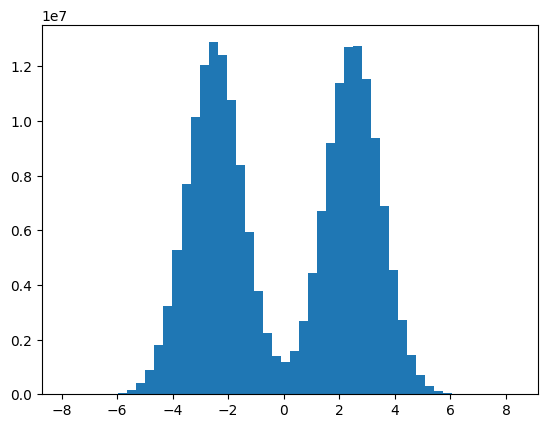

In [96]:
y1=np.random.normal(-2.5,1,int(1e8))
y2=np.random.normal(2.5,1,int(1e8))
y=np.concatenate((y1,y2))
x=np.linspace(-5,5,num=len(y))
plt.hist(y,bins=50)

In [ ]:
sample = np.sort(y)
x, counts = np.unique(sample, return_counts=True)

# [1].81 "the fraction of [observations] that are less than or equal to x
events = np.cumsum(counts)
n = sample.size
cdf = events / n

plt.plot(cdf,n)

In [87]:
#A.tofile("test_freq.dat")

In [88]:
#np.fromfile("test_freq.dat",dtype=np.float64)

array([-2.32634787, -2.32634787, -2.32634787, ...,  2.32634787,
        2.32634787,  2.32634787])

### Lyapunov vector's components

#### $\eta=0$

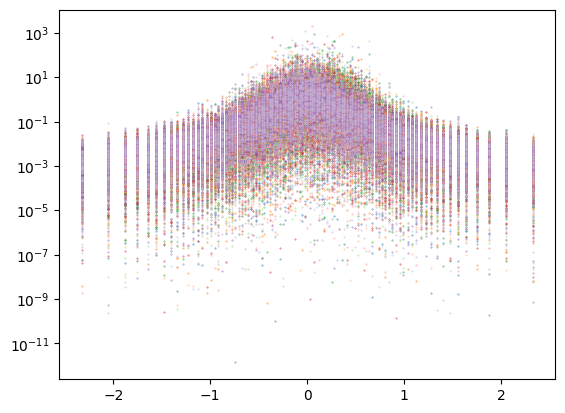

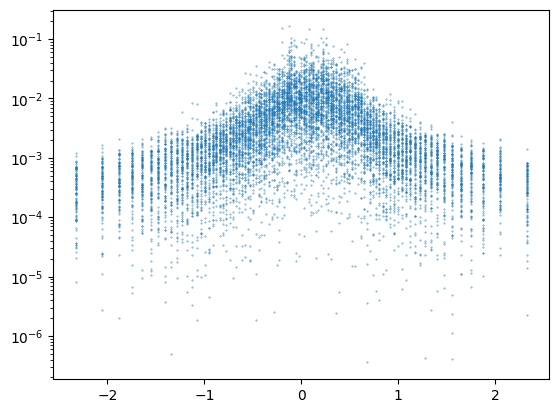

In [14]:
filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/data_wfixed/"

freq=np.fromfile(filebase+f"test_freq.dat",dtype=np.float64)
N=len(freq)
Tout=np.fromfile(filebase+f"test_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)


times=Tout[:,2*N]
lyap=Tout[:,-1]
dtheta=Tout[:,N:2*N]
dtheta0=np.mean(dtheta,axis=0)
idxFreq=np.argsort(freq)

cmap = generate_colormap(len(times), palette_type="categorical")

for a in range(len(times)):
    plt.scatter(freq[idxFreq],N*np.abs(dtheta[a,idxFreq]**2),marker=".",color=cmap[a],s=0.5,alpha=0.8)
plt.yscale("log")
plt.show()
plt.scatter(freq[idxFreq],np.abs(dtheta[0,idxFreq]),marker=".",s=0.5,alpha=0.8)
plt.yscale("log")

In [5]:
np.mean(lyap) ## More or less in the expected range :)

0.010185424227310745

In [15]:
res=dtheta.reshape(-1,99,100) ## Just a separation in dimensions for [time ,n_freq bins,n_osc per freq]
res[:,49,0]

array([-0.00624447,  0.01030631,  0.0034587 , -0.01106141,  0.00053567,
       -0.00342332,  0.01178785,  0.03854714,  0.01777897,  0.00330312])

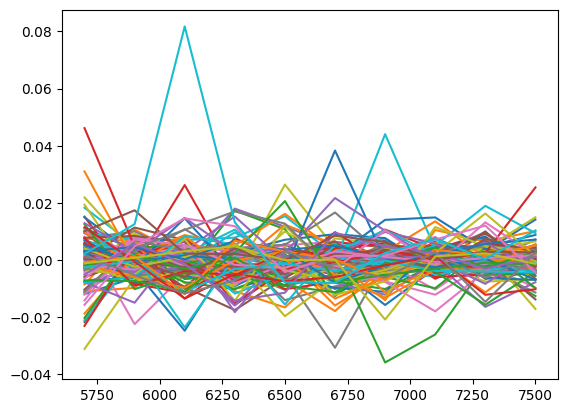

In [16]:
for i in range(100):
    plt.plot(times,res[:,70,i])

In [8]:
freq.reshape(99,100)[49]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

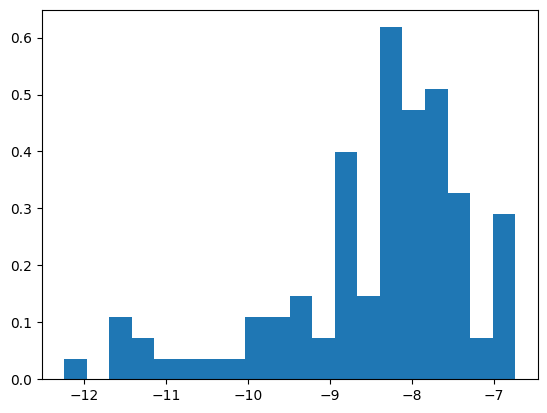

In [19]:
plt.hist(np.log(np.abs(res[-1,0,:])),density=True,bins=20);

In [16]:
from scipy.stats import kurtosis

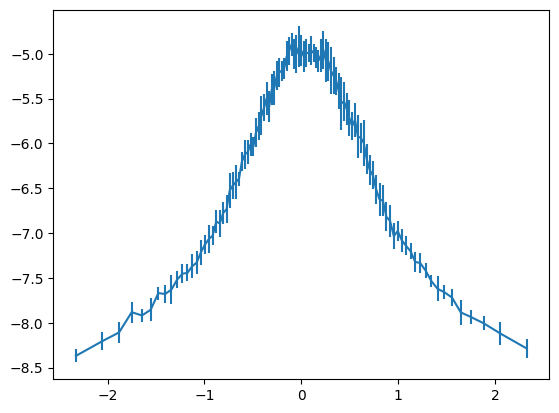

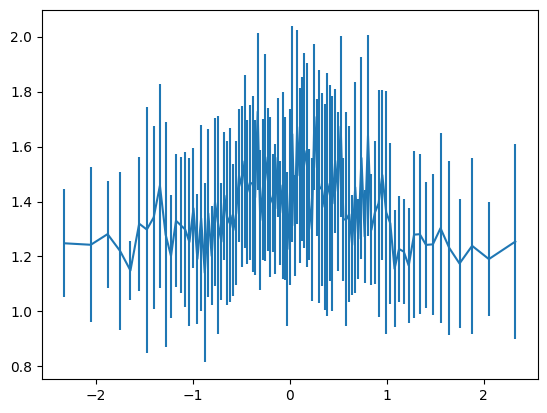

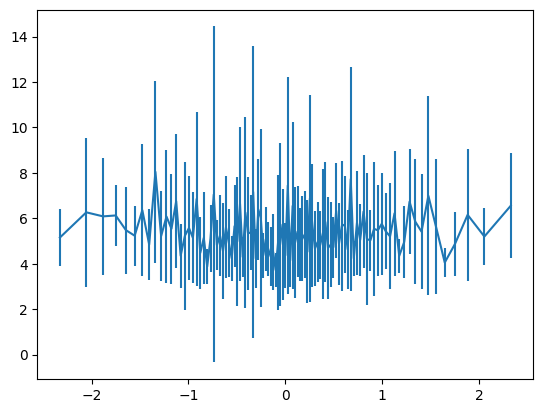

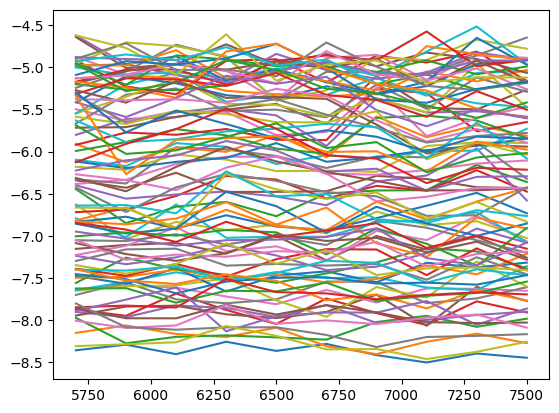

In [17]:
un_freq=np.unique(freq)

mu_list=np.empty((len(un_freq),len(times)))
var_list=np.empty((len(un_freq),len(times)))
k_list=np.empty((len(un_freq),len(times)))

for i in range(len(un_freq)):
    #print(np.unique(freq)[i])
    
    for j in range(len(times)):
        x=np.log(np.abs(res[j,i,:]))
        
        mu=np.mean(x)
        var=np.var(x)
        k=np.mean((x-mu)**4)/var**2
        
        mu_list[i,j]=mu
        var_list[i,j]=var
        k_list[i,j]=k
        
#        print(mu,var,k)
#        print("")

plt.errorbar(un_freq,np.mean(mu_list,axis=1),np.std(mu_list,axis=1))
plt.show()

plt.errorbar(un_freq,np.mean(var_list,axis=1),np.std(var_list,axis=1))
plt.show()

plt.errorbar(un_freq,np.mean(k_list,axis=1),np.std(k_list,axis=1))
plt.show()

for i in range(99):
    plt.plot(times,mu_list[i,:])
plt.show()

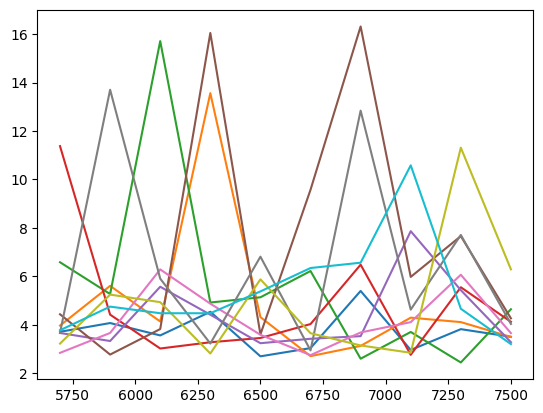

In [18]:
for i in range(45,55):
    plt.plot(times,k_list[i,:])
plt.show()

#### $\eta=-1$

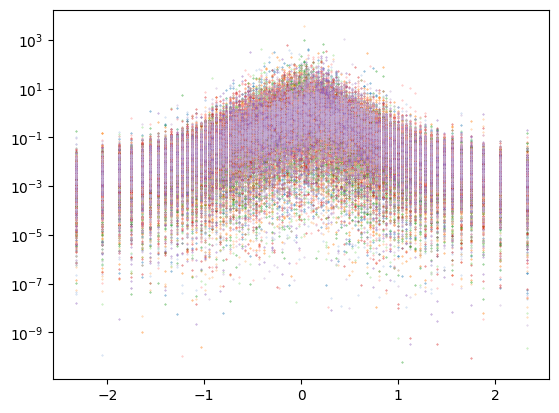

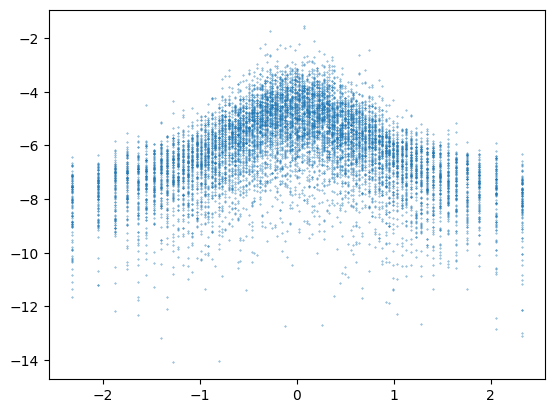

In [29]:
filebase=os.path.expanduser('~')+"/Desktop/data_wfixed/"

freq=np.fromfile(filebase+f"testn1_freq.dat",dtype=np.float64)
N=len(freq)
Tout=np.fromfile(filebase+f"testn1_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)


times=Tout[:,2*N]
lyap=Tout[:,-1]
theta=Tout[:,:N]
dtheta=Tout[:,N:2*N]
dtheta0=np.mean(dtheta,axis=0)
idxFreq=np.argsort(freq)

cmap = generate_colormap(len(times), palette_type="categorical")

for a in range(len(times)):
    plt.scatter(freq[idxFreq],N*np.abs(dtheta[a,idxFreq]**2),marker=".",color=cmap[a],s=0.5,alpha=0.8)
plt.yscale("log")
plt.show()
plt.scatter(freq[idxFreq],np.log(np.abs(dtheta[0,idxFreq])),marker=".",s=0.5,alpha=0.8)
#plt.yscale("log")

In [16]:
idxw0=idxFreq[np.where(freq[idxFreq]==0)]

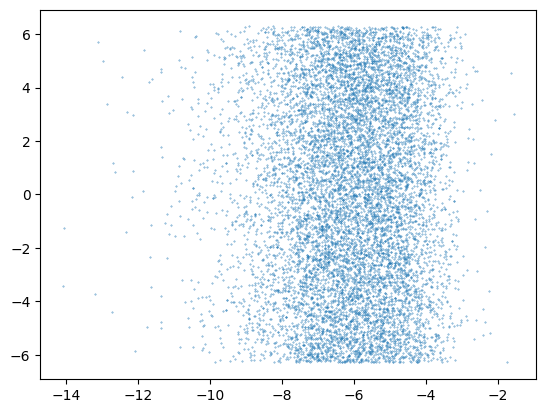

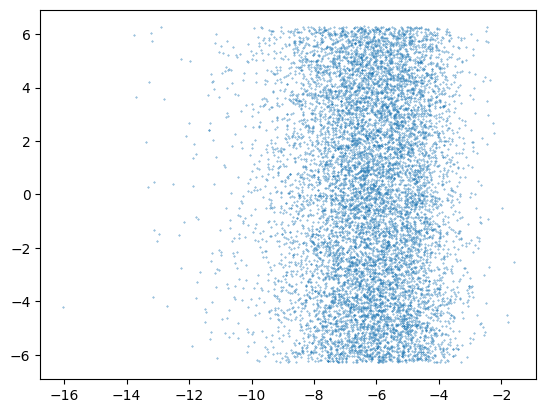

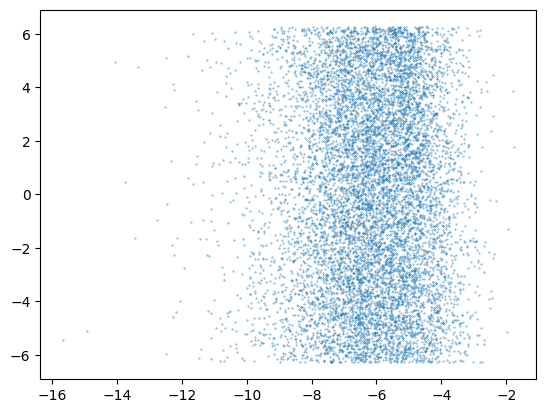

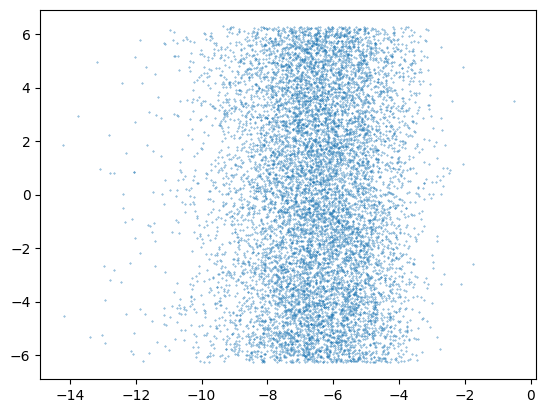

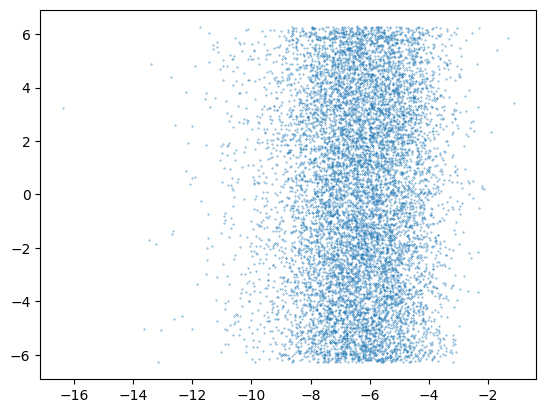

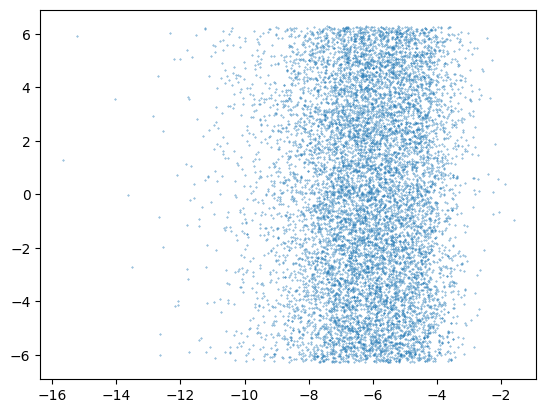

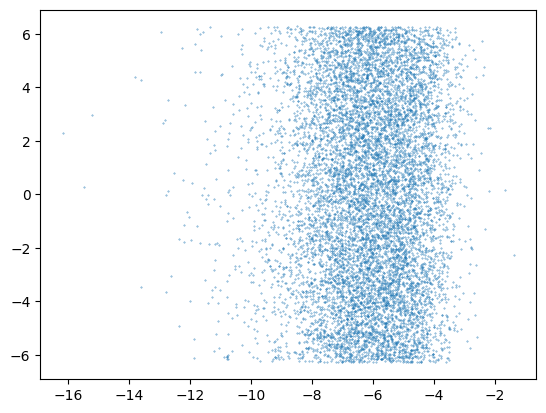

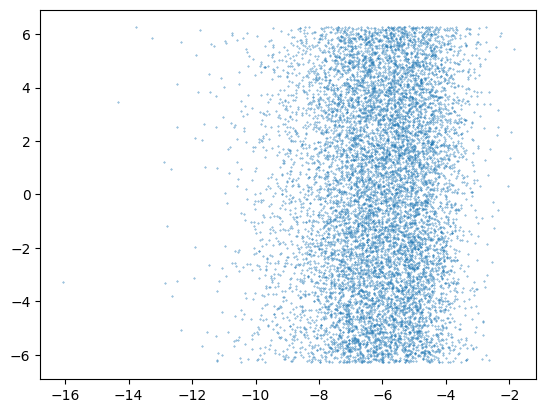

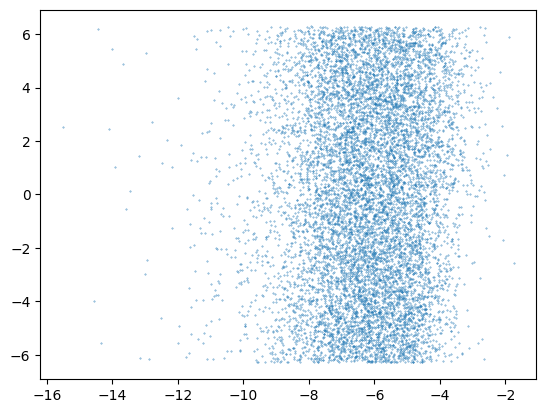

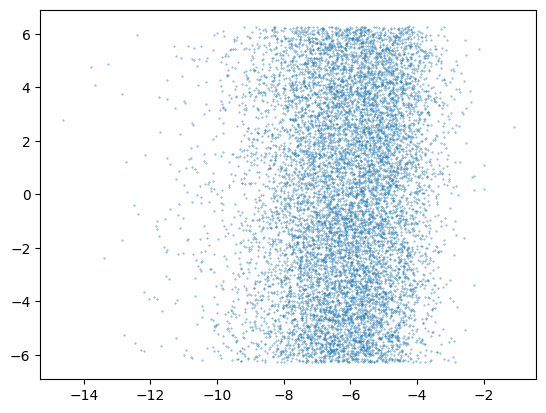

In [32]:
for a in range(len(times)):
    plt.scatter(np.log(np.abs(dtheta[a,idxFreq])),np.fmod(theta[a,idxFreq],2*np.pi),marker=".",s=0.5,alpha=0.8)
    plt.show()
#plt.xscale("log")

In [52]:
np.corrcoef(dtheta[:,idxw0],rowvar=False).shape#-np.eye(len(idxw0))#,axis=0)

(100, 100)

In [21]:
np.mean(lyap) ## More or less in the expected range :)

0.011751719597896148

In [22]:
res=dtheta.reshape(-1,99,100) ## Just a separation in dimensions for [time ,n_freq bins,n_osc per freq]
res[:,49,0]

array([ 0.00575254, -0.00801935,  0.04196481,  0.0446146 ,  0.01282273,
       -0.00232633, -0.01466018, -0.00737156, -0.00884952, -0.00691488])

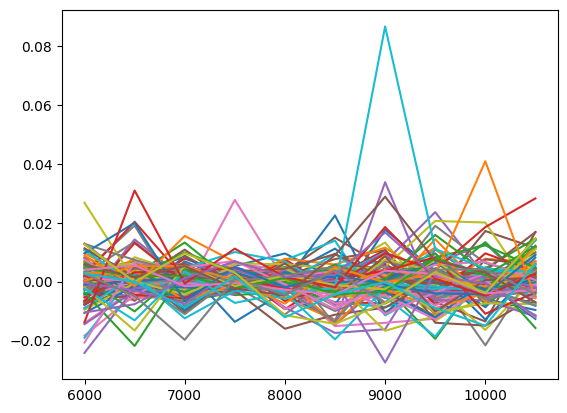

In [23]:
for i in range(100):
    plt.plot(times,res[:,70,i])

In [8]:
freq.reshape(99,100)[49]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

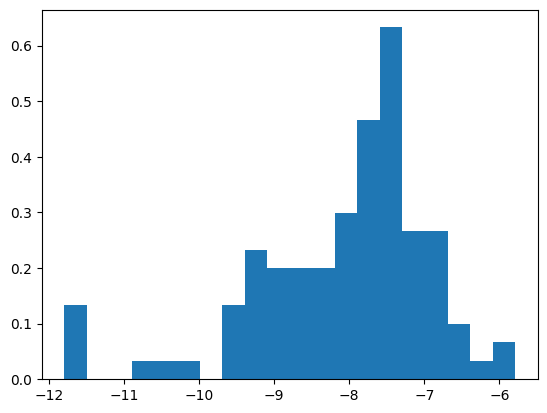

In [24]:
plt.hist(np.log(np.abs(res[-1,0,:])),density=True,bins=20);

In [25]:
from scipy.stats import kurtosis

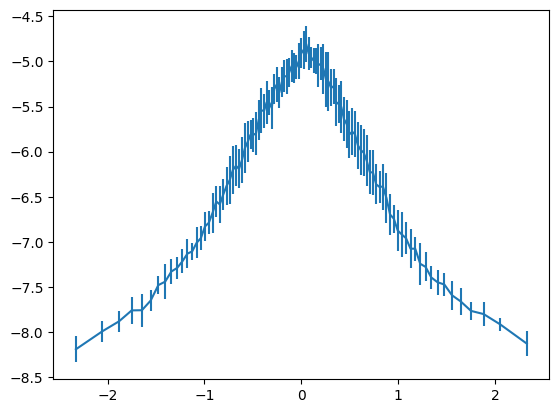

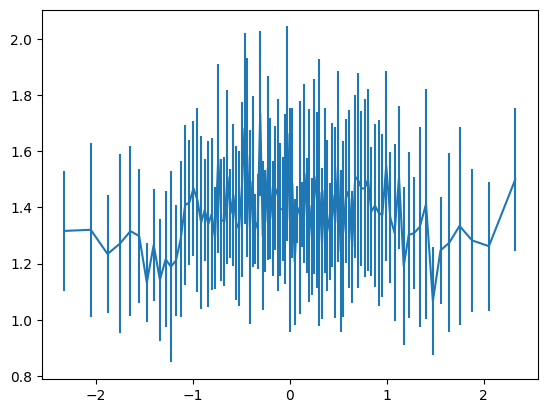

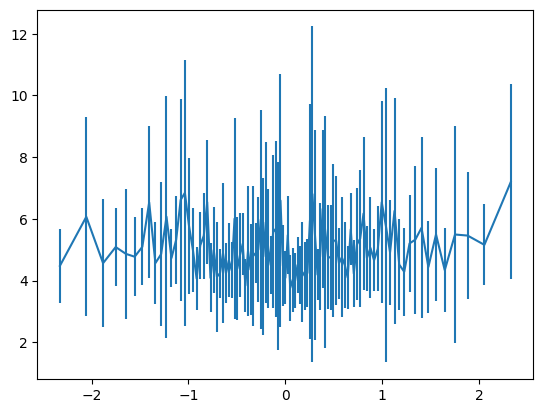

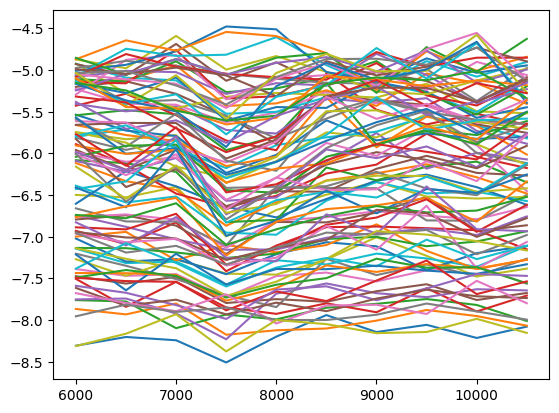

In [26]:
un_freq=np.unique(freq)

mu_list=np.empty((len(un_freq),len(times)))
var_list=np.empty((len(un_freq),len(times)))
k_list=np.empty((len(un_freq),len(times)))

for i in range(len(un_freq)):
    #print(np.unique(freq)[i])
    
    for j in range(len(times)):
        x=np.log(np.abs(res[j,i,:]))
        
        mu=np.mean(x)
        var=np.var(x)
        k=np.mean((x-mu)**4)/var**2
        
        mu_list[i,j]=mu
        var_list[i,j]=var
        k_list[i,j]=k
        
#        print(mu,var,k)
#        print("")

plt.errorbar(un_freq,np.mean(mu_list,axis=1),np.std(mu_list,axis=1))
plt.show()

plt.errorbar(un_freq,np.mean(var_list,axis=1),np.std(var_list,axis=1))
plt.show()

plt.errorbar(un_freq,np.mean(k_list,axis=1),np.std(k_list,axis=1))
plt.show()

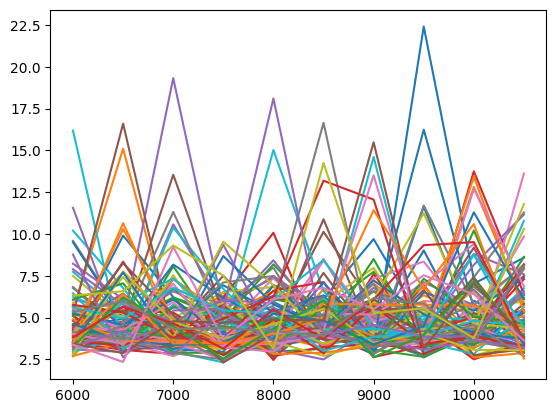

In [28]:
for i in range(99):
    plt.plot(times,k_list[i,:])
plt.show()

#### Cauchy distribution

[0.00859608 0.00790889 0.00798415 0.00968746 0.00922803 0.00986152
 0.00912489 0.00951541 0.00866828 0.01549337]
0.009606807747520495


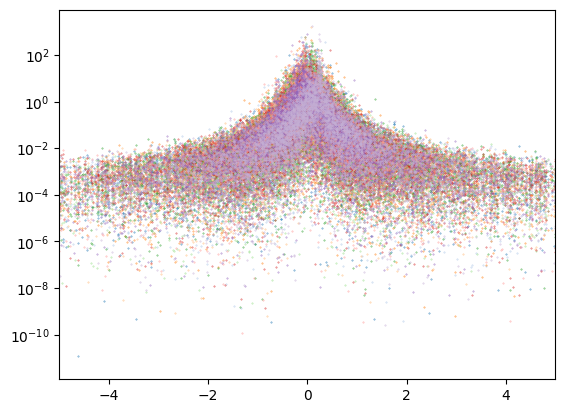

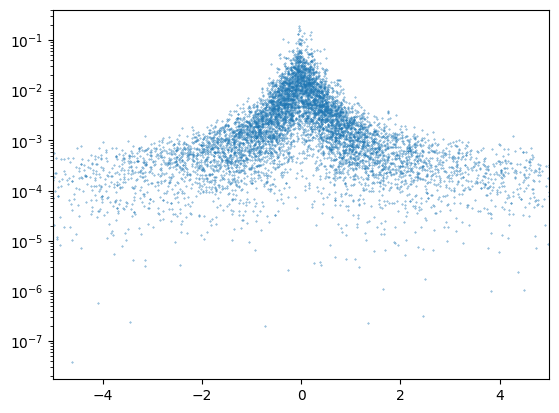

In [109]:
filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/data_cauchy/"

freq=np.fromfile(filebase+f"test_freq.dat",dtype=np.float64)
N=len(freq)
Tout=np.fromfile(filebase+f"test_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)


times=Tout[:,2*N]
lyap=Tout[:,-1]
dtheta=Tout[:,N:2*N]
dtheta0=np.mean(dtheta,axis=0)
idxFreq=np.argsort(freq)

print(lyap)
print(np.mean(lyap))

cmap = generate_colormap(len(times), palette_type="categorical")

for a in range(len(times)):
    plt.scatter(freq[idxFreq],N*np.abs(dtheta[a,idxFreq]**2),marker=".",color=cmap[a],s=0.5,alpha=0.8)
plt.yscale("log")
plt.xlim(-5,5)
plt.show()
plt.scatter(freq[idxFreq],np.abs(dtheta[0,idxFreq]),marker=".",s=0.5,alpha=0.8)
plt.xlim(-5,5)
plt.yscale("log")

#### Fixed $\omega$

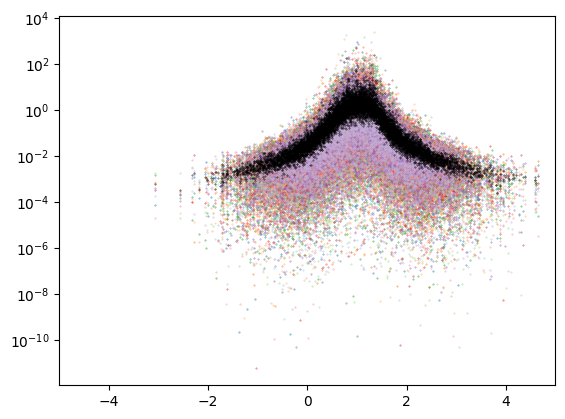

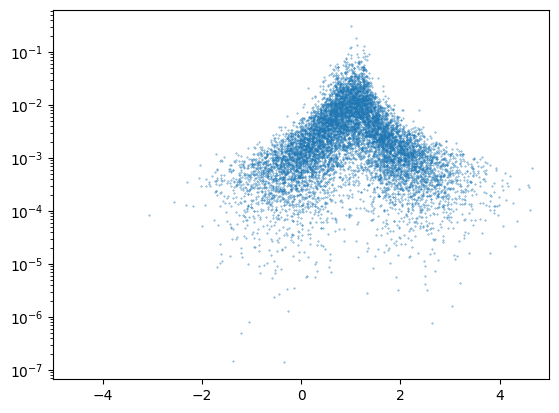

In [31]:
filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/data_wfixed/"

freq=np.fromfile(filebase+f"test_wmu1_freq.dat",dtype=np.float64)
N=len(freq)
Tout=np.fromfile(filebase+f"test_wmu1_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)


times=Tout[:,2*N]
lyap=Tout[:,-1]
dtheta=Tout[:,N:2*N]
dtheta0=np.mean(dtheta,axis=0)
idxFreq=np.argsort(freq)

cmap = generate_colormap(len(times), palette_type="categorical")

for a in range(len(times)):
    plt.scatter(freq[idxFreq],N*np.abs(dtheta[a,idxFreq]**2),marker=".",color=cmap[a],s=0.5,alpha=0.8)
plt.scatter(freq[idxFreq],N*np.mean(np.abs(dtheta[:,idxFreq]**2),axis=0),marker=".",color="k",s=0.5,alpha=0.8)
plt.yscale("log")
plt.xlim(-5,5)
plt.show()
plt.scatter(freq[idxFreq],np.abs(dtheta[0,idxFreq]),marker=".",s=0.5,alpha=0.8)
plt.xlim(-5,5)
plt.yscale("log")

res=dtheta.reshape(-1,99,100) ## Just a separation in dimensions for [time ,n_freq bins,n_osc per freq]

In [28]:
un_freq=np.unique(freq)

mu_list=np.empty((len(un_freq),len(times)))
var_list=np.empty((len(un_freq),len(times)))
k_list=np.empty((len(un_freq),len(times)))

for i in range(len(un_freq)):
    #print(np.unique(freq)[i])
    
    for j in range(len(times)):
        x=np.log(np.abs(res[j,i,:]))
        
        mu=np.mean(x)
        var=np.var(x)
        k=np.mean((x-mu)**4)/var**2
        
        mu_list[i,j]=mu
        var_list[i,j]=var
        k_list[i,j]=k
        
#        print(mu,var,k)
#        print("")

plt.errorbar(un_freq,np.mean(mu_list,axis=1),np.std(mu_list,axis=1))
plt.show()

plt.errorbar(un_freq,np.mean(var_list,axis=1),np.std(var_list,axis=1))
plt.show()

plt.errorbar(un_freq,np.mean(k_list,axis=1),np.std(k_list,axis=1))
plt.show()

IndexError: index 99 is out of bounds for axis 1 with size 99

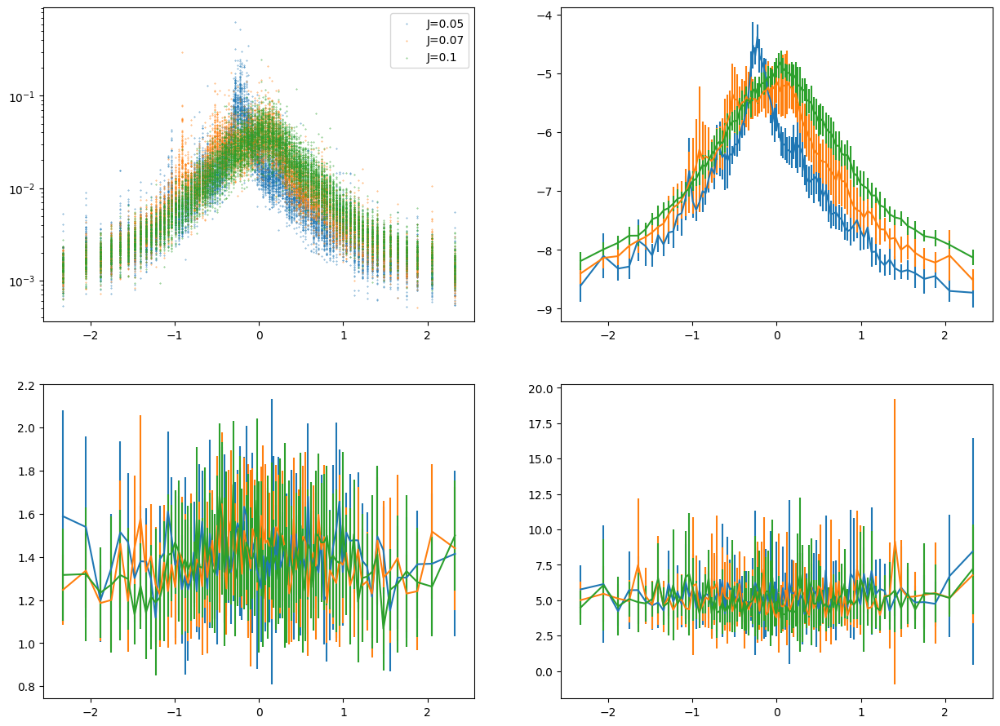

In [25]:
cmap = generate_colormap(len(J_list), palette_type="continuous")
fig,axs=plt.subplots(2,2,figsize=(15,11))

i=-1
for J in J_list:
    i+=1
#    print(f"J={J}")
    

    try:
        tlimit=0
        Tout=np.fromfile(filebase+f"J{J}_corrn1_Tout.dat",dtype=np.float64).reshape(-1,2*N+2)
        
        times=Tout[:,2*N]
        lyap=Tout[:,-1]
        theta=Tout[:,:N]
        dtheta=Tout[:,N:2*N]

        axs[0,0].scatter(freq[idxFreq],np.mean(np.abs(dtheta[:,idxFreq]),axis=0)/np.sqrt(float(J)),marker=".",s=0.5,alpha=0.8,label=f"J={J}")
        axs[0,0].set_yscale("log")
        
        res=dtheta.reshape(-1,99,100) ## Just a separation in dimensions for [time ,n_freq bins,n_osc per freq]

        un_freq=np.unique(freq)

        mu_list=np.empty((len(un_freq),len(times)))
        var_list=np.empty((len(un_freq),len(times)))
        k_list=np.empty((len(un_freq),len(times)))
        
        for i in range(len(un_freq)):
            #print(np.unique(freq)[i])
            
            for j in range(len(times)):
                x=np.log(np.abs(res[j,i,:]))
                
                mu=np.mean(x)
                var=np.var(x)
                k=np.mean((x-mu)**4)/var**2
                
                mu_list[i,j]=mu
                var_list[i,j]=var
                k_list[i,j]=k
                
        axs[0,1].errorbar(un_freq,np.mean(mu_list,axis=1),np.std(mu_list,axis=1))
#        plt.show()
        
        axs[1,0].errorbar(un_freq,np.mean(var_list,axis=1),np.std(var_list,axis=1))
#        plt.show()
        
        axs[1,1].errorbar(un_freq,np.mean(k_list,axis=1),np.std(k_list,axis=1))
#        plt.show()
        
#        axs[0,0].scatter(times,lyap,color=cmap[i],alpha=0.5,marker=".")
        #plt.hist(np.log(np.abs(dtheta[1,:])),bins=100)
#        axs[0,1].plot(times,np.var(np.log(np.abs(dtheta)),axis=1),color=cmap[i],marker="*")
#        axs[1,0].plot(times,kurtosis(np.log(np.abs(dtheta)),fisher=False,axis=1),color=cmap[i],marker=".")
#        axs[1,1].plot(times,skew(np.log(np.abs(dtheta)),axis=1),color=cmap[i],marker=".")
    except Exception as err:
        print(f"Unexpected {err=}, {type(err)=}")
        
axs[0,0].legend()
plt.show()

# Evaluating $[\lambda]_{\infty}$ and fitting

## General functions used throughout

### Fitting function

In [2]:
def fit_curvefit(datax, datay, fit_func, p0, yerr=0.0,mseout=False, **kwargs):
    
    from scipy.optimize import curve_fit
    
    pfit, pcov = curve_fit(fit_func,datax,datay,p0=p0, sigma=yerr, absolute_sigma=True, **kwargs)
    error = [] 
    for i in range(len(pfit)):
        try:
          error.append(np.absolute(pcov[i][i])**0.5)
        except:
          error.append( 0.00 )
            
    pfit_curvefit = pfit
    perr_curvefit = np.array(error)

    y_pred=fit_func(datax,*pfit)

    ## Metrics
    ss_res = np.sum((datay - y_pred)**2)
    ss_tot = np.sum((datay - np.mean(datay))**2)
    
    #R2
    r2 = 1 - ss_res / ss_tot

    from scipy import stats
    r2 = stats.pearsonr(datax, datay).statistic**2

    if mseout:
        N=len(datay)
        MSE=ss_res/N
        return pfit_curvefit, perr_curvefit, np.sqrt(MSE)
        
    return pfit_curvefit, perr_curvefit, r2

def fit_bootstrap(datax, datay, fit_func, p0, yerr=0.0,Nsamples=500,Nsigma=2,out_all=False):
    from scipy.optimize import leastsq

    def errfunc(p,x,y):
        return fit_func(x,p)-y
    
    # Fit first time
    pfit, perr = leastsq(errfunc, p0, args=(datax, datay))

    # Get the stdev of the residuals
    residuals = errfunc(pfit, datax, datay)
    sigma_res = np.std(residuals)

    sigma_err_total = np.sqrt(sigma_res**2 + yerr**2)
    
    ps = []
    
    for i in range(Nsamples):

        randomDelta = np.random.normal(0., sigma_err_total, len(datay))
        randomdataY = datay + randomDelta   
        
        randomfit, randomcov = leastsq(errfunc, p0, args=(datax, randomdataY))
        ps.append(randomfit) 

    ps = np.array(ps)
    mean_pfit = np.mean(ps,0)
    err_pfit = Nsigma * np.std(ps,0) 

    y_pred=fit_func(datax,mean_pfit)
    ss_res = np.sum((datay - y_pred)**2)
    ss_tot = np.sum((datay - np.mean(datay))**2)
    r2_mean=1 - ss_res / ss_tot
    
    pfit_bootstrap = mean_pfit
    perr_bootstrap = err_pfit

    if out_all:
        return pfit_bootstrap, perr_bootstrap, r2_mean, ps
    
    return pfit_bootstrap, perr_bootstrap, r2_mean

In [3]:
def fit_bootstrap_resample(datax, datay, fit_func, p0,Nsamples=500,Nsigma=2,out_all=False):
    
    from sklearn.utils import resample
    from scipy.optimize import leastsq

    def errfunc(p,x,y):
        return fit_func(x,p)-y
    
    ps = []
#    print(datay)    
    for i in range(Nsamples):

        randomdataY = np.mean(resample(datay.T, replace=True, random_state=i),axis=0)
#        print(f"Sample {i}:{randomdataY}")
        randomfit, randomcov = leastsq(errfunc, p0, args=(datax, randomdataY))
        ps.append(randomfit) 

    ps = np.array(ps)
    mean_pfit = np.mean(ps,0)
    err_pfit = Nsigma * np.std(ps,0) 

    y_pred=fit_func(datax,mean_pfit)
    datay=np.mean(datay,axis=1)
    
    ss_res = np.sum((datay - y_pred)**2)
    ss_tot = np.sum((datay - np.mean(datay))**2)
    r2_mean=1 - ss_res / ss_tot
    
    pfit_bootstrap = mean_pfit
    perr_bootstrap = err_pfit

    if out_all:
        return pfit_bootstrap, perr_bootstrap, r2_mean, ps
    
    return pfit_bootstrap, perr_bootstrap, r2_mean

### Evaluate R2 coefficient 

In [4]:
def r2_method(df,linf_lo,linf_up,has_yerr=True,bootstrap=False,btol=1e-4,n_gridsearch=10):
    if "J" in df:
        raise Exception("This method is specific for a fixed J. Use df.drop(\"J\") when passing the argument")
    
    N_list=df["N"].unique()
    eta_list=df["eta"].unique()
    store_r2=np.empty((len(eta_list),n_gridsearch))
    store_linf=[]
    
    x_obs=np.log(N_list)
    
    def lin_fit(x,*p):
        return p[0]*x+p[1]
        
    def get_r2(mle_data,linf_est,mseout=False):
        
        if any(linf_est<=mle_data[:,0]):
            return 0
            
        y_obs=np.log(linf_est-mle_data[:,0])
        
        if has_yerr:
            y_obs_err=np.abs(mle_data[:,1]/(linf_est-mle_data[:,0]))
        else:
            y_obs_err=None

        if bootstrap:
            _, _, r2 = fit_bootstrap_resample(x_obs, y_obs, lin_fit, np.array([-1,-1]))
        else:
            _, _, r2 = fit_curvefit(x_obs, y_obs, lin_fit, np.array([-1,-1]),y_obs_err)
            
        return r2

    def get_arraybounds(mle_arr,linf_bounds,r2_bounds):
        maxr2_idx=np.argmax(r2_bounds)
        newlinf=np.empty(5)
        newr2=np.empty(5)
        
        if maxr2_idx==0:
            
            newlinf=np.linspace(linf_bounds[0],linf_bounds[1],num=5)

            newr2[[0,-1]]=r2_bounds[[0,1]]
            newr2[1:-1]=[get_r2(mle_arr,l) for l in newlinf[1:-1]]
            
        elif maxr2_idx==len(r2_bounds)-1:
            
            newlinf=np.linspace(linf_bounds[-2],linf_bounds[-1],num=5)

            newr2[[0,-1]]=r2_bounds[[-2,-1]]
            newr2[1:-1]=[get_r2(mle_arr,l) for l in newlinf[1:-1]]
            
        else:
            p3bounds=linf_bounds[[maxr2_idx-1,maxr2_idx,maxr2_idx+1]]
            newlinf[[0,2,4]]=p3bounds
            newlinf[[1,3]]=(p3bounds[1:]+p3bounds[:-1])*0.5

            newr2[[0,2,4]]=r2_bounds[[maxr2_idx-1,maxr2_idx,maxr2_idx+1]]
            newr2[[1,3]]=[get_r2(mle_arr,newlinf[1]),get_r2(mle_arr,newlinf[3])]
            
        return newlinf, newr2
        
    for ei in range(len(eta_list)):
        mle_arr=df[df["eta"]==eta_list[ei]][["lambda","err_lambda"]].to_numpy()

        ### The algorithm
        #Get r2 for the bounds
        linf_bounds=np.linspace(linf_lo,linf_up,num=5)
        r2_bounds=np.array([get_r2(mle_arr,l) for l in linf_bounds])
        
        while np.amax(r2_bounds)-np.amin(r2_bounds)>btol:

            linf_bounds,r2_bounds=get_arraybounds(mle_arr,linf_bounds,r2_bounds)
        
        # Follow with 10 grid search
        linf=np.linspace(linf_bounds[0],linf_bounds[-1],num=n_gridsearch)
        
        for li in range(len(linf)):
            store_r2[ei,li]=get_r2(mle_arr,linf[li])
        store_linf.append(linf)
    return np.array(store_linf), store_r2

In [5]:
def mse_method(df,linf_lo,linf_up,has_yerr=True,btol=1e-4,n_gridsearch=10):
    if "J" in df:
        raise Exception("This method is specific for a fixed J. Use df.drop(\"J\") when passing the argument")
    
    N_list=df["N"].unique()
    eta_list=df["eta"].unique()
    store_mse=np.empty((len(eta_list),n_gridsearch))
    store_linf=[]
    
    x_obs=np.log(N_list)
    
    def lin_fit(x,*p):
        return p[0]*x+p[1]
        
    def get_mse(mle_data,linf_est):
        
        if any(linf_est<mle_data[:,0]):
            return 1e6
            
        y_obs=np.log(linf_est-mle_data[:,0])
        
        if has_yerr:
            y_obs_err=np.abs(mle_data[:,1]/(linf_est-mle_data[:,0]))
        else:
            y_obs_err=None

        _, _, mse = fit_curvefit(x_obs, y_obs, lin_fit, np.array([-1,-1]), y_obs_err,mseout=True)
        return mse

#    def get_arraybounds(mle_arr,linf_bounds,mse_bounds):
#        minmse_idx=np.argmin(mse_bounds)
#        newlinf=np.empty(5)
#        newmse=np.empty(5)
#        
#        if minmse_idx==0:
#            
#            newlinf=np.linspace(linf_bounds[0],linf_bounds[1],num=5)
#
#            newmse[[0,-1]]=mse_bounds[[0,1]]
#            newmse[1:-1]=[get_mse(mle_arr,l) for l in newlinf[1:-1]]
#            
#        elif minmse_idx==len(mse_bounds)-1:
#            
#            newlinf=np.linspace(linf_bounds[-2],linf_bounds[-1],num=5)
#
#            newmse[[0,-1]]=mse_bounds[[-2,-1]]
#            newmse[1:-1]=[get_mse(mle_arr,l) for l in newlinf[1:-1]]
#            
#        else:
#            p3bounds=linf_bounds[[minmse_idx-1,minmse_idx,minmse_idx+1]]
#            newlinf[[0,2,4]]=p3bounds
#            newlinf[[1,3]]=(p3bounds[1:]+p3bounds[:-1])*0.5
#
#            newmse[[0,2,4]]=mse_bounds[[minmse_idx-1,minmse_idx,minmse_idx+1]]
#            newmse[[1,3]]=[get_mse(mle_arr,newlinf[1]),get_mse(mle_arr,newlinf[3])]
#            
#        return newlinf, newmse
        
    for ei in range(len(eta_list)):
        mle_arr=df[df["eta"]==eta_list[ei]][["lambda","err_lambda"]].to_numpy()

        ### The algorithm
        #Get mse for the bounds
        linf_bounds=np.linspace(linf_lo,linf_up,num=5)
#        mse_bounds=np.array([get_mse(mle_arr,l) for l in linf_bounds])
        
#        while np.amax(mse_bounds)-np.amin(mse_bounds)>btol:

#            linf_bounds,mse_bounds=get_arraybounds(mle_arr,linf_bounds,mse_bounds)
        
        # Follow with 10 grid search
        linf=np.linspace(linf_bounds[0],linf_bounds[-1],num=n_gridsearch)
        
        for li in range(len(linf)):
            store_mse[ei,li]=get_mse(mle_arr,linf[li])
        store_linf.append(linf)
    return np.array(store_linf), store_mse

### Evaluate coefficients with optimal $[\lambda]_{\infty}$

In [6]:
def coefloop(df,linf_opt,has_yerr=True,linf_err=[],gen_fig=False,ax=None):
    
    if "J" in df:
        raise Exception("This method is specific for a fixed J. Use df.drop(\"J\") when passing the argument")
    
    N_list=df["N"].unique()
    eta_list=df["eta"].unique()
    temp=np.empty((len(eta_list),2,2))

    x_obs=np.log(N_list)
    
    def lin_fit(x,*p):
        return p[0]*x+p[1]
    
    for ei in range(len(eta_list)):
        
        mle_arr=df[df["eta"]==eta_list[ei]][["lambda","err_lambda"]].to_numpy()
        
        y_obs=np.log(linf_opt[ei]-mle_arr[:,0])

        if not has_yerr:
            y_obs_err=None
        else:
            if not list(linf_err):
                y_obs_err=np.abs(mle_arr[:,1])
            else:
                y_obs_err=np.sqrt(linf_err[ei]**2+mle_arr[:,1]**2)
    
            y_obs_err/=np.abs(linf_opt[ei]-mle_arr[:,0])

        pfit, perr, _ = fit_curvefit(x_obs, y_obs, lin_fit, np.array([-1,-1]), y_obs_err)
    
        temp[ei,:,0]=pfit
        temp[ei,:,1]=perr

        if (gen_fig):
#            print(f"alpha = {pfit[0]} +- {perr[0]}\n")
#            print(f"log kappa = {pfit[1]} +- {perr[1]}\n")
            ax=ax.flatten()
            ax[ei].errorbar(x_obs,y_obs,yerr=y_obs_err,marker="*",color="k",zorder=-100,alpha=0.2)
            ax[ei].plot(x_obs,pfit[1]+pfit[0]*x_obs,"-",alpha=0.5)
            ax[ei].set_title(f"$\\eta={eta_list[ei]}$")
        
    return temp[:,0,:],temp[:,1,:]

### Load raw data and prepare means for analysis

In [7]:
def create_data_pd(Jlist, Nlist, filebase,prev=None):
    """
    This function is kind of a mess but I couldn't think of another way to do it

    Makes an list of lists which contains [J,[N,seeds,numpyArrayLoad]]
    """
    out=[prev]
    for J in Jlist:
        for N in Nlist:
            try:
                A=pd.read_csv(filebase+f"data_MLE_J{J}/N{N:d}_finite_MLE.dat",sep=" ",header=None,names=["seed","eta","lambda","err_lambda"])
                A["N"]=N
                A["J"]=float(J)
                out.append(A)
            except:
                print(f"Couldn't load N={N:d} for J={J}") 
                continue
    return pd.concat(out)

In [8]:
def mean_pd_func(data_pd):

    df_group=data_pd[["J","eta","N","lambda"]].groupby(["J","eta","N"],as_index=False)
    
    mean_pd=df_group.mean()
    mean_pd["err_lambda"]=df_group.std()["lambda"]/df_group.count()["lambda"].apply(np.sqrt)
    
    return mean_pd

### Subset functions that need a change

In [9]:
def yet_another_loop(df,bounds,J,M=100):
    temp_linf=np.empty((df["eta"].nunique(),M))
    
    rand_df=df[df["J"]==J].drop("J",axis=1)
    
    for m in range(M):    
        rand_df["lambda"]=np.random.normal(rand_df["lambda"],rand_df["err_lambda"])
        linf,r2_store=r2_method(rand_df,bounds[0],bounds[1],has_yerr=False)

        temp_linf[:,m]=np.array([linf[li,np.nanargmax(r2_store,axis=1)[li]] for li in range(len(linf))])

    mean_linf=np.mean(temp_linf,axis=1)
    std_linf=np.std(temp_linf,axis=1)/np.sqrt(M)

    return mean_linf, std_linf

In [10]:
def subsets_df(data_df,Nsubsets=2):
    
    Allmean_list=[]
    
    for n in range(Nsubsets):
        mean_pd=mean_pd_func(data_df.groupby(["J","eta","N"],as_index=False).apply(lambda x: x[n*(len(x)//Nsubsets):(n+1)*(len(x)//Nsubsets)]))
        mean_pd["label_subset"]=n
        Allmean_list.append(mean_pd)

    return pd.concat(Allmean_list)

def maskfilter(df,mask):
    N_list=df["N"].unique()
    filt=False
    for i in range(len(N_list)):
        filt+=((df["N"]==N_list[i]) & (df["label_subset"]==mask[i]))
    return filt

def yet_another_loop_subsets(data_subset_df,bounds):
    Nnum=data_subset_df["N"].nunique()
    Nsets=data_subset_df["label_subset"].nunique()
    
    temp_linf=np.empty((data_subset_df["eta"].nunique(),Nsets**Nnum))
    mask=np.zeros(Nnum,dtype=int)
    
    for m in range(Nsets**Nnum):
        rand_df=data_subset_df[maskfilter(data_subset_df,mask)]
        rand_df.loc[:,"lambda"]=np.random.normal(rand_df["lambda"],rand_df["err_lambda"])
        linf,r2_store=r2_method(rand_df,bounds[0],bounds[1],has_yerr=True)

        for pos in range(Nnum):
            tempval=Nsets**pos
            mask[pos]=((m+1)//tempval)%(Nsets)

        temp_linf[:,m]=np.array([linf[li,np.nanargmax(r2_store,axis=1)[li]] for li in range(len(linf))])

    mean_linf=np.mean(temp_linf,axis=1)
    std_linf=np.std(temp_linf,axis=1)
    std_linf_dof=std_linf/np.sqrt(Nsets*(Nnum-1))
    return temp_linf, mean_linf, std_linf/np.sqrt(Nsets**Nnum),std_linf_dof

## Load data

In [11]:
filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/"
J_list=["0.14","0.2","0.28","0.4"]
N_list=[200,400,800,1600,3200,6400]
eta_list = [-1,-0.75,-0.5,-0.25,0,0.25,0.5,0.75,1]
dataJ=create_data_pd(J_list,N_list,filebase)

filebase=os.path.expanduser('~')+"/Desktop/KuramotoData/ttrans5000/"
J_list=["0.1","0.07"]
dataJ=create_data_pd(J_list,N_list,filebase,prev=dataJ)

J_list=["0.05"]
N_list=[200,400,800,1600,3200,6400]
dataJ=create_data_pd(J_list,N_list,filebase,prev=dataJ)
mean_pd=mean_pd_func(dataJ)

In [33]:
dataJ[dataJ["J"]==0.4].groupby(["J","eta","N"],as_index=False).count()

,J,eta,N,seed,lambda,err_lambda
0,4.00000e-01,-1.00000e+00,200,500,500,500
1,4.00000e-01,-1.00000e+00,400,500,500,500
2,4.00000e-01,-1.00000e+00,800,500,500,500
3,4.00000e-01,-1.00000e+00,1600,500,500,500
4,4.00000e-01,-1.00000e+00,3200,500,500,500
5,4.00000e-01,-1.00000e+00,6400,100,100,100
6,4.00000e-01,-7.50000e-01,200,500,500,500
7,4.00000e-01,-7.50000e-01,400,500,500,500
8,4.00000e-01,-7.50000e-01,800,500,500,500
9,4.00000e-01,-7.50000e-01,1600,500,500,500


## $[\lambda(N)]$ means vs asymmetry $\eta$

Note that $[\dots]$ is the average across multiple simulations of the system.

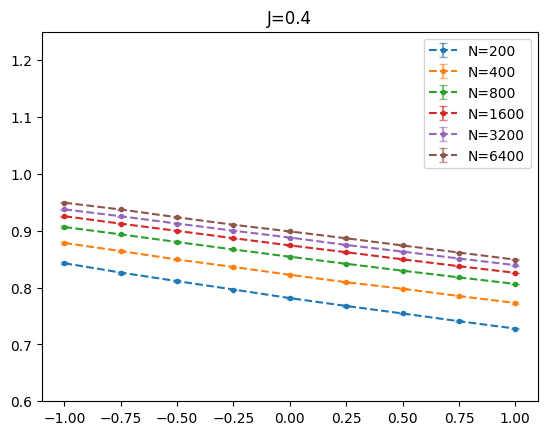

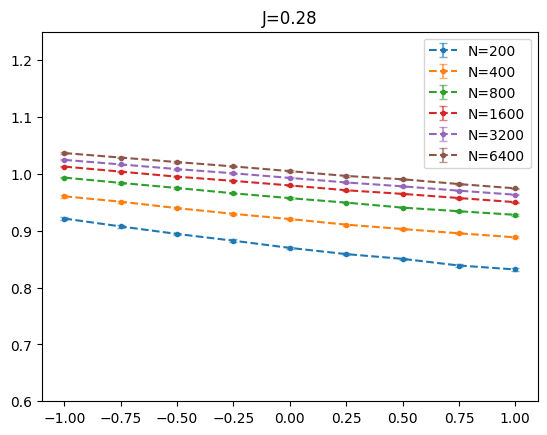

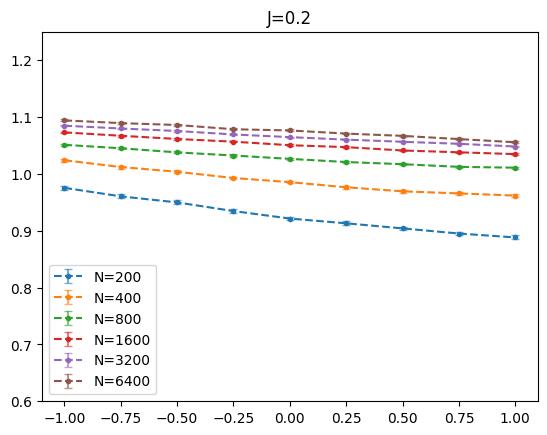

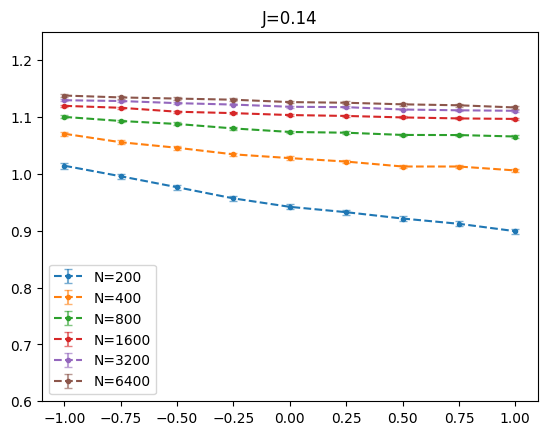

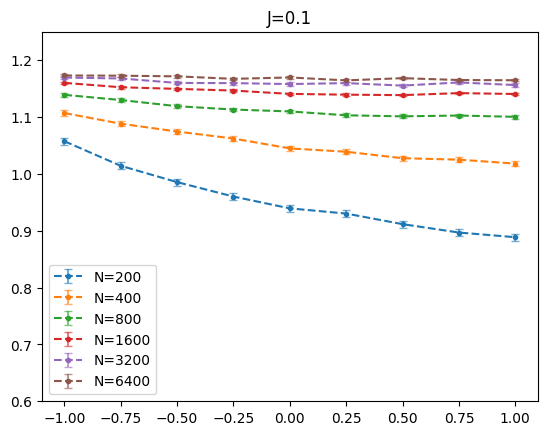

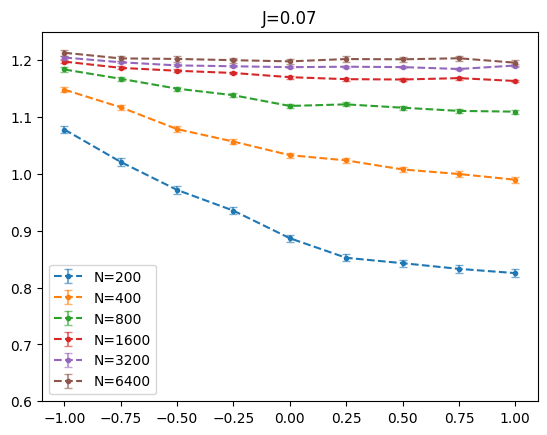

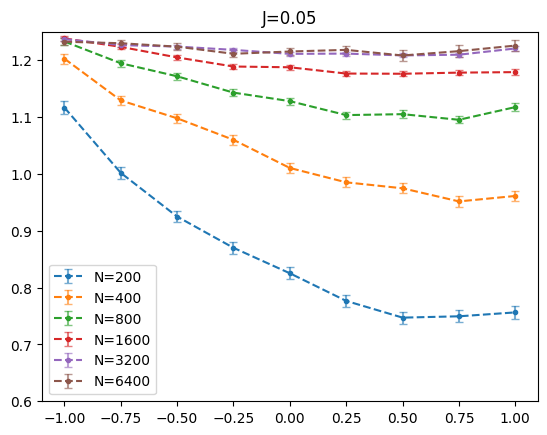

In [24]:
for J in mean_pd["J"].unique()[::-1]:
    tempdf_J=mean_pd[mean_pd["J"]==J]
    for N in tempdf_J["N"].unique():
        tempN=tempdf_J[tempdf_J["N"]==N]
        markers,caps,bars=plt.errorbar(tempN["eta"],tempN["lambda"]/J**2,yerr=tempN["err_lambda"]/J**2,capsize=3,fmt=".--",label=f"N={N:d}")
        [bar.set_alpha(0.6) for bar in bars]
        [cap.set_alpha(0.6) for cap in caps]
    plt.title(f"J={J}")
    plt.legend()
    plt.ylim(0.6,1.25)
    plt.show()

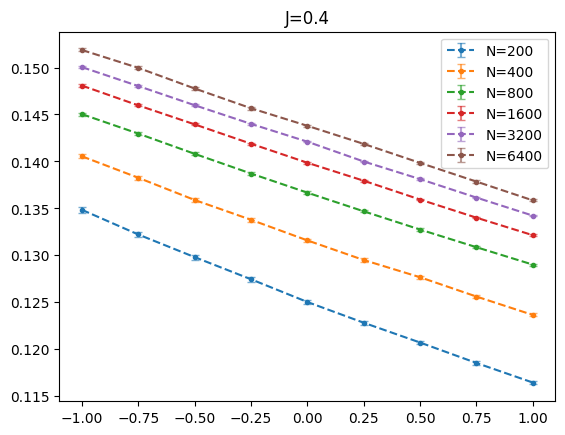

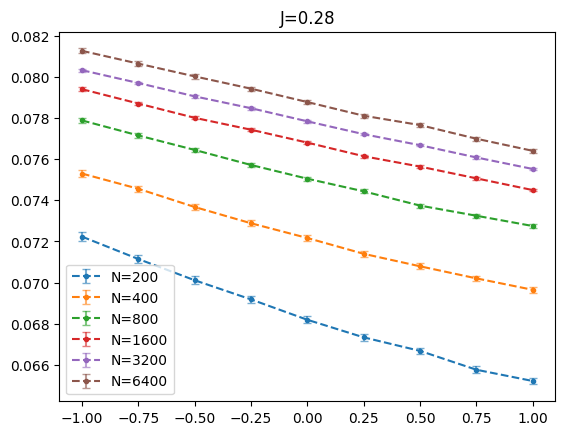

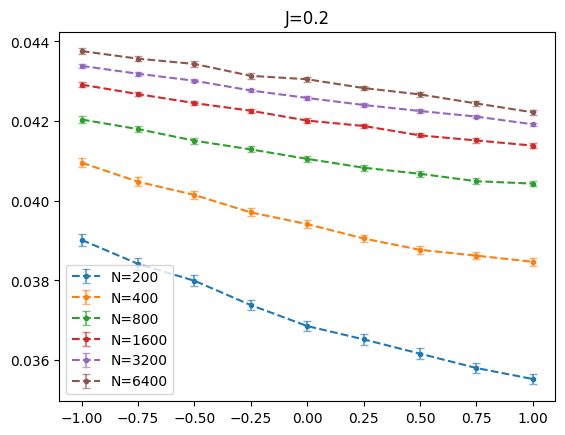

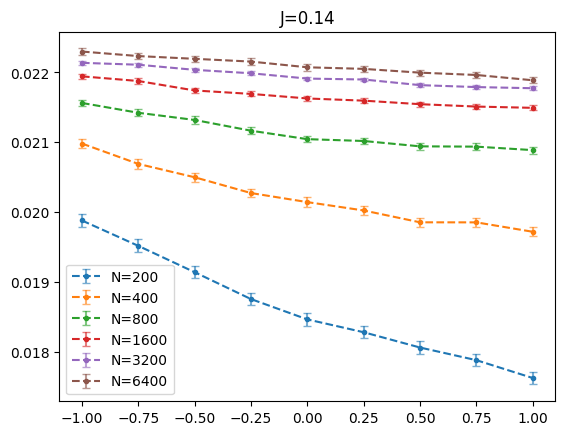

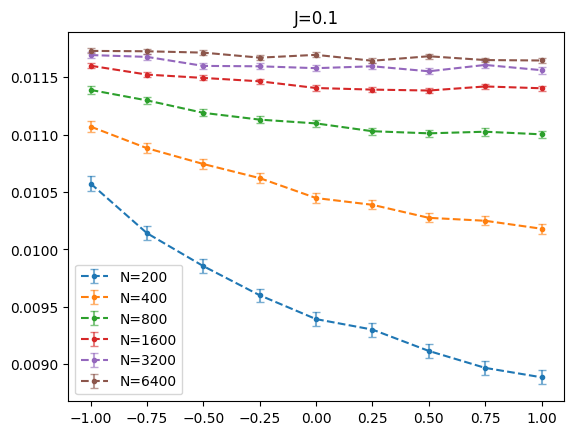

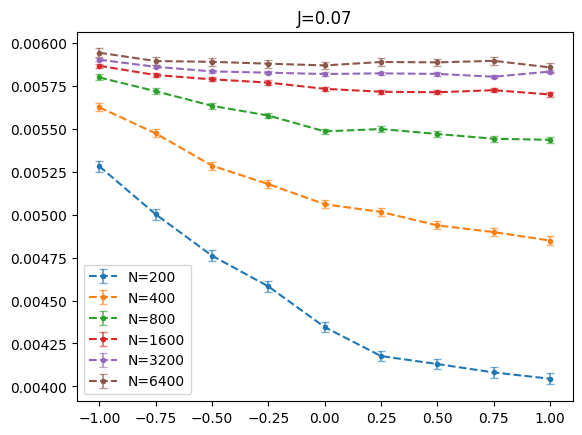

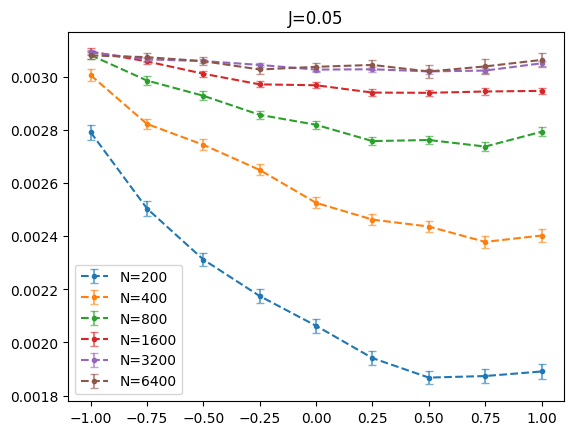

In [17]:
for J in mean_pd["J"].unique()[::-1]:
    tempdf_J=mean_pd[mean_pd["J"]==J]
    for N in tempdf_J["N"].unique():
        tempN=tempdf_J[tempdf_J["N"]==N]
        markers,caps,bars=plt.errorbar(tempN["eta"],tempN["lambda"],yerr=tempN["err_lambda"],capsize=3,fmt=".--",label=f"N={N:d}")
        [bar.set_alpha(0.6) for bar in bars]
        [cap.set_alpha(0.6) for cap in caps]
    plt.title(f"J={J}")
    plt.legend()
    plt.show()

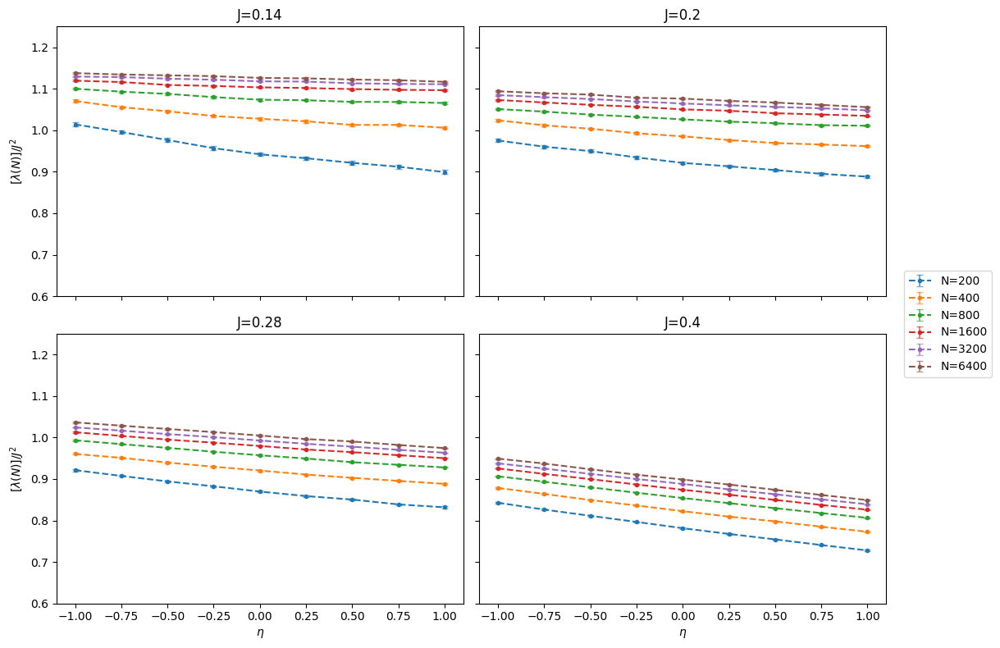

In [16]:
Jlist=[0.14,0.2,0.28,0.4]

fig, axs=plt.subplots(2,2,figsize=(11,8),sharex=True,sharey=True)
axs=axs.flatten()

for Ji in range(len(Jlist)):
    J=Jlist[Ji]
    tempdf_J=mean_pd[mean_pd["J"]==J]
    for N in tempdf_J["N"].unique():
        tempN=tempdf_J[tempdf_J["N"]==N]
        markers,caps,bars=axs[Ji].errorbar(tempN["eta"],tempN["lambda"]/J**2,yerr=tempN["err_lambda"]/J**2,capsize=3,fmt=".--",label=f"N={N:d}")
        [bar.set_alpha(0.6) for bar in bars]
        [cap.set_alpha(0.6) for cap in caps]
    axs[Ji].set_title(f"J={J}")
    axs[Ji].set_ylim(0.6,1.25)

#axs[0].set_ylabel("$\\frac{[\lambda(N)]}{J^2}$",rotation=0)
axs[0].set_ylabel("$[\lambda(N)]/J^2$")
axs[2].set_ylabel("$[\lambda(N)]/J^2$")
axs[2].set_xlabel("$\eta$")
axs[3].set_xlabel("$\eta$")

fig.legend([f"N={N:d}" for N in tempdf_J["N"].unique()],loc="center left", bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.show()

## Estimation of $\lambda_{\infty}$

From the data we can observe that, as we increase N, the diviation from $[\lambda(N)]$ gets smaller. Therefore, it's of interest to analyze estimate the value of the largest Lyapunov exponent in the thermodynamic limit ($N\to\infty$). To do this, we consider that the deviation from the thermodynamic-limit Lyapunov exponent decays as 
$$
\lambda_{\infty}-[\lambda(N)]\sim\frac{k}{N^{\alpha}}
$$
Now, we can do a linear regression, with $\lambda_{\infty}$ as a hyperparameter.
$$
\log(\lambda_{\infty}-[\lambda(N)])=\log k - \alpha \log N
$$

In [12]:
J_list=[0.05,0.07,0.1,0.14,0.2,0.28,0.4]
bounds=[[0.002,0.004],[0.005,0.007],[0.0113,0.012],[0.017,0.025],[0.035,0.05],[0.077,0.084],[0.1375,0.158]]

out=[]
for Ji in range(len(J_list)):
    print(J_list[Ji])
    
    linf,r2_store=r2_method(mean_pd[mean_pd["J"]==J_list[Ji]].drop("J",axis=1),bounds[Ji][0],bounds[Ji][1],bootstrap=False,btol=1e-3,n_gridsearch=200)
    print(np.min(linf),np.max(linf))
    eta_list=mean_pd["eta"].unique()
    linf_list=np.array([linf[li,np.nanargmax(r2_store,axis=1)[li]] for li in range(len(linf))])
    linf_df_mean=pd.DataFrame({"eta":eta_list,"linf_opt":linf_list})
    linf_df_mean["J"]=J_list[Ji]
    out.append(linf_df_mean)
    
linf_df_mean=pd.concat(out)
linf_df_mean

0.05
0.00305078125 0.00313671875
0.07
0.005890625 0.005984375
0.1
0.011704687500000002 0.011846875
0.14
0.022125 0.0226875
0.2
0.04255859375 0.044609375
0.28
0.07765625 0.08334375000000001
0.4
0.13846093750000002 0.15671875000000002


,eta,linf_opt,J
0,-1.00000e+00,3.13468e-03,5.00000e-02
1,-7.50000e-01,3.07747e-03,5.00000e-02
2,-5.00000e-01,3.08009e-03,5.00000e-02
3,-2.50000e-01,3.10784e-03,5.00000e-02
4,0.00000e+00,3.05471e-03,5.00000e-02
...,...,...,...
4,0.00000e+00,1.47528e-01,4.00000e-01
5,2.50000e-01,1.45677e-01,4.00000e-01
6,5.00000e-01,1.43398e-01,4.00000e-01
7,7.50000e-01,1.41180e-01,4.00000e-01


### $R^2$ and Coefficients

How do we estimate the value of $\lambda_{\infty}$ as a hyperparameter? We will take the best linear regression according to the $R^2$ metric.

Here we will do a small trick, since $R^2$ is a concave function with respect to the hyperparameter (obvserved through tests), we reduce the range as much as possible until the $R^2$ is under a tolerance where we sweep through the hyperparameter.

Then we take the $\lambda_{\infty}$ which gives the maximum $R^2$ and compute the parameters $\alpha$ and $\log k$ with that value.

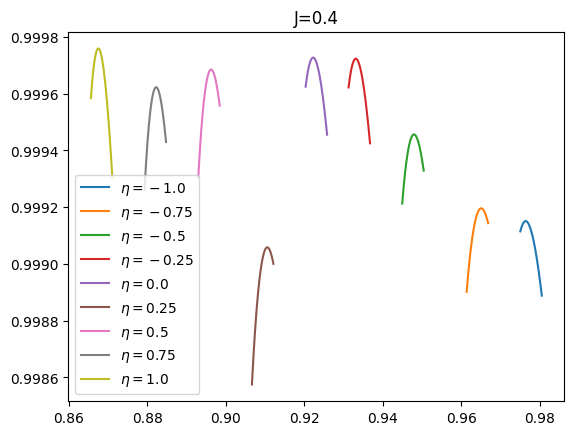

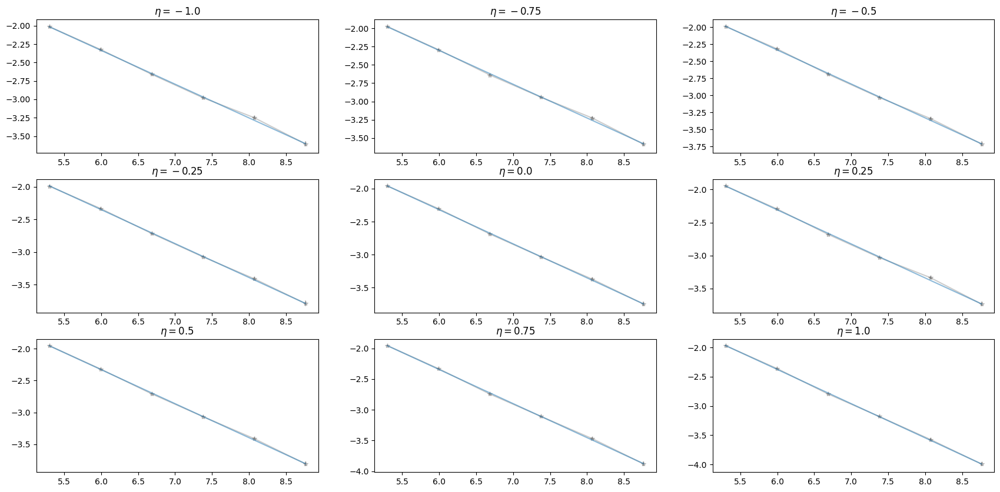

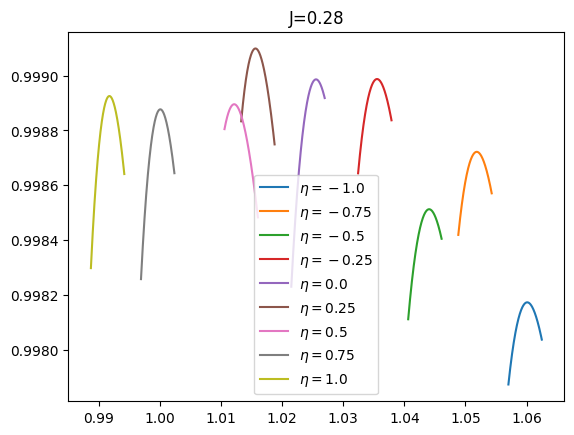

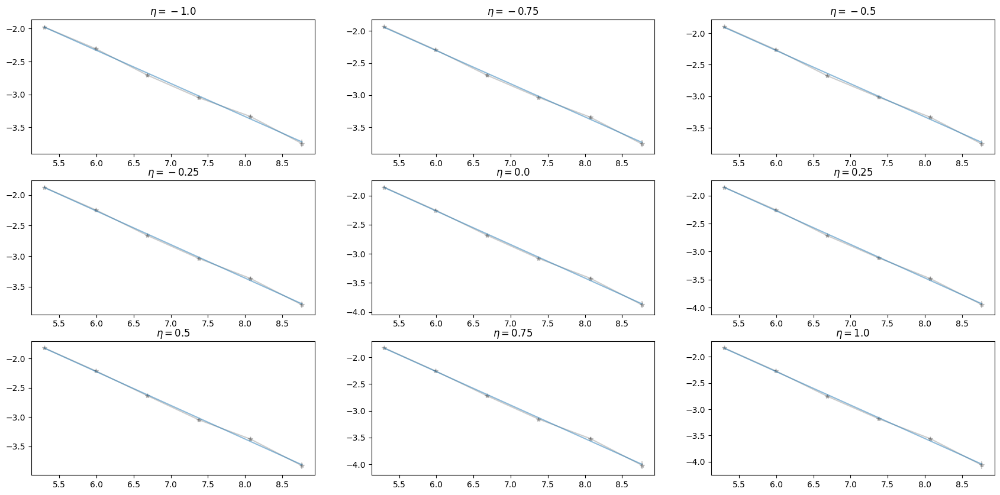

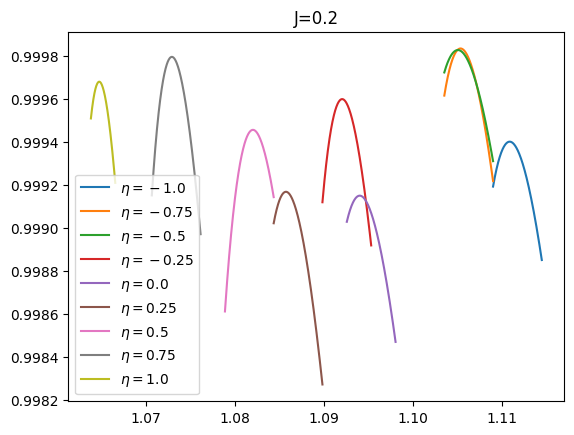

...

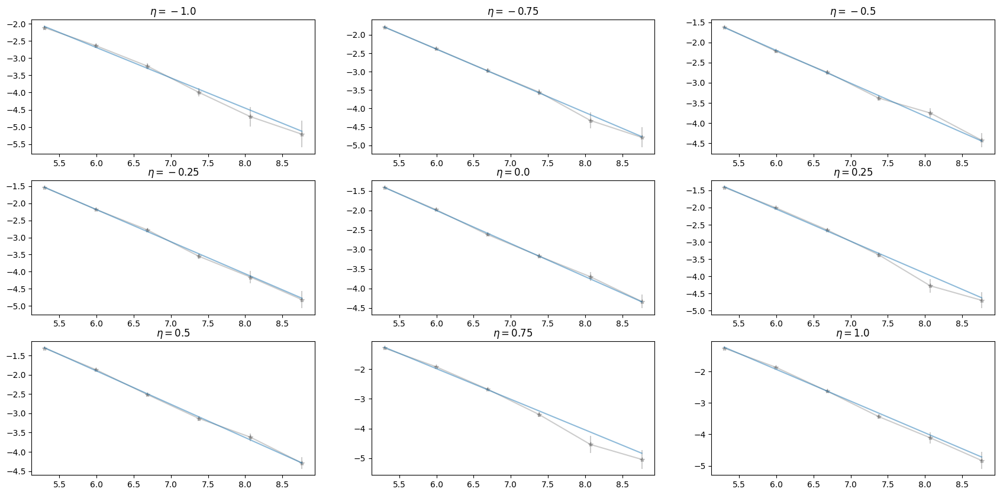

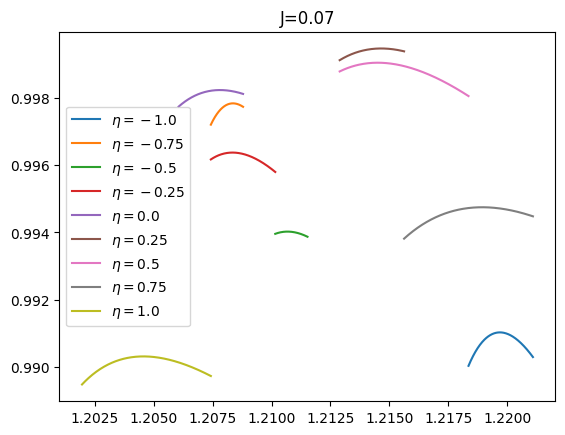

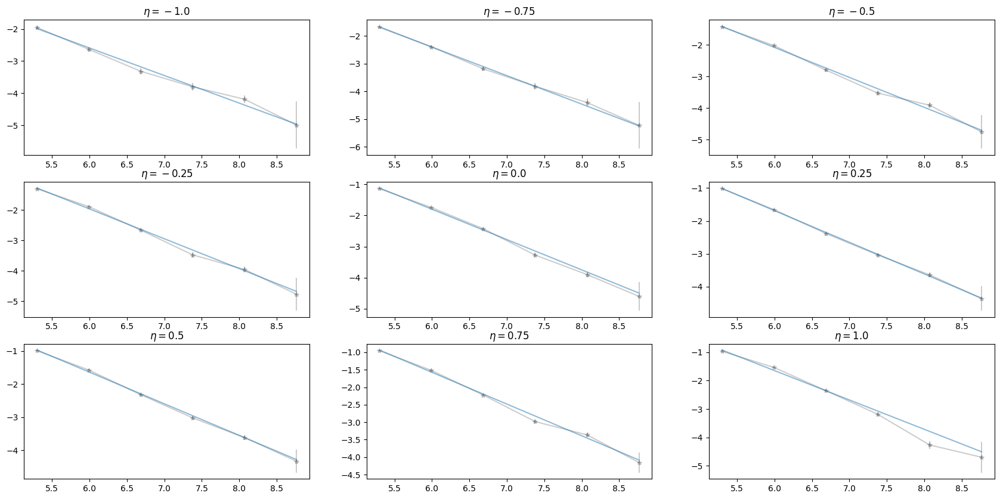

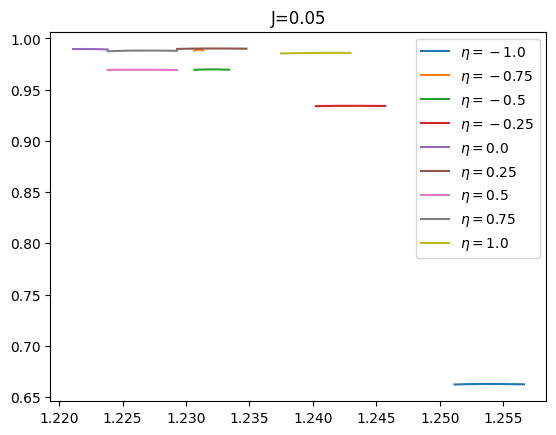

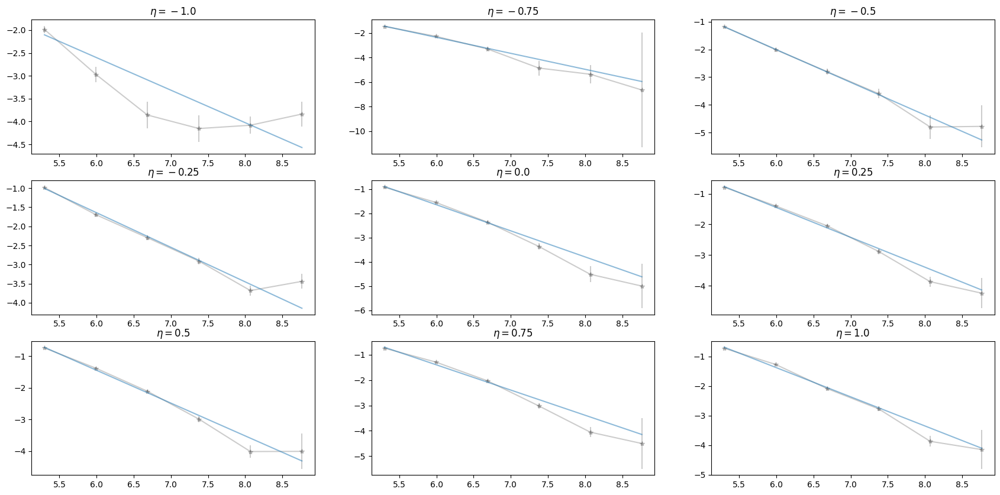

In [30]:
J_list=[0.05,0.07,0.1,0.14,0.2,0.28,0.4]
bounds=[0.8,1.5]

alpha=np.empty((len(J_list),9,2))
logk=np.empty((len(J_list),9,2))
linf_opt=np.empty((len(J_list),9))

for Ji in range(len(J_list))[::-1]:
#    try:
    tempdf_J=mean_pd[mean_pd["J"]==J_list[Ji]].drop("J",axis=1)
    tempdf_J[["lambda","err_lambda"]]=tempdf_J[["lambda","err_lambda"]].apply(lambda x: x/(J_list[Ji]**2))
    linf,r2_store=r2_method(tempdf_J,bounds[0],bounds[1],bootstrap=False,btol=1e-3,n_gridsearch=200)

    for ei in range(mean_pd["eta"].nunique()):
        plt.plot(linf[ei,:],r2_store[ei,:],label=f"$\\eta={eta_list[ei]}$")
    
    plt.legend()
    plt.title(f"J={J_list[Ji]}")
    #plt.xlim(0.0117,0.0119)
    plt.show()
    
    fig,axs=plt.subplots(3, 3,figsize=(21,10))
    linf_opt[Ji,:]=np.array([linf[li,np.nanargmax(r2_store,axis=1)[li]] for li in range(len(linf))])
    alpha[Ji,:,:], logk[Ji,:,:] = coefloop(tempdf_J,linf_opt[Ji,:],gen_fig=True,ax=axs)
    plt.show()


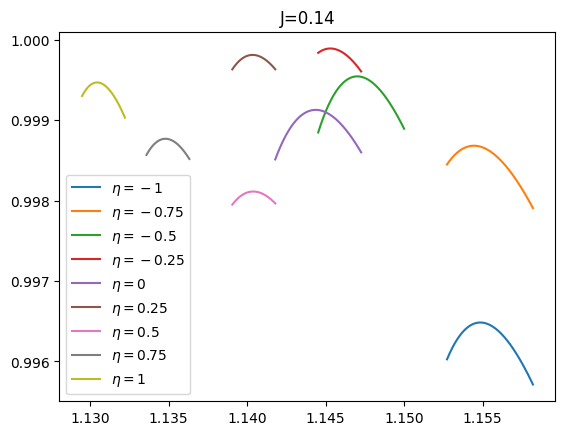

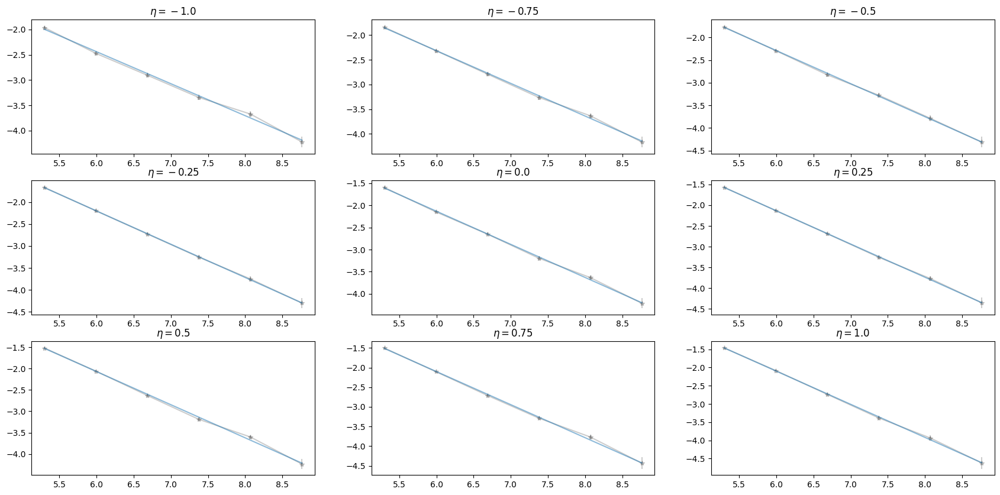

In [13]:
J_list=[0.14]
bounds=[0.8,1.5]

alpha=np.empty((len(J_list),9,2))
logk=np.empty((len(J_list),9,2))
linf_opt=np.empty((len(J_list),9))

for Ji in range(len(J_list))[::-1]:
#    try:
    tempdf_J=mean_pd[mean_pd["J"]==J_list[Ji]].drop("J",axis=1)
    tempdf_J[["lambda","err_lambda"]]=tempdf_J[["lambda","err_lambda"]].apply(lambda x: x/(J_list[Ji]**2))
    linf,r2_store=r2_method(tempdf_J,bounds[0],bounds[1],bootstrap=False,btol=1e-3,n_gridsearch=200)

    for ei in range(mean_pd["eta"].nunique()):
        plt.plot(linf[ei,:],r2_store[ei,:],label=f"$\\eta={eta_list[ei]}$")
    
    plt.legend()
    plt.title(f"J={J_list[Ji]}")
    #plt.xlim(0.0117,0.0119)
    plt.show()
    
    fig,axs=plt.subplots(3, 3,figsize=(21,10))
    linf_opt[Ji,:]=np.array([linf[li,np.nanargmax(r2_store,axis=1)[li]] for li in range(len(linf))])
    alpha[Ji,:,:], logk[Ji,:,:] = coefloop(tempdf_J,linf_opt[Ji,:],gen_fig=True,ax=axs)
    plt.show()


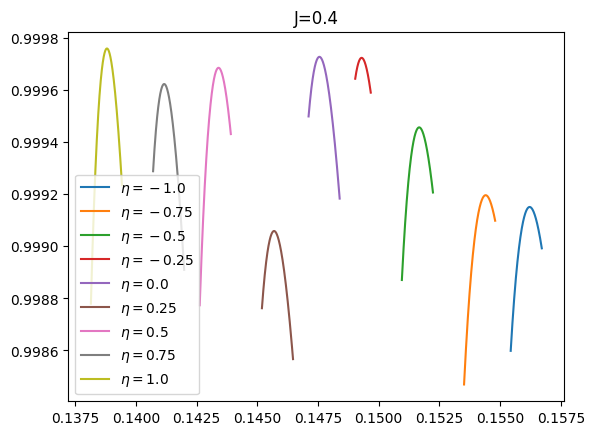

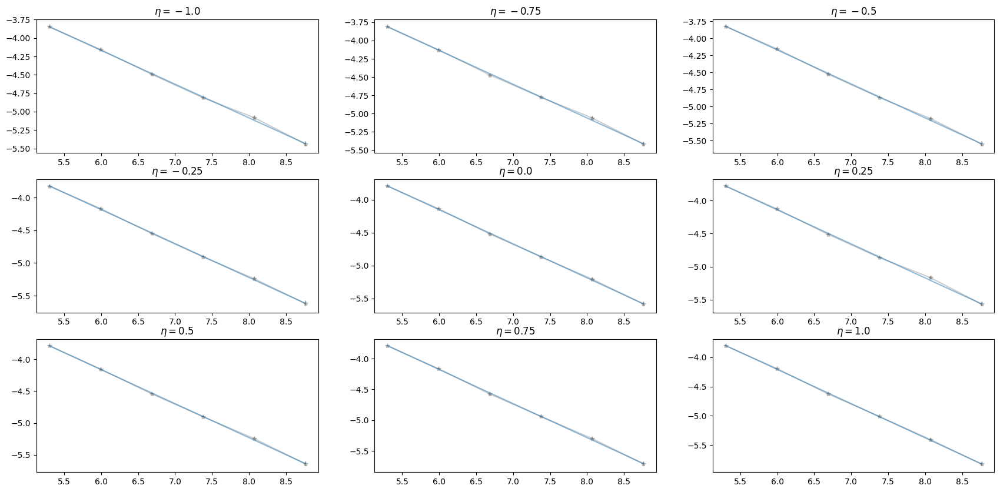

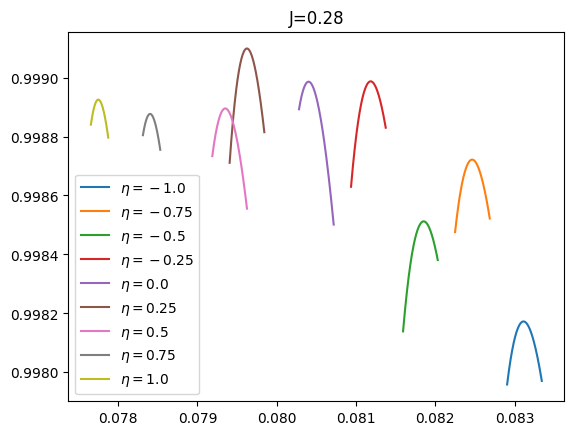

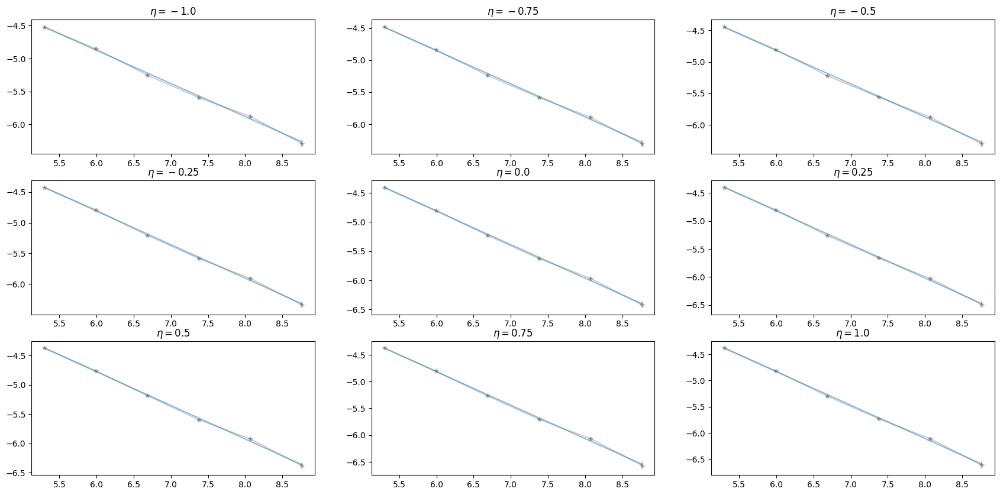

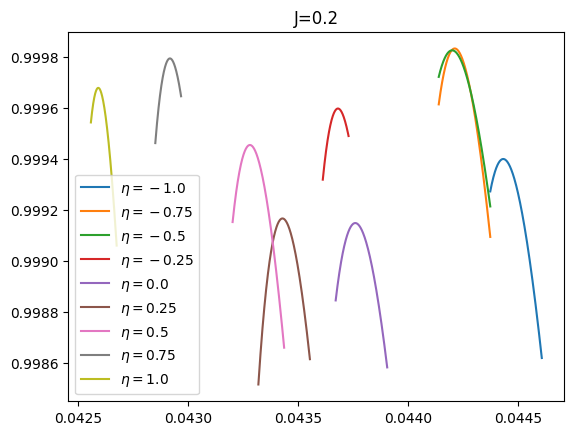

...

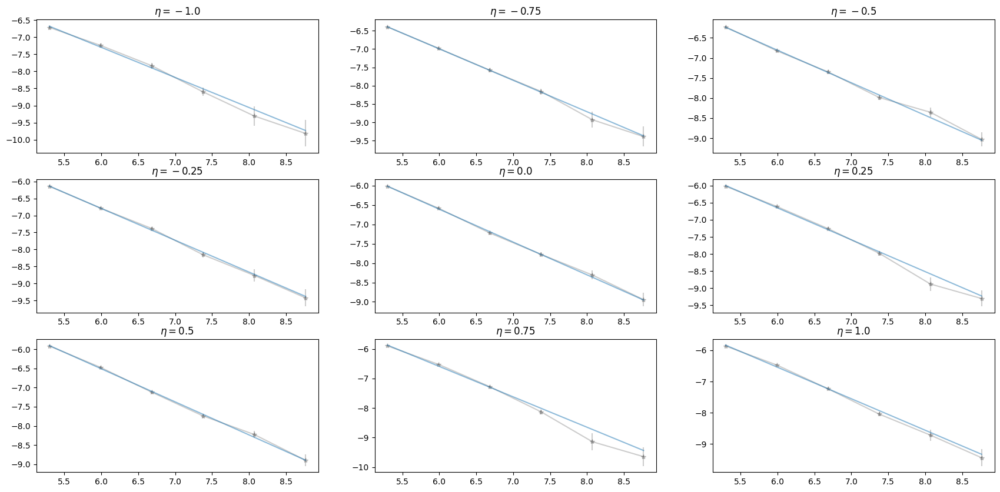

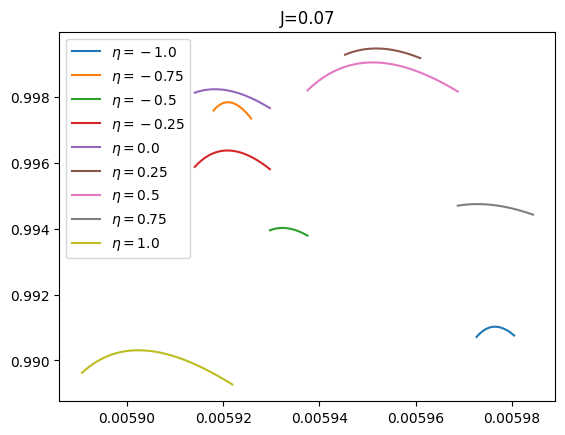

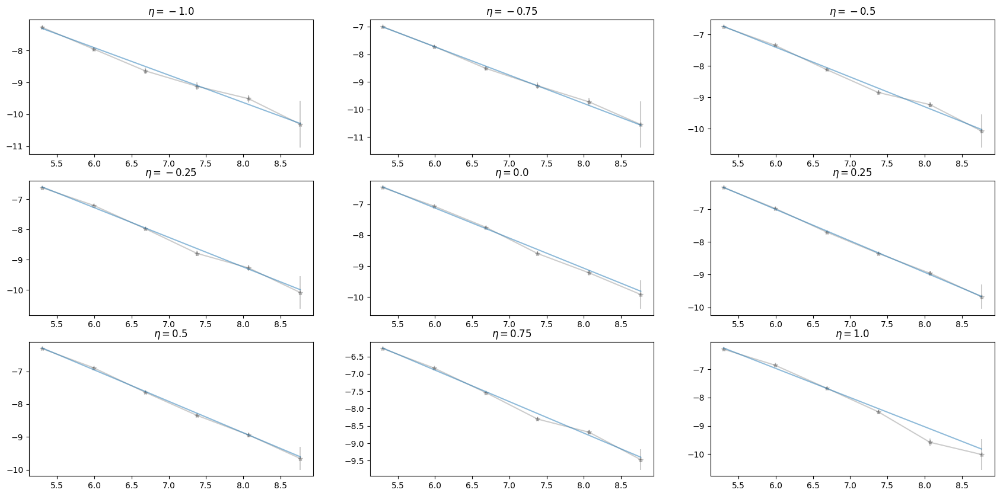

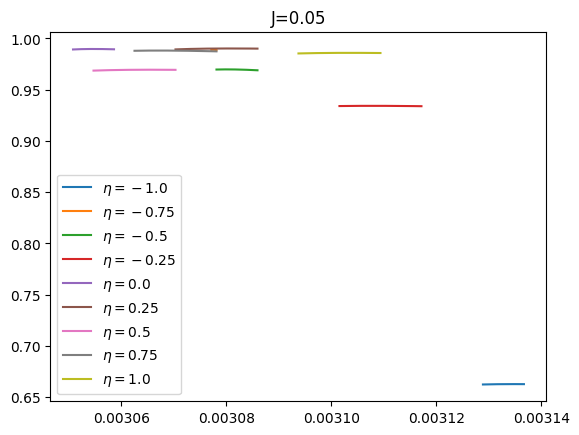

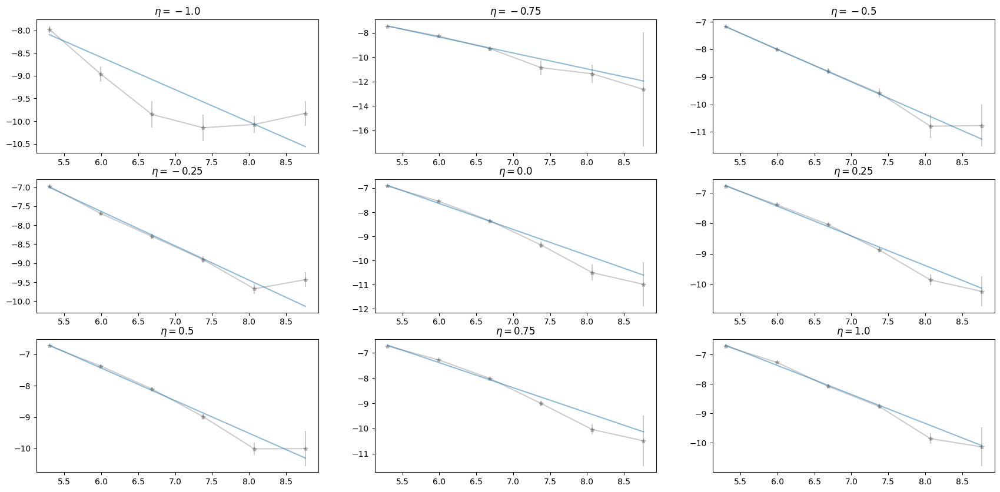

In [31]:
J_list=[0.05,0.07,0.1,0.14,0.2,0.28,0.4]
bounds=[[0.002,0.004],[0.005,0.007],[0.0113,0.012],[0.017,0.025],[0.035,0.05],[0.077,0.084],[0.1375,0.158]]

alpha=np.empty((len(J_list),9,2))
logk=np.empty((len(J_list),9,2))
linf_opt=np.empty((len(J_list),9))

for Ji in range(len(J_list))[::-1]:
#    try:
    tempdf_J=mean_pd[mean_pd["J"]==J_list[Ji]].drop("J",axis=1)
    linf,r2_store=r2_method(tempdf_J,bounds[Ji][0],bounds[Ji][1],btol=1e-3,n_gridsearch=200)

    for ei in range(mean_pd["eta"].nunique()):
        plt.plot(linf[ei,:],r2_store[ei,:],label=f"$\\eta={eta_list[ei]}$")
    
    plt.legend()
    plt.title(f"J={J_list[Ji]}")
    #plt.xlim(0.0117,0.0119)
    plt.show()
    
    fig,axs=plt.subplots(3, 3,figsize=(21,10))
    linf_opt[Ji,:]=np.array([linf[li,np.nanargmax(r2_store,axis=1)[li]] for li in range(len(linf))])
    alpha[Ji,:,:], logk[Ji,:,:] = coefloop(tempdf_J,linf_opt[Ji,:],gen_fig=True,ax=axs) ## Add uncertainty to Coef loop
    plt.show()
#    except:
#        print(f"Error for J={J_list[Ji]}")   

alpha[:,:,0]=-alpha[:,:,0]

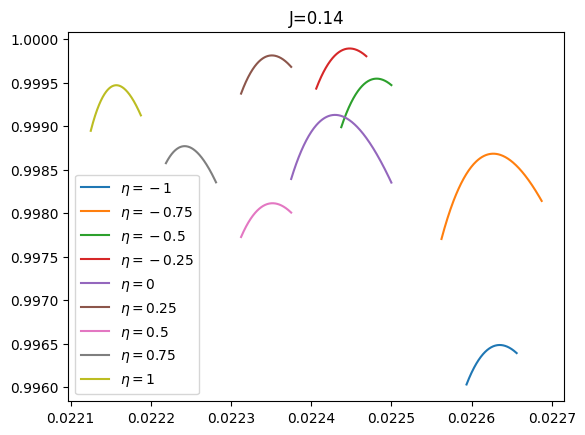

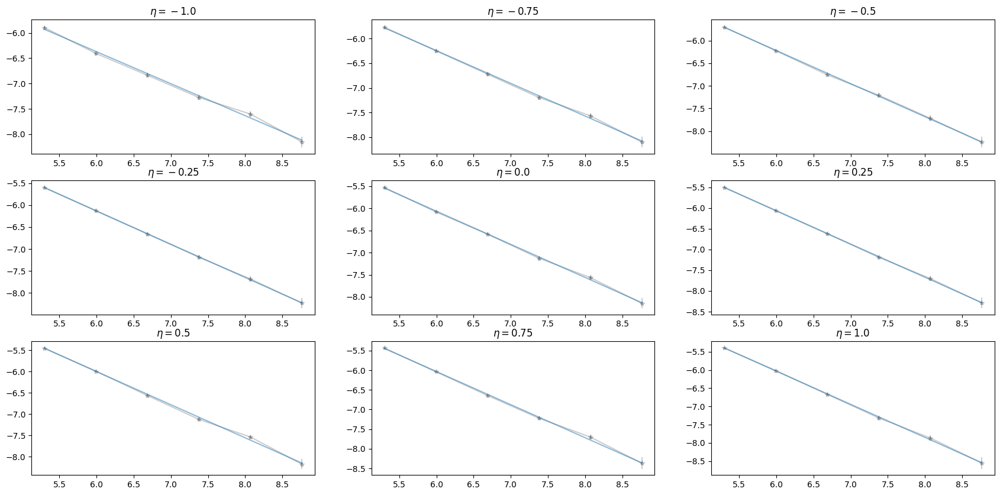

In [14]:
J_list=[0.14]
bounds=[[0.017,0.025]]

alpha=np.empty((len(J_list),9,2))
logk=np.empty((len(J_list),9,2))
linf_opt=np.empty((len(J_list),9))

for Ji in range(len(J_list))[::-1]:
#    try:
    tempdf_J=mean_pd[mean_pd["J"]==J_list[Ji]].drop("J",axis=1)
    linf,r2_store=r2_method(tempdf_J,bounds[Ji][0],bounds[Ji][1],btol=1e-3,n_gridsearch=200)

    for ei in range(mean_pd["eta"].nunique()):
        plt.plot(linf[ei,:],r2_store[ei,:],label=f"$\\eta={eta_list[ei]}$")
    
    plt.legend()
    plt.title(f"J={J_list[Ji]}")
    #plt.xlim(0.0117,0.0119)
    plt.show()
    
    fig,axs=plt.subplots(3, 3,figsize=(21,10))
    linf_opt[Ji,:]=np.array([linf[li,np.nanargmax(r2_store,axis=1)[li]] for li in range(len(linf))])
    alpha[Ji,:,:], logk[Ji,:,:] = coefloop(tempdf_J,linf_opt[Ji,:],gen_fig=True,ax=axs) ## Add uncertainty to Coef loop
    plt.show()
#    except:
#        print(f"Error for J={J_list[Ji]}")   

alpha[:,:,0]=-alpha[:,:,0]

In [32]:
def plot_par(alpha,lkappa,eta_list,linf_opt,J,axs,label=""):
    
    axs[0].plot(eta_list,linf_opt/J**2,label=label)
    axs[0].set_ylabel("$\\lambda_{\\infty}/J^2$")
    
    axs[1].errorbar(eta_list,alpha[:,0],yerr=alpha[:,1],capsize=3,fmt=".--",label=label)
    [bar.set_alpha(0.6) for bar in bars]
    [cap.set_alpha(0.6) for cap in caps]
    axs[1].set_ylabel("$\\alpha$")
    
    axs[2].errorbar(eta_list,np.exp(lkappa[:,0]),yerr=lkappa[:,1]*np.exp(lkappa[:,0]),capsize=3,fmt=".--",label=label)
    [bar.set_alpha(0.6) for bar in bars]
    [cap.set_alpha(0.6) for cap in caps]
    axs[2].set_ylabel("$\\kappa$")

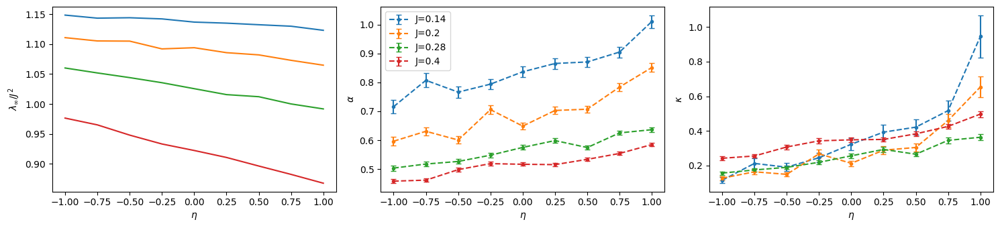

In [33]:
fig,axs=plt.subplots(1, 3,sharex=True,figsize=(15,3.5))
for Ji in range(3,len(J_list)):
    plot_par(alpha[Ji,:,:],logk[Ji,:,:],eta_list,linf_opt[Ji,:],J_list[Ji],axs,label=f"J={J_list[Ji]}")
#axs[0].set_yscale("log")
axs[1].legend()
for a in axs:
    a.set_xlabel("$\\eta$")
plt.tight_layout()
plt.show()

### Case Bootstrap for uncertainty

Through this process you might realize that there is a small issue. We want to get an uncertainty for the hyperparameter $\lambda_{\infty}$, but how? This is where we use a non-parametric case bootstrap.

By creating various sets with our data, we estimate the value of $\lambda_{\infty}$ and get its standard deviation.. Might have same higher order bias but insignificant for our case and it allows us to get this uncertainty.

In [33]:
"""
J_list=[0.14,0.2,0.28,0.4]#[0.05,0.07,0.1,0.14,0.2,0.28]
bounds=[[0.01,0.05],[0.025,0.05],[0.075,0.13],[0.135,0.165]]#[[0.002,0.006],[0.005,0.008],[0.0113,0.015],[0.017,0.025],[0.035,0.05],[0.075,0.09]]
from sklearn.utils import resample

#J_list=[0.2]
#bounds=[[0.025,0.05]]

Nboot=10000

eta_list=dataJ["eta"].unique()
linf_opt=np.empty((len(J_list),9,Nboot))

for Ji in range(len(J_list)):
    print(J_list[Ji])
    df=dataJ[dataJ["J"]==J_list[Ji]].drop("J",axis=1)

    for i in range(5000,Nboot):
        if i%(Nboot//10)==0:
            print(f"Boot {i}")
        
        bootstrapped = (
            df.groupby(["eta","N"], group_keys=False)
              .apply(lambda g: resample(g, replace=True, n_samples=len(g), random_state=i)) 
        )## Note to self: This gives the same index for each len, does not matter since each seed is independent from each other

        df_group=bootstrapped[["eta","N","lambda"]].groupby(["eta","N"],as_index=False)
    
        temp_pd=df_group.mean()
        temp_pd["err_lambda"]=df_group.std()["lambda"]/df_group.count()["lambda"].apply(np.sqrt)
        
        linf,r2_store=r2_method(temp_pd,bounds[Ji][0],bounds[Ji][1],btol=5e-3,n_gridsearch=100)

#        for ei in range(mean_pd["eta"].nunique()):
#            plt.plot(linf[ei,:],r2_store[ei,:],label=f"$\\eta={eta_list[ei]}$")
        
#        plt.legend()
#        plt.title(f"J={J_list[Ji]}")
        #plt.xlim(0.0117,0.0119)
#        plt.show()

        linf_opt[Ji,:,i]=np.array([linf[li,np.nanargmax(r2_store,axis=1)[li]] for li in range(len(linf))])

#        fig,axs=plt.subplots(3, 3,figsize=(21,10))
#        _,_ = coefloop(temp_pd,linf_opt[Ji,:,i],gen_fig=True,ax=axs)
#        plt.show()

#np.save("linfopt_bootstrap.npy",linf_opt)
""";

In [13]:
linf_opt_boot=np.load("linfopt_bootstrap.npy") #This is for J_list=[0.14,0.2,0.28,0.4]
#linf_opt_0p14_0p2=np.load("linfopt_bootstrap_J014_J02.npy")
#linf_opt_0p28_0p4=np.load("linfopt_bootstrap_J028_J04.npy")

J=0.14
1.1331e-04
9.9473e-05
1.0168e-04
1.0698e-04
1.0057e-04
8.8538e-05
9.4272e-05
9.8438e-05
7.0184e-05


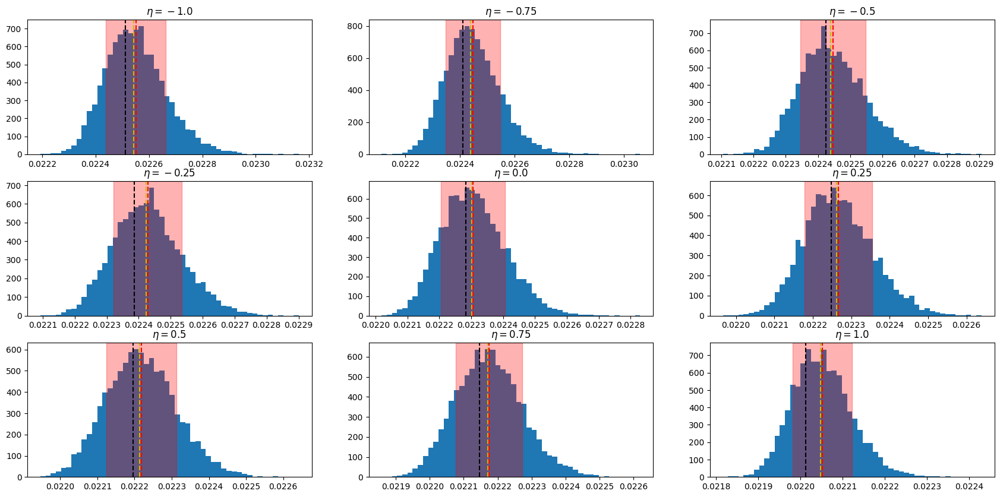

J=0.2
2.1134e-04
2.1326e-04
2.3371e-04
1.9345e-04
2.0159e-04
1.5067e-04
1.7626e-04
1.4052e-04
1.2747e-04


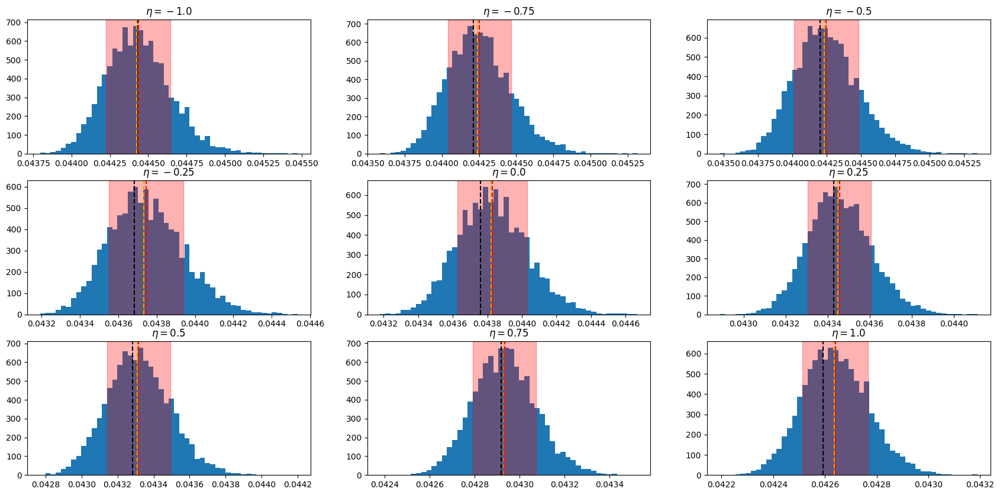

J=0.28
4.5142e-04
4.0906e-04
3.6369e-04
3.5462e-04
3.2167e-04
3.3556e-04
3.1266e-04
2.8686e-04
2.8933e-04


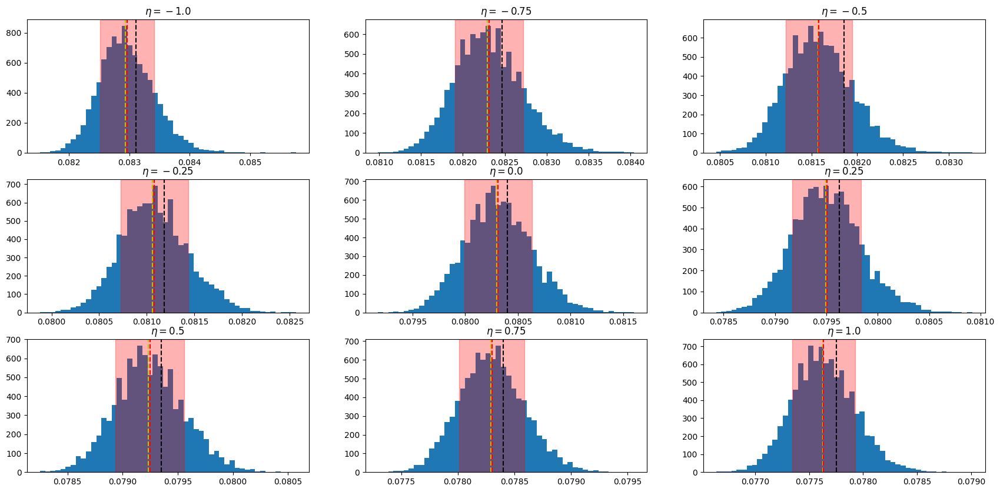

J=0.4
7.2611e-04
7.2395e-04
6.5118e-04
6.3100e-04
5.1904e-04
5.3067e-04
4.8644e-04
4.5476e-04
3.6482e-04


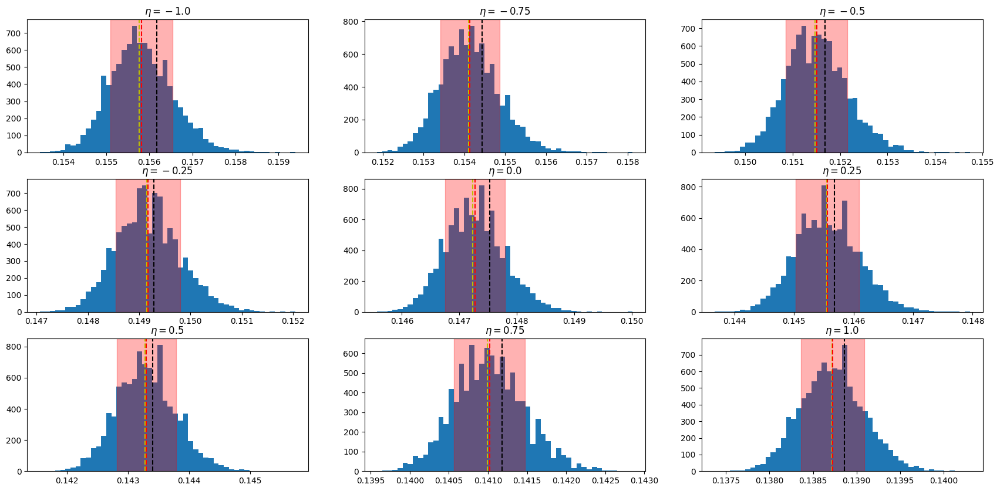

In [23]:
J_list=[0.14,0.2,0.28,0.4]
for Ji in range(len(J_list)):
    
    fig,axs=plt.subplots(3, 3,figsize=(21,10))
    
    J=J_list[Ji]
    print(f"J={J}")
    
    for ei in range(len(eta_list)):    
        eta=eta_list[ei]

        axs=axs.flatten()
        axs[ei].hist(linf_opt_boot[Ji,ei,:],bins=50,density=False)
        axs[ei].axvline(np.median(linf_opt_boot[Ji,ei,:]),linestyle="--",color="y")
        axs[ei].axvline(linf_df_mean[(linf_df_mean["J"]==J) & (linf_df_mean["eta"]==eta)]["linf_opt"].values[0],linestyle="--",color="k")
        
        axs[ei].set_title(f"$\\eta={eta_list[ei]}$")
        
        m=np.mean(linf_opt_boot[Ji,ei,:])
        s=np.std(linf_opt_boot[Ji,ei,:])
        
        print(f"{s:.4e}")
        
        axs[ei].axvline(m,linestyle="--",color="r")
        axs[ei].axvspan(m-s, m+s, color="r", alpha=0.3)
        
    plt.show()

#### Subsets

On a previous idea, we thought of making subsets of the data and get the error through there. This is here just for acknowledgment.

The main issue with this method is that subsets will have less data than the total set, procuring an more error and a larger tail in the estimation if, unluckily, the $R^2$ estimation of $\lambda_{\infty}$ fails.

In [124]:
J_list=[0.05,0.07,0.1,0.14,0.2]
bounds=[[0.002,0.004],[0.005,0.007],[0.0113,0.012],[0.017,0.025],[0.035,0.05]]
eta_list=dataJ["eta"].unique()
out=[]
for Ji in range(len(J_list)):
    print(J_list[Ji])
    mean_linf, std_linf,_=yet_another_loop_subsets(dataJ,bounds[Ji],J_list[Ji],M=100)
    linf_df_av=pd.DataFrame({"eta":eta_list,"m_linf":mean_linf,"std_linf":std_linf})
    linf_df_av["J"]=J_list[Ji]
    out.append(linf_df_av)
    
linf_df_av=pd.concat(out)

0.05
0.07
0.1
0.14
0.2


In [11]:
J_list=[0.05,0.07,0.1,0.14,0.2,0.28]
bounds=[[0.002,0.006],[0.005,0.008],[0.0113,0.015],[0.017,0.025],[0.035,0.05],[0.075,0.09]]
eta_list=dataJ["eta"].unique()
out=[]
linfs_out=[]

sdf=subsets_df(dataJ,Nsubsets=2)
for Ji in range(len(J_list)):
    print(J_list[Ji])
    A=sdf[sdf["J"]==J_list[Ji]].drop("J",axis=1)
    linfs,mean_linf,std_linf,std_dof=yet_another_loop_subsets(A,bounds[Ji])
#    print(linfs)
    print(np.min(linfs),np.max(linfs),"\n")
    linfs_out.append(linfs)
    linf_df_av=pd.DataFrame({"eta":eta_list,"m_linf":mean_linf,"std_linf":std_linf,"std_linf_dof":std_dof})
    linf_df_av["J"]=J_list[Ji]
    out.append(linf_df_av)
    
linf_df_av=pd.concat(out)
linf_df_av

0.05
0.0030159505208333334 0.005361111111111111 

0.07
0.005842447916666667 0.007067708333333335 

0.1
0.011662131076388887 0.012475520833333332 

0.14
0.021895833333333333 0.023541666666666666 

0.2
0.042288411458333335 0.045703125 

0.28
0.07680338541666666 0.08477864583333333 



,eta,m_linf,std_linf,std_linf_dof,J
0,-1.00000e+00,3.42019e-03,2.02012e-05,5.11054e-05,5.00000e-02
1,-7.50000e-01,3.16064e-03,1.61602e-05,4.08823e-05,5.00000e-02
2,-5.00000e-01,3.14091e-03,1.76170e-05,4.45679e-05,5.00000e-02
3,-2.50000e-01,3.12689e-03,1.50948e-05,3.81871e-05,5.00000e-02
4,0.00000e+00,3.09092e-03,6.58535e-06,1.66598e-05,5.00000e-02
5,2.50000e-01,3.12108e-03,9.45673e-06,2.39239e-05,5.00000e-02
6,5.00000e-01,3.24877e-03,5.70316e-05,1.44280e-04,5.00000e-02
7,7.50000e-01,3.28037e-03,5.12197e-05,1.29577e-04,5.00000e-02
8,1.00000e+00,3.21565e-03,3.14446e-05,7.95494e-05,5.00000e-02
0,-1.00000e+00,6.03740e-03,1.73567e-05,4.39093e-05,7.00000e-02


J=0.14	 eta=-1


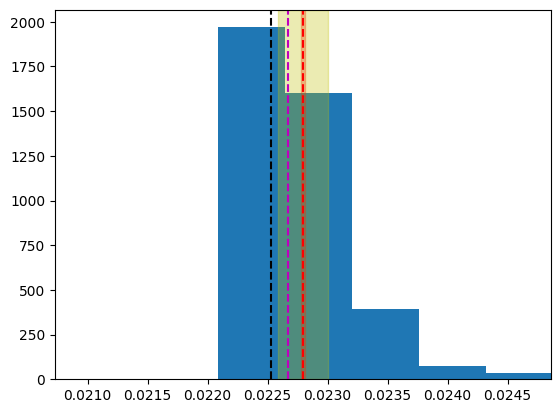

J=0.14	 eta=-0.75


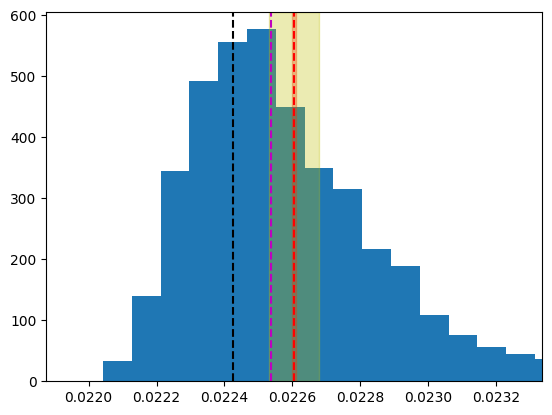

J=0.14	 eta=-0.5


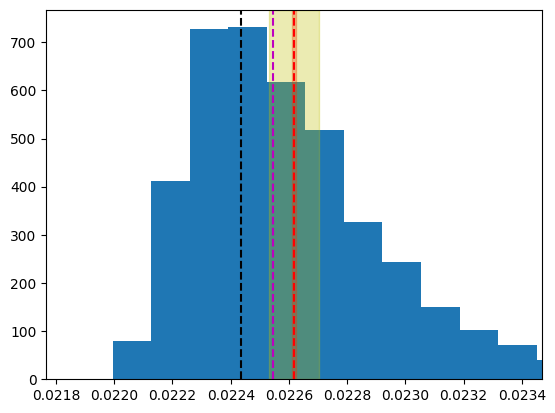

J=0.14	 eta=-0.25


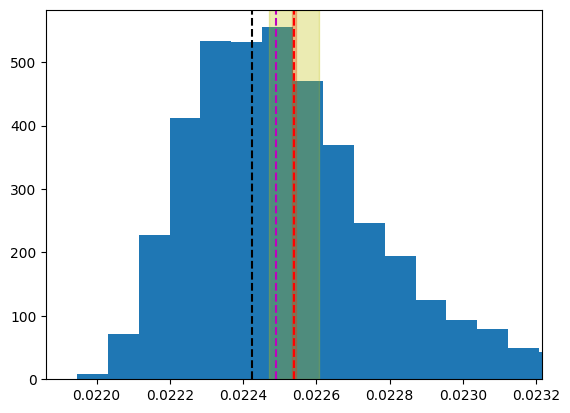

J=0.14	 eta=0


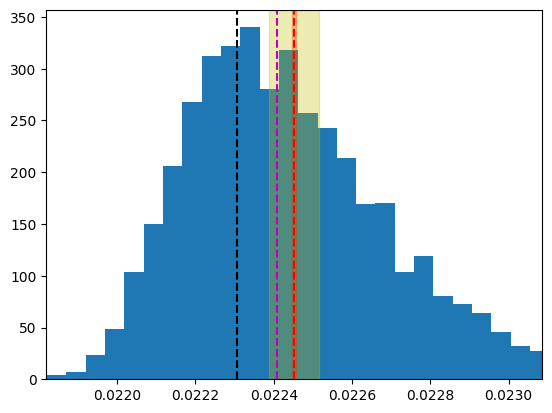

J=0.14	 eta=0.25


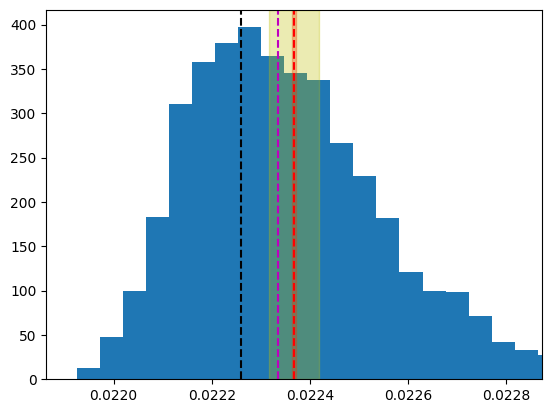

J=0.14	 eta=0.5


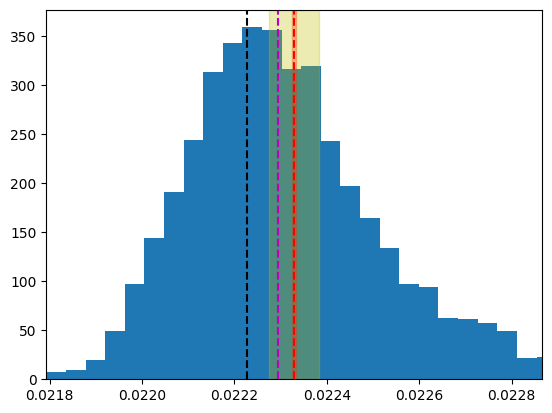

J=0.14	 eta=0.75


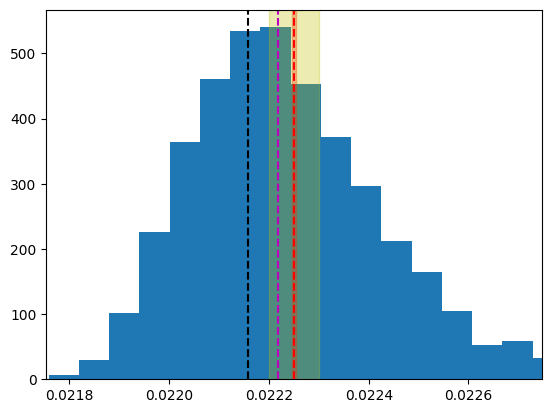

J=0.14	 eta=1


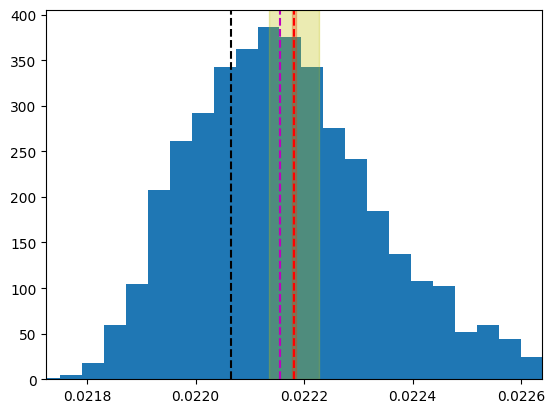

J=0.2	 eta=-1


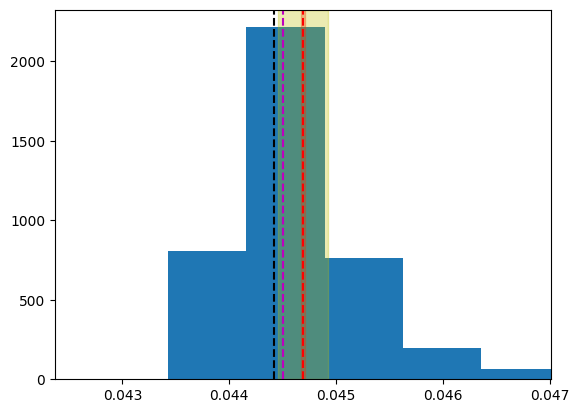

J=0.2	 eta=-0.75


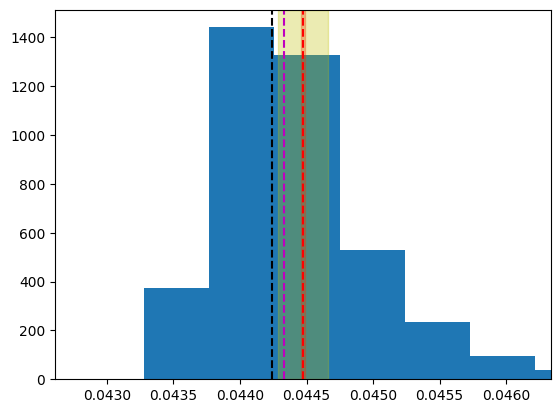

J=0.2	 eta=-0.5


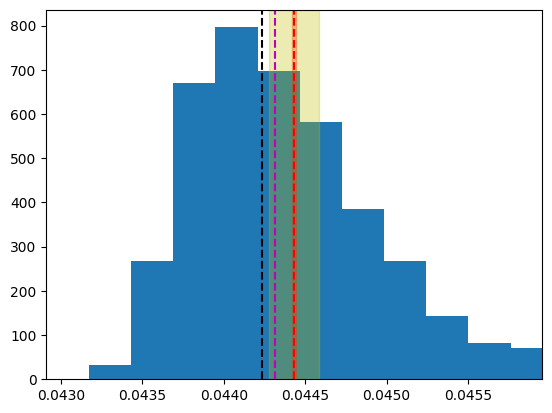

J=0.2	 eta=-0.25


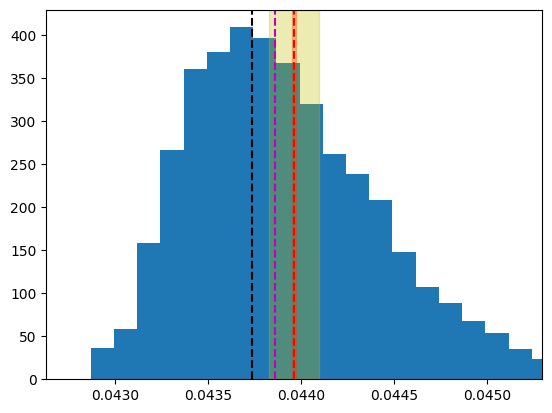

J=0.2	 eta=0


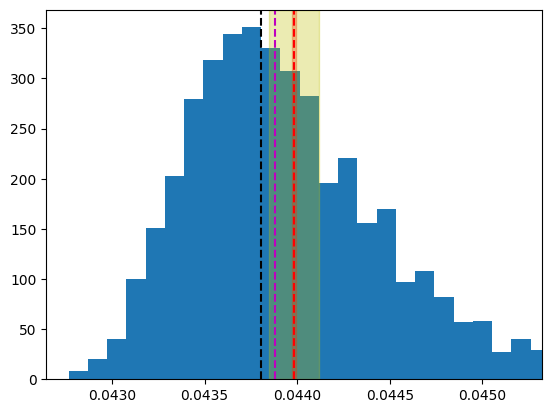

J=0.2	 eta=0.25


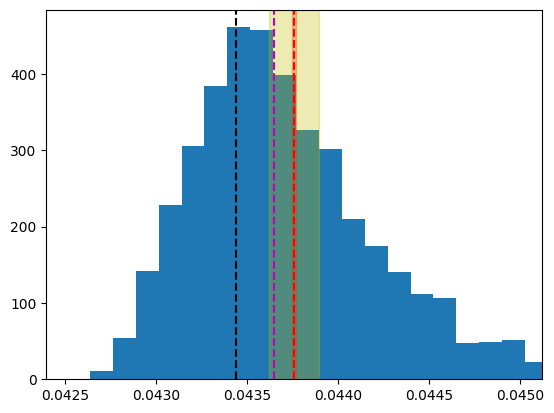

J=0.2	 eta=0.5


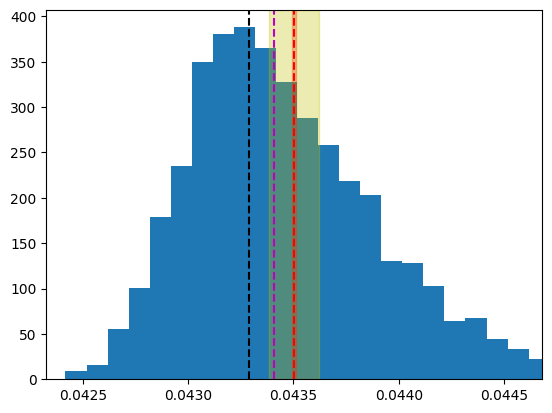

J=0.2	 eta=0.75


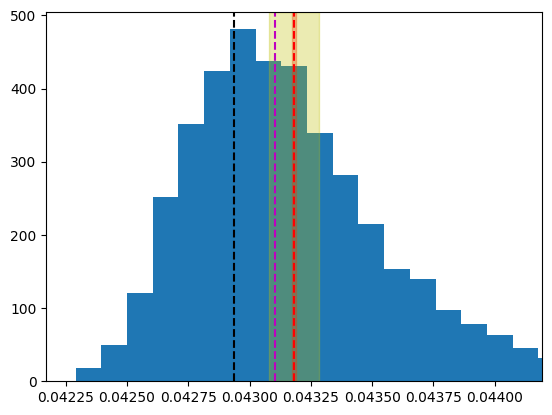

J=0.2	 eta=1


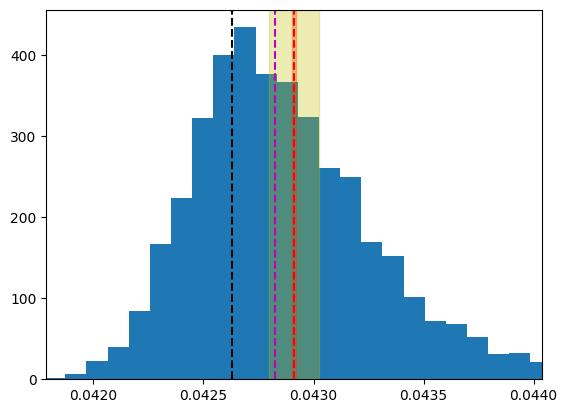

J=0.28	 eta=-1


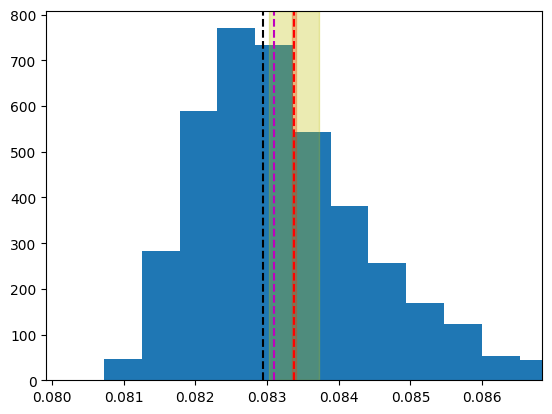

J=0.28	 eta=-0.75


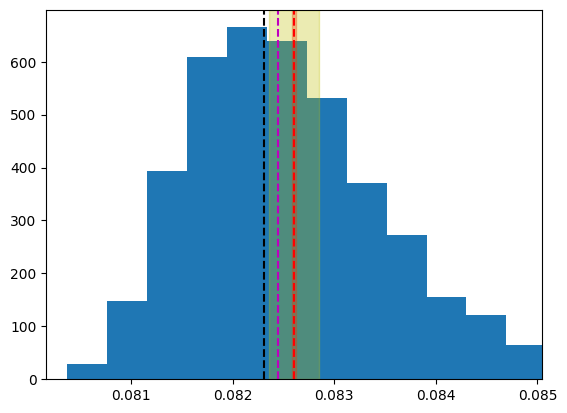

J=0.28	 eta=-0.5


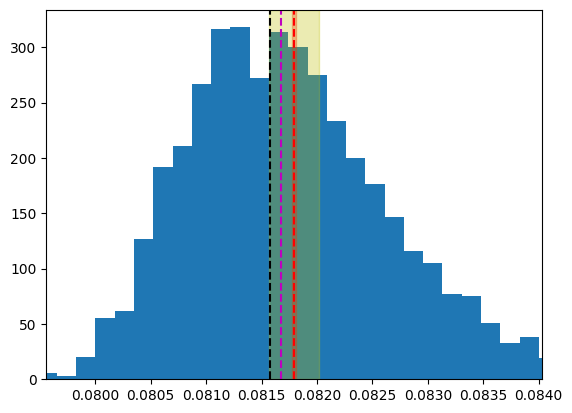

J=0.28	 eta=-0.25


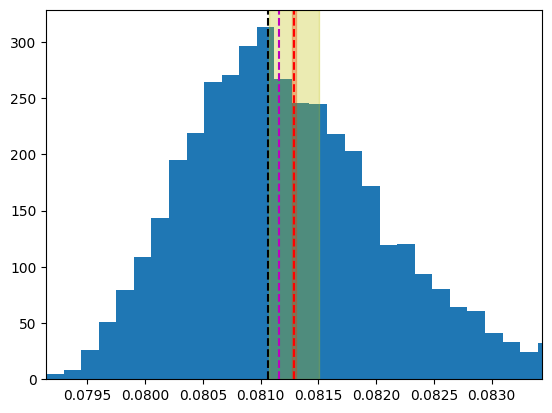

J=0.28	 eta=0


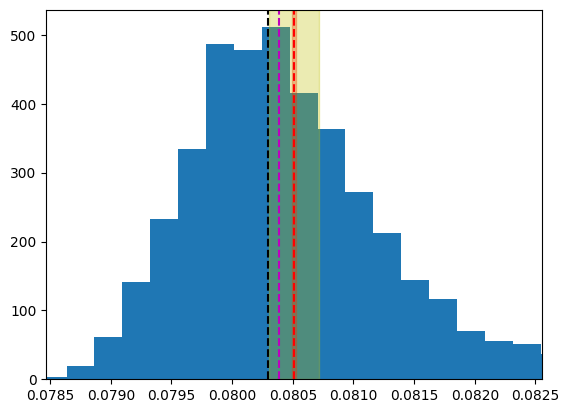

J=0.28	 eta=0.25


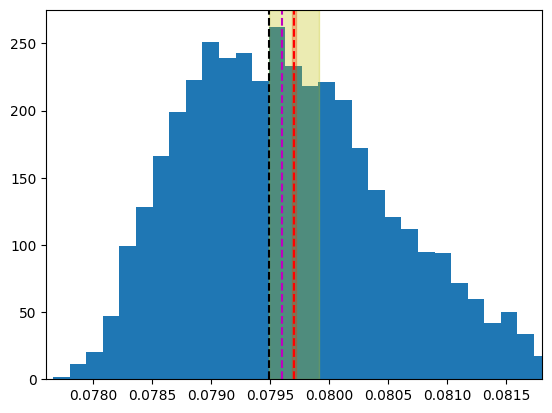

J=0.28	 eta=0.5


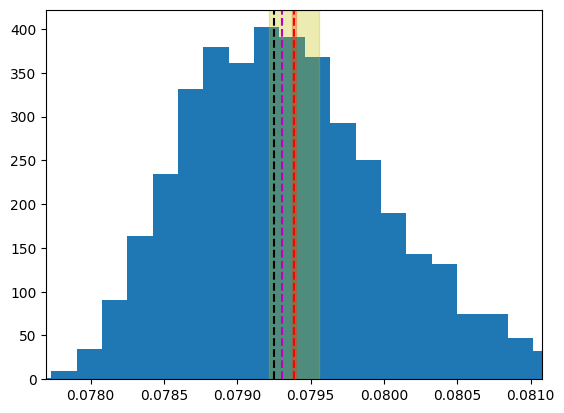

J=0.28	 eta=0.75


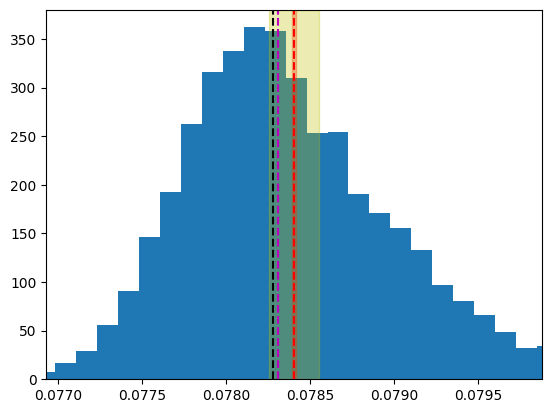

J=0.28	 eta=1


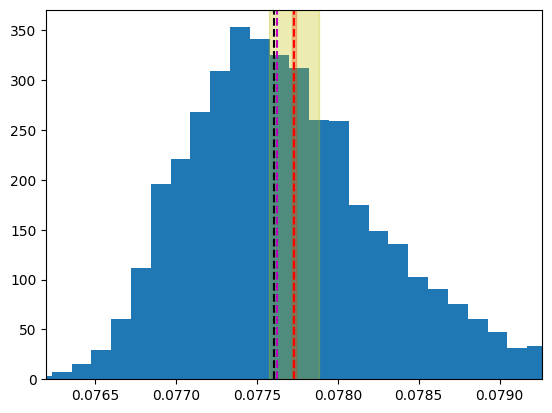

J=0.4	 eta=-1


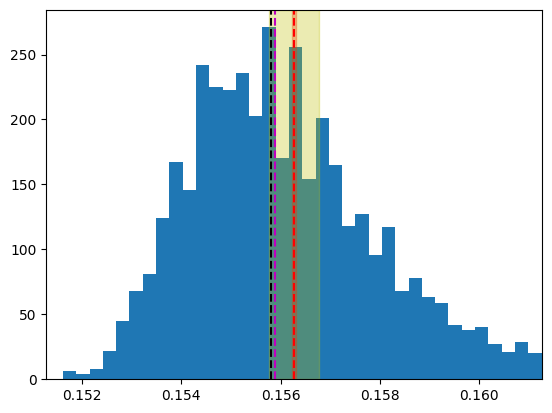

J=0.4	 eta=-0.75


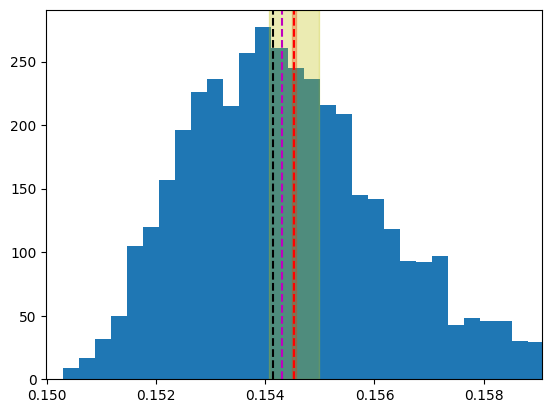

J=0.4	 eta=-0.5


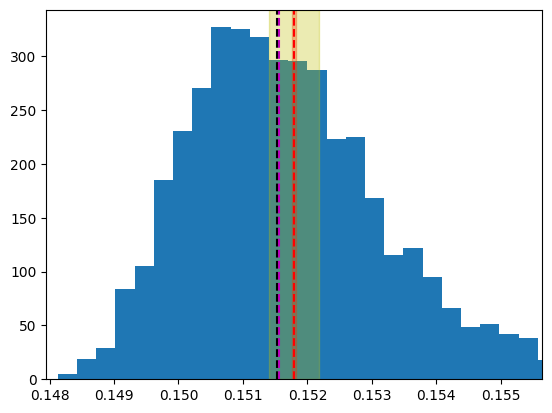

J=0.4	 eta=-0.25


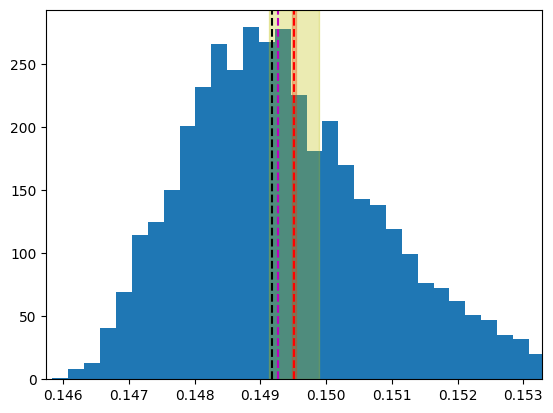

J=0.4	 eta=0


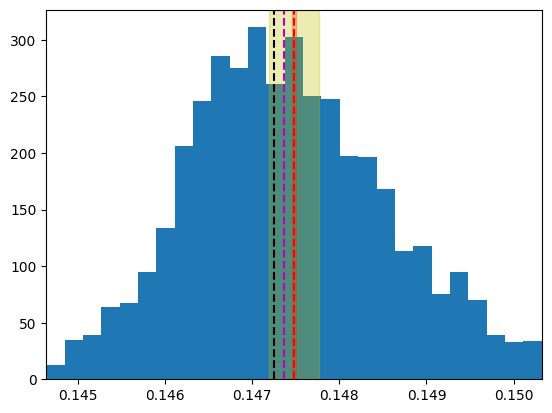

J=0.4	 eta=0.25


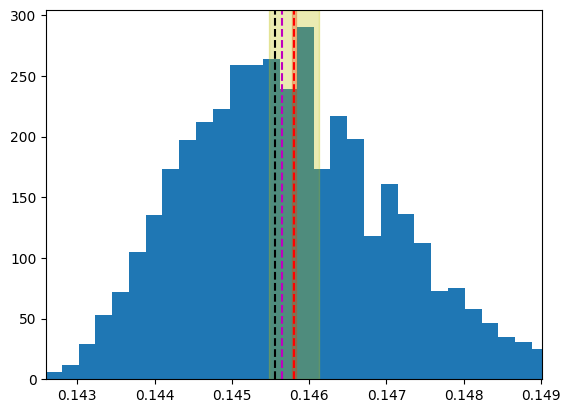

J=0.4	 eta=0.5


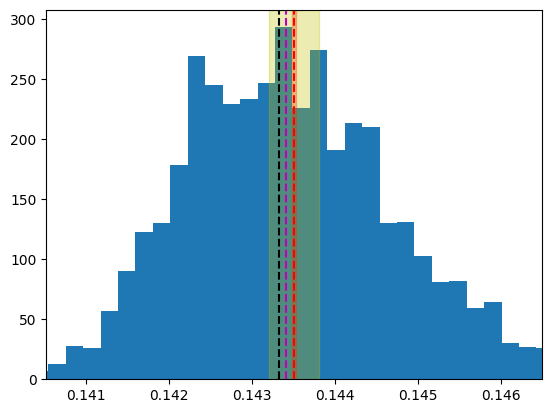

J=0.4	 eta=0.75


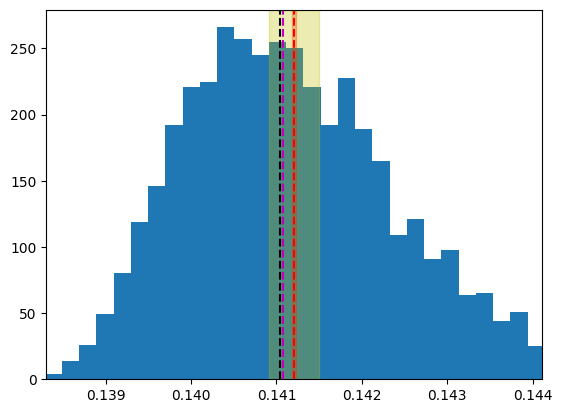

J=0.4	 eta=1


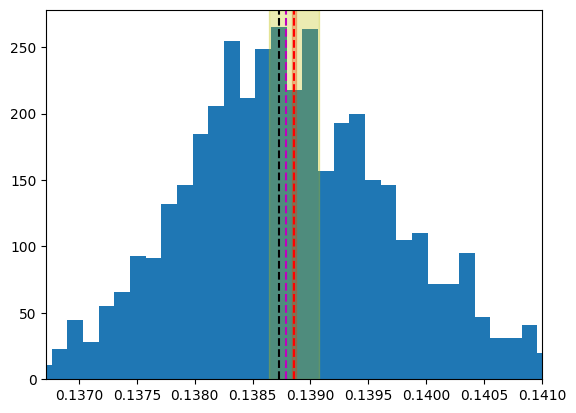

In [30]:
J_list=[0.05,0.07,0.1,0.14,0.2,0.28,0.4]
eta_list=[-1,-0.75,-0.5,-0.25,0,0.25,0.5,0.75,1]

for Ji in range(3,len(J_list)):
    for ei in range(len(eta_list)):
        J=J_list[Ji]
        eta=eta_list[ei]
        print(f"J={J}\t eta={eta}")
        
        plt.hist(linfs_out_4[Ji-3][ei],bins=50,density=False)
        plt.axvline(np.median(linfs_out_4[Ji-3][ei]),linestyle="--",color="m")
        plt.axvline(linf_df_mean[(linf_df_mean["J"]==J) & (linf_df_mean["eta"]==eta)]["linf_opt"].values[0],linestyle="--",color="k")
        
        m,s,s2=linf_df_av_4[(linf_df_av_4["J"]==J) & (linf_df_av_4["eta"]==eta)].values[0,1:-1]
        plt.axvline(m,linestyle="--",color="r")
        
        plt.axvspan(m-s, m+s, color="r", alpha=0.3)
        plt.axvspan(m-s2, m+s2, color="y", alpha=0.3)
        plt.xlim(m-10*s2,m+10*s2)
        plt.show()

### Result with $\lambda_{\infty}$ and error

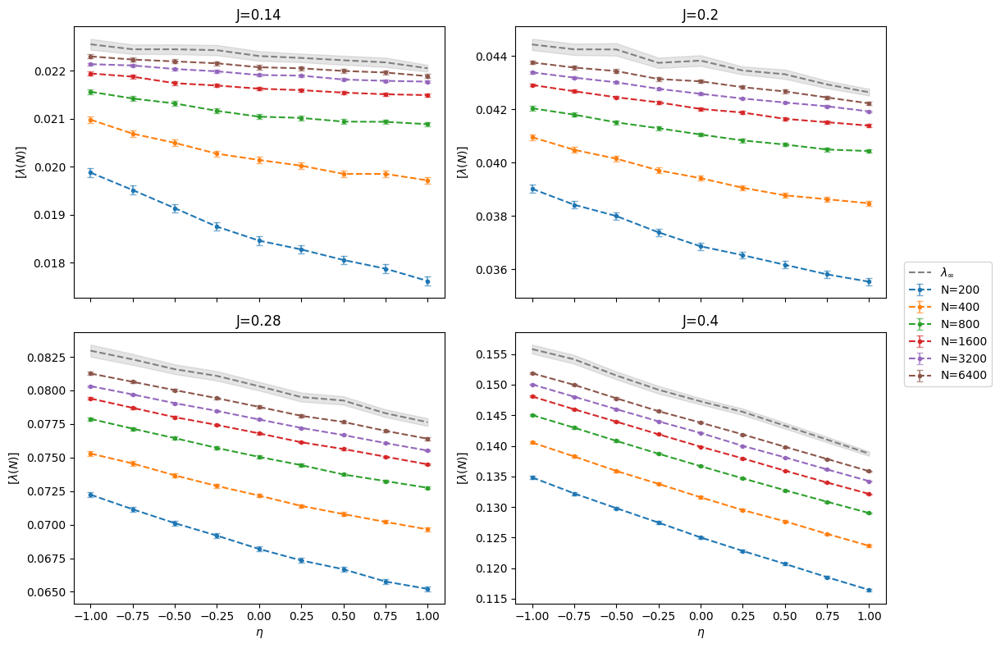

In [24]:
Jlist=[0.14,0.2,0.28,0.4]
Nlist=[200,400,800,1600,3200,6400]

fig, axs=plt.subplots(2,2,figsize=(11,8),sharex=True)
axs=axs.flatten()

for Ji in range(len(Jlist)):
    J=Jlist[Ji]
    tempdf_J=mean_pd[mean_pd["J"]==J]
    for N in tempdf_J["N"].unique():
        tempN=tempdf_J[tempdf_J["N"]==N]
        markers,caps,bars=axs[Ji].errorbar(tempN["eta"],tempN["lambda"],yerr=tempN["err_lambda"],capsize=3,fmt=".--",label=f"N={N:d}")
        [bar.set_alpha(0.6) for bar in bars]
        [cap.set_alpha(0.6) for cap in caps]
    axs[Ji].set_title(f"J={J}")
    
    m=np.mean(linf_opt_boot[Ji,:,:],axis=1)
    s=np.std(linf_opt_boot[Ji,:,:],axis=1)

    axs[Ji].plot(eta_list,m,"--",color="gray",label=f"$\lambda_{{\infty}}$")
    axs[Ji].fill_between(eta_list,(m+s),(m-s),alpha=0.2,color="gray")

#axs[0].set_ylabel("$\\frac{[\lambda(N)]}{J^2}$",rotation=0)
axs[0].set_ylabel("$[\lambda(N)]$")
axs[1].set_ylabel("$[\lambda(N)]$")
axs[2].set_ylabel("$[\lambda(N)]$")
axs[3].set_ylabel("$[\lambda(N)]$")

axs[2].set_xlabel("$\eta$")
axs[3].set_xlabel("$\eta$")

handles,labels=axs[0].get_legend_handles_labels()
fig.legend(handles,labels,loc="center left", bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.show()

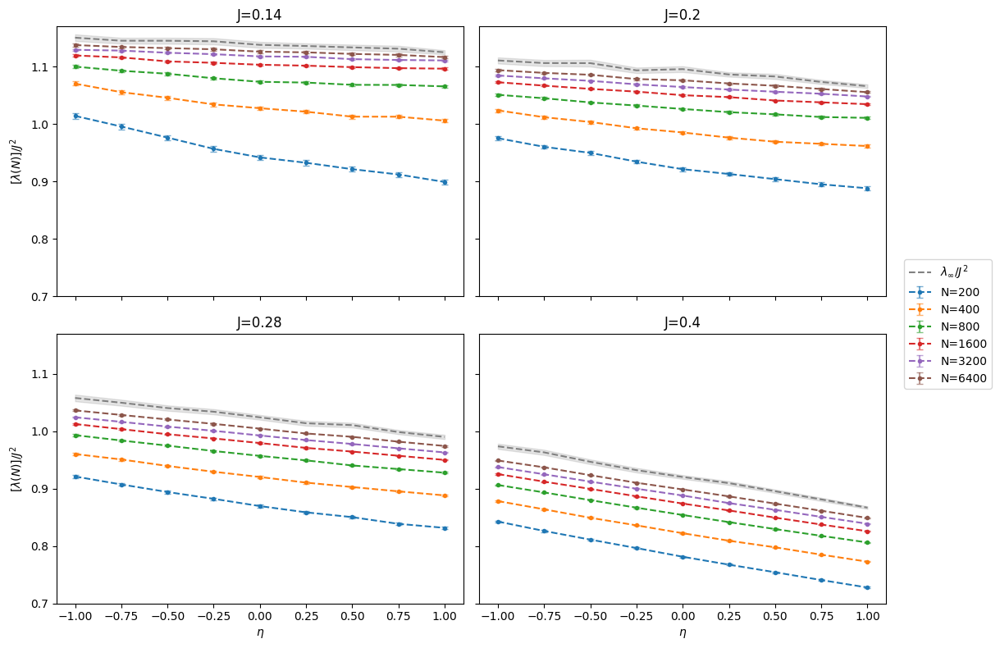

In [25]:
Jlist=[0.14,0.2,0.28,0.4]

fig, axs=plt.subplots(2,2,figsize=(11,8),sharex=True,sharey=True)
axs=axs.flatten()

for Ji in range(len(Jlist)):
    J=Jlist[Ji]
    tempdf_J=mean_pd[mean_pd["J"]==J]
    for N in tempdf_J["N"].unique():
        tempN=tempdf_J[tempdf_J["N"]==N]
        markers,caps,bars=axs[Ji].errorbar(tempN["eta"],tempN["lambda"]/J**2,yerr=tempN["err_lambda"]/J**2,capsize=3,fmt=".--",label=f"N={N:d}")
        [bar.set_alpha(0.6) for bar in bars]
        [cap.set_alpha(0.6) for cap in caps]
    axs[Ji].set_title(f"J={J}")
    axs[Ji].set_ylim(0.7,1.17)
    
    m=np.mean(linf_opt_boot[Ji,:,:],axis=1)
    s=np.std(linf_opt_boot[Ji,:,:],axis=1)

    axs[Ji].plot(eta_list,m/J**2,"--",color="gray",label=f"$\lambda_{{\infty}}/J^2$")
    axs[Ji].fill_between(eta_list,(m+s)/J**2,(m-s)/J**2,alpha=0.2,color="gray")

#axs[0].set_ylabel("$\\frac{[\lambda(N)]}{J^2}$",rotation=0)
axs[0].set_ylabel("$[\lambda(N)]/J^2$")
axs[2].set_ylabel("$[\lambda(N)]/J^2$")
axs[2].set_xlabel("$\eta$")
axs[3].set_xlabel("$\eta$")

handles,labels=axs[0].get_legend_handles_labels()
fig.legend(handles,labels,loc="center left", bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.show()

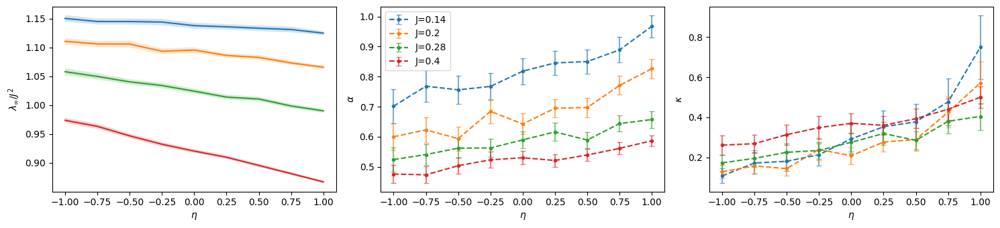

In [26]:
Jlist=[0.14,0.2,0.28,0.4]

fig,axs=plt.subplots(1, 3,sharex=True,figsize=(15,3.5))

for Ji in range(len(J_list)):
    
    m=np.mean(linf_opt_boot[Ji,:,:],axis=1)
    s=np.std(linf_opt_boot[Ji,:,:],axis=1)
    J=J_list[Ji]
    
    alpha,logk=coefloop(mean_pd[mean_pd["J"]==J].drop("J",axis=1),m,linf_err=s)

    alpha[:,0]=-alpha[:,0]
    
    axs[0].errorbar(eta_list,m/J**2,label=f"J={J_list[Ji]}")
    axs[0].fill_between(eta_list,(m+s)/J**2,(m-s)/J**2,alpha=0.2)
    axs[0].set_ylabel("$\\lambda_{\\infty}/J^2$")
    
    _,bars,caps=axs[1].errorbar(eta_list,alpha[:,0],yerr=alpha[:,1],capsize=3,fmt=".--",label=f"J={J_list[Ji]}")
    [bar.set_alpha(0.6) for bar in bars]
    [cap.set_alpha(0.6) for cap in caps]
    axs[1].set_ylabel("$\\alpha$")
    
    _,bars,caps=axs[2].errorbar(eta_list,np.exp(logk[:,0]),yerr=logk[:,1]*np.exp(logk[:,0]),capsize=3,fmt=".--",label=f"J={J_list[Ji]}")
    [bar.set_alpha(0.6) for bar in bars]
    [cap.set_alpha(0.6) for cap in caps]
    axs[2].set_ylabel("$\\kappa$")
    
#axs[0].set_yscale("log")
axs[1].legend()
for a in axs:
    a.set_xlabel("$\\eta$")
plt.tight_layout()
plt.show()

## Weak coupling regime

Using the Lyapunov exponent in the thermodynamic limit, we can analyze the effects of the heterogeneity $\eta$ and its tendency to the weak coupling regime ($J\to 0$).

By fitting a linear and a quadratic function in $J$, we observe a decrease of deviation and the (non-)dependecy with the asymetry parameter $\eta$. 

$$
\lambda_{\infty}\approx c+dJ(+mJ^2)
$$

In [36]:
def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

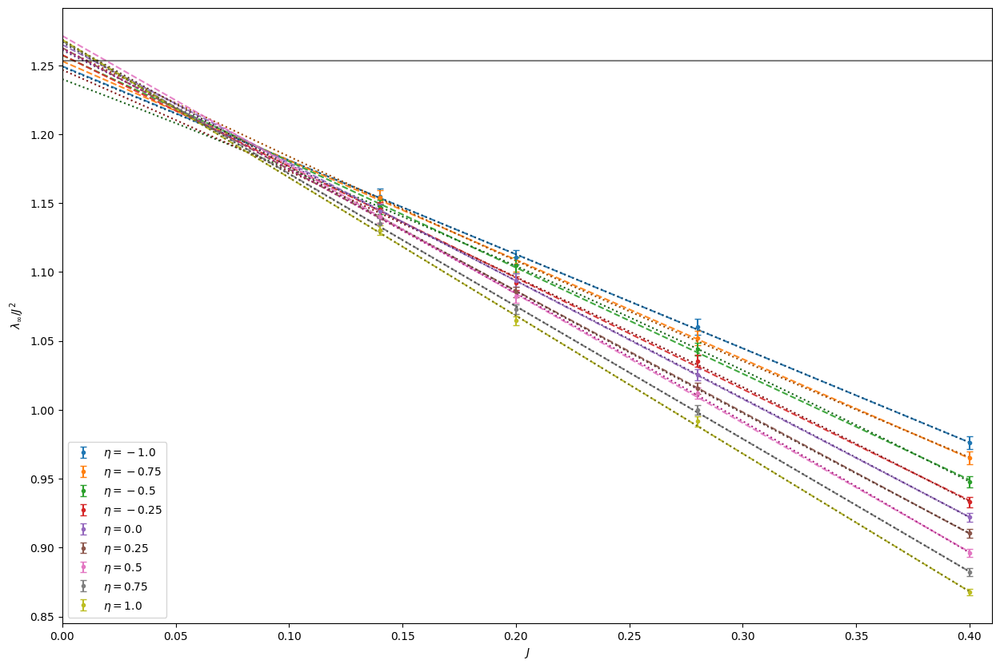

In [43]:
plt.figure(figsize=(15,10))

J_list=np.array([0.14,0.2,0.28,0.4])
eta_list=linf_df_mean["eta"].unique()

s=np.std(linf_opt_boot[:,:,:],axis=2)

cmap = generate_colormap(len(eta_list), palette_type="categorical")

c1=[]
d1=[]

p_all=[]

def f_fit1(J,p):
    return p[0]+p[1]*J

c2=[]
m2=[]
def f_fit2(J,p):
    return p[0]+p[1]*(J**2)

c12=[]
d12=[]
m12=[]
def f_fit12(J,p):
    return p[0]+p[1]*J+p[2]*(J**2)

Jrange=np.linspace(0,J_list[-1])

for ei in range(len(eta_list)):
    
    ydata=linf_df_mean[(linf_df_mean["eta"]==eta_list[ei]) & (linf_df_mean["J"].isin(J_list))]["linf_opt"]/J_list**2
    plt.errorbar(J_list, ydata, yerr=s[:,ei]/J_list**2, color=cmap[ei],capsize=3,fmt=".",label=f"$\\eta={eta_list[ei]}$")

    pfit, perr, r2_1 = fit_curvefit(J_list, ydata, lambda x,p0,p1: p0+p1*x, np.array([0,1]),yerr=s[:,ei]/J_list**2)
#    pfit, perr, r2_1, pfits_all = fit_bootstrap(J_list, ydata, lambda x,p: p[0]+p[1]*x, np.array([0,1]),yerr=s[:,ei]/J_list**2,Nsamples=5000,Nsigma=2,out_all=True)
    plt.plot(Jrange,f_fit1(Jrange,pfit),"--",alpha=0.9,color=adjust_lightness(cmap[ei],amount=1))
#    for p in pfits_all[::500]:
#        plt.plot(Jrange,f_fit1(Jrange,p),"-",alpha=0.1,color=cmap[ei])
    
    c1.append([pfit[0],perr[0]])
    d1.append([pfit[1],perr[1]])
    
#    p_all.append(pfits_all)

#    pfit, perr, r2_2 = fit_curvefit(J_list, ydata,lambda x,p0,p2: p0+p2*(x**2), np.array([0,0]), yerr=s[:,ei]/J_list**2)
#    plt.plot(np.linspace(0,J_list[-1]),f_fit2(np.linspace(0,J_list[-1]),pfit),":", color=adjust_lightness(cmap[ei],amount=0.6))
#    c2.append([pfit[0],perr[0]])
#    m2.append([pfit[1],perr[1]])
    
#    pfit, perr, r2_12 = fit_curvefit(J_list, ydata,lambda x,p0,p1,p2: p0+p1*x+p2*(x**2), np.array([0,1,0]), yerr=s[:,ei]/J_list**2)
#    pfit, perr, r2_12 = fit_bootstrap(J_list, ydata,lambda x,p: p[0]+p[1]*x+p[2]*(x**2), np.array([0,1,0]), yerr=s[:,ei]/J_list**2,Nsamples=1000,Nsigma=2)
#    plt.plot(np.linspace(0,J_list[-1]),f_fit12(np.linspace(0,J_list[-1]),pfit),":", color=adjust_lightness(cmap[ei],amount=0.6))
#    c12.append([pfit[0],perr[0]])
#    d12.append([pfit[1],perr[1]])
#    m12.append([pfit[2],perr[2]])

plt.axhline(np.sqrt(np.pi/2),color="k",alpha=0.5)

plt.xlabel("$J$")
plt.ylabel("$\\lambda_{\\infty}/J^2$")
plt.xlim(0.00,0.41)
plt.legend()

#plt.xlim(8e-3,5e-1)
#plt.ylim(1e-4,3e-1)

plt.show()

c


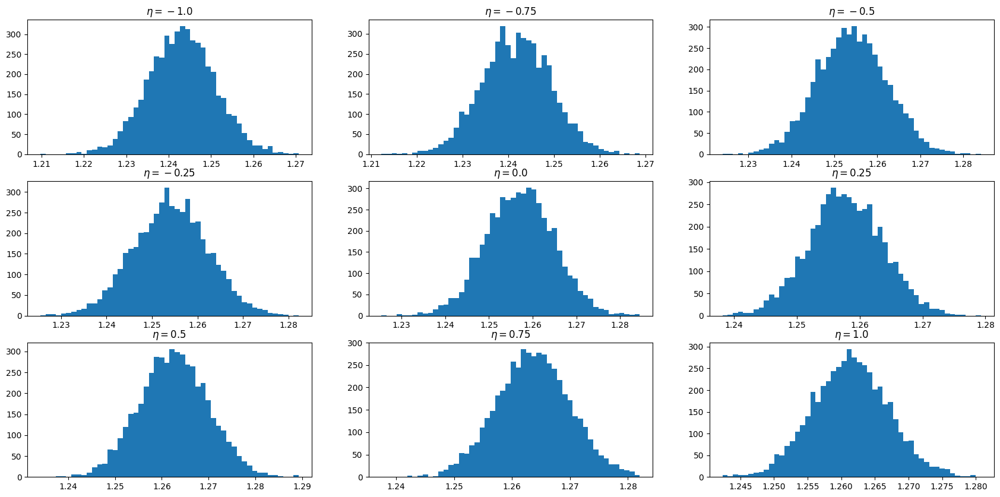

d


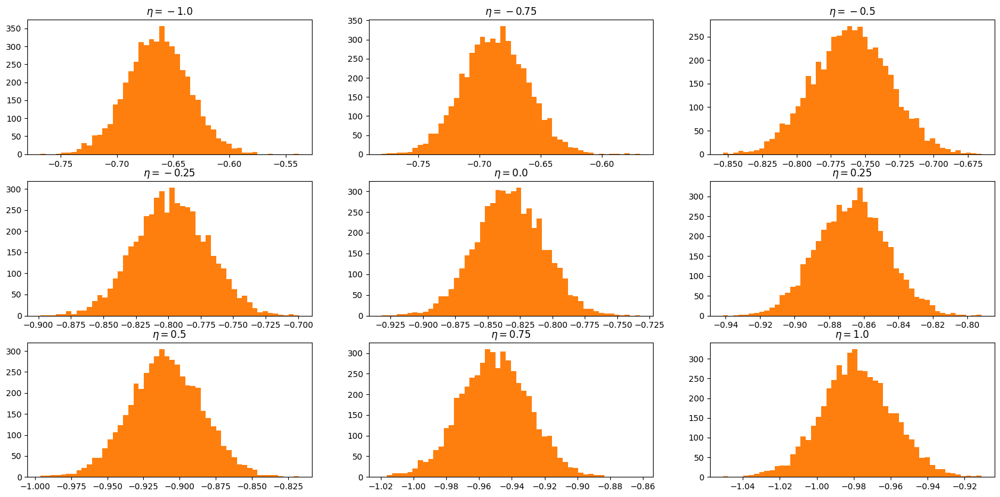

In [39]:
print("c")
fig,axs=plt.subplots(3, 3,figsize=(21,10))
for ei in range(len(eta_list)):
    axs=axs.flatten()
    axs[ei].hist(p_all[ei][:,0],bins=50,density=False,color='tab:blue')
    axs[ei].set_title(f"$\\eta={eta_list[ei]}$")

plt.show()

print("d")
fig,axs=plt.subplots(3, 3,figsize=(21,10))
for ei in range(len(eta_list)):
    axs=axs.flatten()
    axs[ei].hist(p_all[ei][:,1],bins=50,density=False,color='tab:orange')
    axs[ei].set_title(f"$\\eta={eta_list[ei]}$")

plt.show()

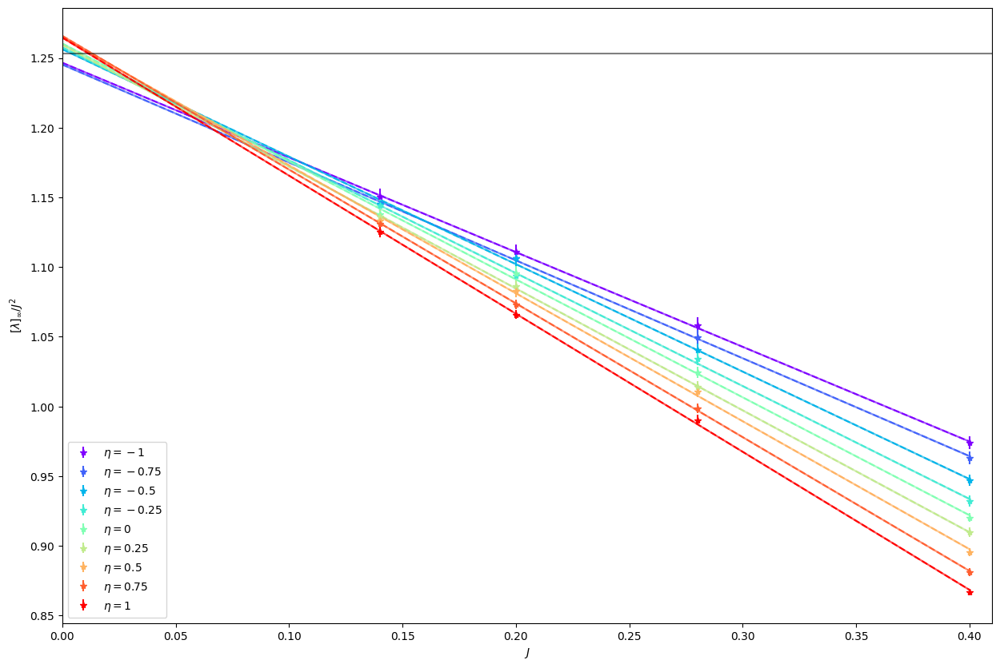

In [40]:
plt.figure(figsize=(15,10))

J_list=np.array([0.14,0.2,0.28,0.4])
eta_list = [-1,-0.75,-0.5,-0.25,0,0.25,0.5,0.75,1]

cmap = generate_colormap(len(eta_list), palette_type="continuous")

c1_boot=[]
d1_boot=[]
def f_fit1(J,p):
    return p[0]+p[1]*J

p_all_boot=[]

Jrange=np.linspace(0,J_list[-1])
Nboot=10000

for ei in range(len(eta_list)):
#    print(eta_list[ei])
    ydata=np.mean(linf_opt_boot[:,ei,:],axis=1)/J_list**2
    yerr=np.std(linf_opt_boot[:,ei,:],axis=1)/J_list**2
    
    plt.errorbar(J_list, ydata, yerr=yerr, color=cmap[ei],fmt="*",label=f"$\\eta={eta_list[ei]}$")
    #plt.scatter(J_list, ydata , color=cmap[ei],alpha=1,label=f"$\\eta={eta_list[ei]}$")
    
    pfit, perr, r2_1, pfits_all = fit_bootstrap_resample(J_list, linf_opt_boot[:,ei,:]/np.repeat(J_list,Nboot).reshape(len(J_list),Nboot)**2, lambda x,p: p[0]+p[1]*x, np.array([1.25,0.8]),Nsamples=5000,Nsigma=2,out_all=True)
    plt.plot(Jrange,f_fit1(Jrange,pfit),"--",alpha=0.9,color=adjust_lightness(cmap[ei],amount=1))
    for p in pfits_all[::500]:
        plt.plot(Jrange,f_fit1(Jrange,p),"-",alpha=0.1,color=cmap[ei])
    
    c1_boot.append([pfit[0],perr[0]])
    d1_boot.append([pfit[1],perr[1]])

    p_all_boot.append(pfits_all)
#    print(f"fit: {pfit}")
#    print(f"err: {perr}")
#    print(f"Fit 1: {r2_1}")

plt.axhline(np.sqrt(np.pi/2),color="k",alpha=0.5)

plt.xlabel("$J$")
plt.ylabel("$[\\lambda]_{\\infty}/J^2$")
plt.xlim(0.00,0.41)
#plt.yscale("log")
#plt.xscale("log")
#plt.ylim(1.06,1.22)
plt.legend()

#plt.xlim(8e-3,5e-1)
#plt.ylim(1e-4,3e-1)

plt.show()

c


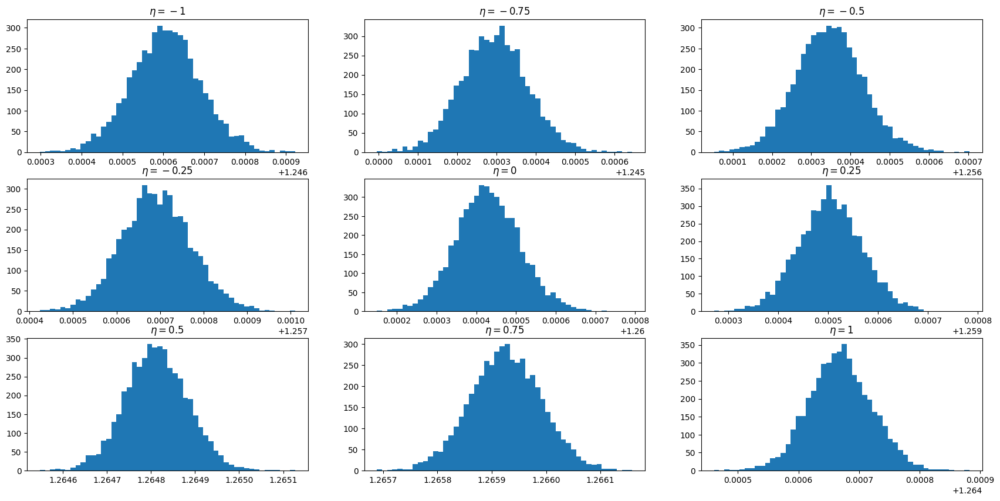

d


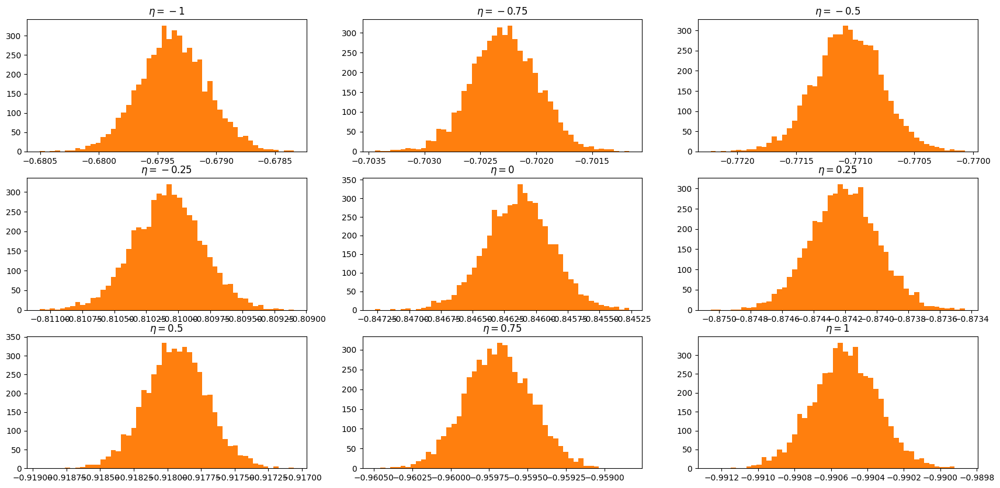

In [41]:
print("c")
fig,axs=plt.subplots(3, 3,figsize=(21,10))
for ei in range(len(eta_list)):
    axs=axs.flatten()
    axs[ei].hist(p_all_boot[ei][:,0],bins=50,density=False,color='tab:blue')
    axs[ei].set_title(f"$\\eta={eta_list[ei]}$")

plt.show()

print("d")
fig,axs=plt.subplots(3, 3,figsize=(21,10))
for ei in range(len(eta_list)):
    axs=axs.flatten()
    axs[ei].hist(p_all_boot[ei][:,1],bins=50,density=False,color='tab:orange')
    axs[ei].set_title(f"$\\eta={eta_list[ei]}$")

plt.show()

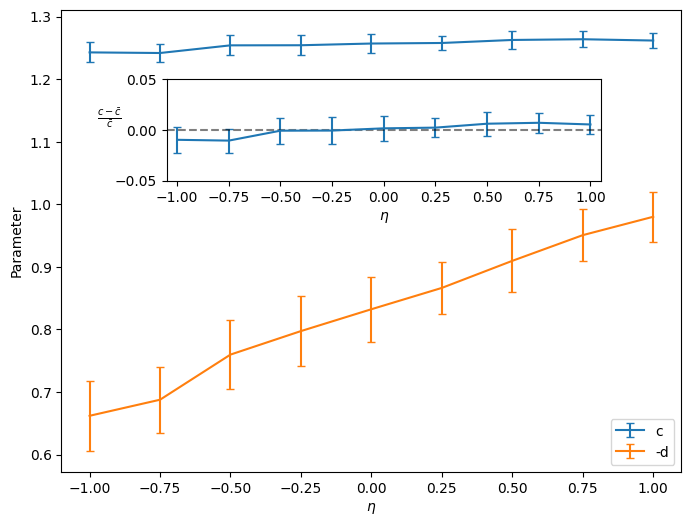

In [169]:
c=np.array(c1)
d=np.array(d1)

fig,ax=plt.subplots(figsize=(8,6))

ax.errorbar(eta_list,c[:,0],yerr=c[:,1],capsize=3,label="c")
ax.errorbar(eta_list,-d[:,0],yerr=d[:,1],capsize=3,label="-d")
#ax.set_ylim(0,3.6)
plt.xlabel("$\\eta$")
ax.set_ylabel("Parameter")
plt.legend(loc="lower right")

# inset Axes
x1,x2,y1,y2=-1.05,1.05,-0.05,0.05#subregion
axins=ax.inset_axes([0.17,0.63,0.7,0.22],xlim=(x1,x2),ylim=(y1,y2))
#ax.indicate_inset_zoom(axins,edgecolor="black")
axins.errorbar(eta_list,(c[:,0]-np.mean(c[:,0]))/np.mean(c[:,0]),capsize=3,yerr=c[:,1]/np.mean(c[:,0]))
axins.axhline(0,color="k",linestyle="--",alpha=0.5)
axins.set_xlabel("$\\eta$")
#axins.yaxis.set_label_position("right")
#axins.yaxis.tick_right()
axins.set_ylabel("$\\frac{c-\\bar{c}}{\\bar{c}}$",rotation=0)

plt.show()

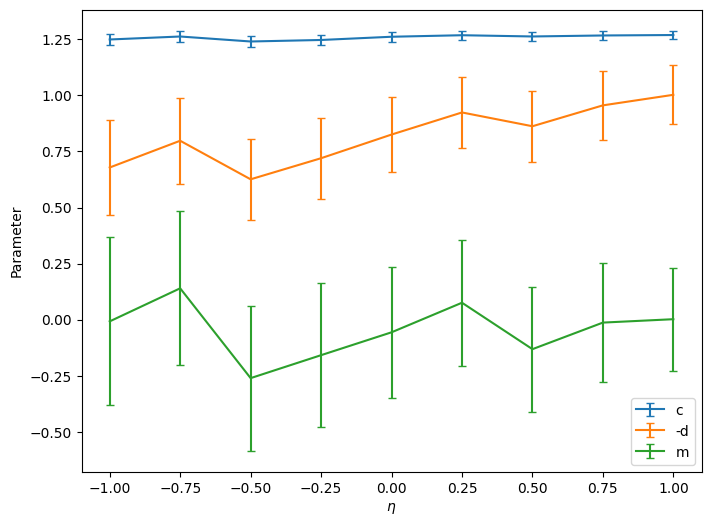

In [39]:
c=np.array(c12)
d=np.array(d12)
m=np.array(m12)

fig,ax=plt.subplots(figsize=(8,6))

ax.errorbar(eta_list,c[:,0],yerr=c[:,1],capsize=3,label="c")
ax.errorbar(eta_list,-d[:,0],yerr=d[:,1],capsize=3,label="-d")
ax.errorbar(eta_list,m[:,0],yerr=m[:,1],capsize=3,label="m")
#ax.set_ylim(0,3.6)
plt.xlabel("$\\eta$")
ax.set_ylabel("Parameter")
plt.legend(loc="lower right")

plt.show()

<ErrorbarContainer object of 3 artists>

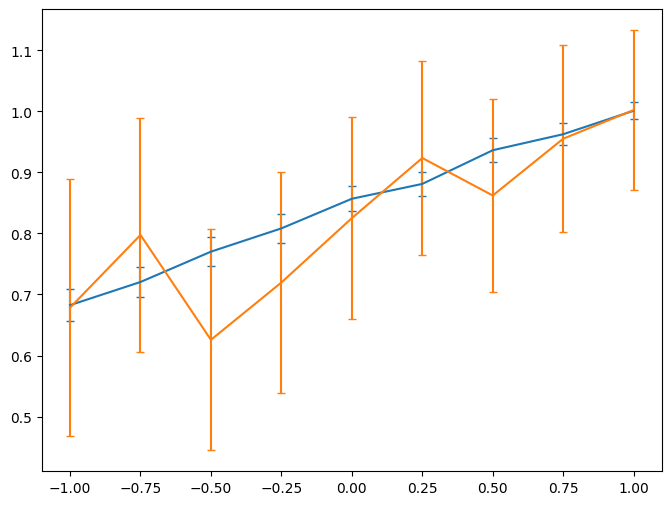

In [44]:
d1=np.array(d1)
d12=np.array(d12)

fig,ax=plt.subplots(figsize=(8,6))
ax.errorbar(eta_list,-d1[:,0],yerr=d1[:,1],capsize=3,label="-d1")
ax.errorbar(eta_list,-d12[:,0],yerr=d12[:,1],capsize=3,label="-d12")

## Some not organized extra figures

In [45]:
x=np.geomspace(0.01,0.4,num=20)
x.round(3)

array([0.01 , 0.012, 0.015, 0.018, 0.022, 0.026, 0.032, 0.039, 0.047,
       0.057, 0.07 , 0.085, 0.103, 0.125, 0.152, 0.184, 0.223, 0.271,
       0.329, 0.4  ])

In [50]:
0.125/np.sqrt(2)

0.08838834764831843

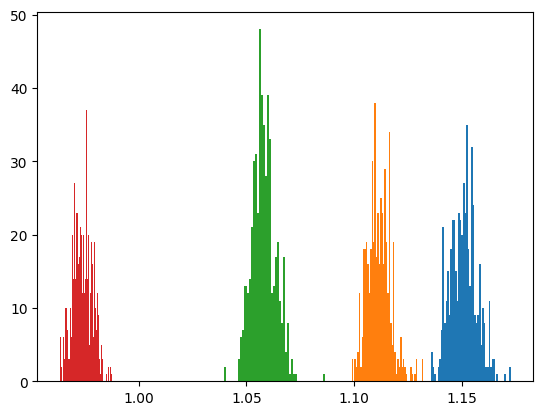

In [142]:
from sklearn.utils import resample

for Ji in range(len(J_list)):
    plt.hist(resample(linf_opt[:,0,:].T, replace=True, random_state=np.random.randint(1000)).T[Ji,:]/J_list[Ji]**2,bins=50,density=False);
plt.show()
#plt.xlim(0.0221,0.023)

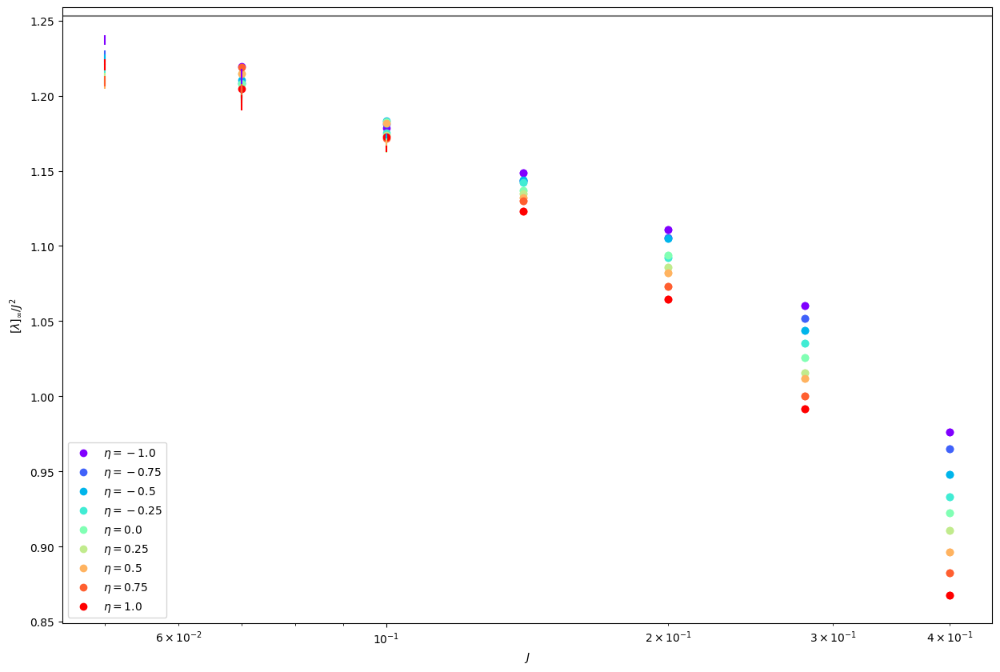

In [86]:
plt.figure(figsize=(15,10))

J_list=linf_df_mean["J"].unique()
eta_list=linf_df_mean["eta"].unique()

cmap = generate_colormap(len(eta_list), palette_type="continuous")

xrange=np.linspace(0,0.3,num=100)

for ei in range(len(eta_list)):
    ydata=linf_df_mean[(linf_df_mean["eta"]==eta_list[ei]) & (linf_df_mean["J"].isin(J_list))]["linf_opt"]/J_list**2
    plt.scatter(J_list, ydata, color=cmap[ei])

J_list=J_list[2:]

for ei in range(len(eta_list)):
    ydata=linf_df_mean[(linf_df_mean["eta"]==eta_list[ei]) & (linf_df_mean["J"].isin(J_list))]["linf_opt"]/J_list**2
    plt.scatter(J_list, ydata , color=cmap[ei],alpha=1,label=f"$\\eta={eta_list[ei]}$")
    

for ei in range(len(eta_list)):
    J=0.05
    tempdf=mean_pd[mean_pd["J"]==J]
    N=tempdf["N"].unique()[-2]
    tempdf=tempdf[tempdf["N"]==N]
    plt.errorbar(J, tempdf[tempdf["eta"]==eta_list[ei]]["lambda"]/J**2, tempdf[tempdf["eta"]==eta_list[ei]]["err_lambda"]/J**2,capsize=3,color=cmap[ei],alpha=1)
    
    for J in [0.07,0.1]:
        tempdf=mean_pd[mean_pd["J"]==J]
        N=tempdf["N"].unique()[-1]
        tempdf=tempdf[tempdf["N"]==N]
        plt.errorbar(J, tempdf[tempdf["eta"]==eta_list[ei]]["lambda"]/J**2, tempdf[tempdf["eta"]==eta_list[ei]]["err_lambda"]/J**2, color=cmap[ei],alpha=1)

plt.axhline(np.sqrt(np.pi/2),color="k",alpha=0.5)

plt.xlabel("$J$")
plt.ylabel("$[\\lambda]_{\\infty}/J^2$")
plt.xscale("log")
plt.legend()

plt.show()

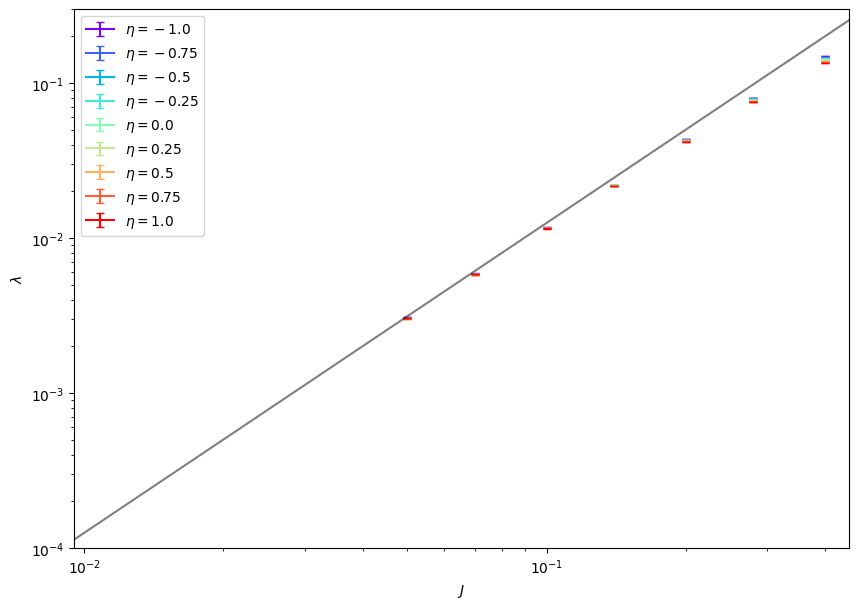

In [40]:
plt.figure(figsize=(10,7))

J_list=[0.05,0.07,0.1,0.14,0.2,0.28,0.4]
eta_list=linf_df_mean["eta"].unique()

cmap = generate_colormap(len(eta_list), palette_type="continuous")

xrange=np.geomspace(0.005,0.5,num=1000)

for ei in range(len(eta_list)):
    J=0.05
    tempdf=mean_pd[mean_pd["J"]==J]
    N=tempdf["N"].unique()[-2]
    tempdf=tempdf[tempdf["N"]==N]
    plt.errorbar(J, tempdf[tempdf["eta"]==eta_list[ei]]["lambda"], tempdf[tempdf["eta"]==eta_list[ei]]["err_lambda"],capsize=3, color=cmap[ei],label=f"$\\eta={eta_list[ei]}$",alpha=1)
    
    for J in J_list[1:]:
        tempdf=mean_pd[mean_pd["J"]==J]
        N=tempdf["N"].unique()[-2]
        tempdf=tempdf[tempdf["N"]==N]
        plt.errorbar(J, tempdf[tempdf["eta"]==eta_list[ei]]["lambda"], tempdf[tempdf["eta"]==eta_list[ei]]["err_lambda"],capsize=3 ,color=cmap[ei],alpha=1)

plt.plot(xrange,np.sqrt(np.pi/2)*(xrange**2),color="k",alpha=0.5)

plt.xlabel("$J$")
plt.ylabel("$\\lambda$")
plt.xscale("log")
plt.yscale("log")

plt.xlim(0.0095,0.45)
plt.ylim(1e-4,3e-1)
plt.legend()

plt.show()

# FTLE Diffusion

In [45]:
from numpy.lib.stride_tricks import sliding_window_view
filebase=os.path.expanduser('~')+"/Desktop"

In [62]:
def fluctLoop(inFileName,outFileName,Tlyap,ndiv=26):
    T=np.empty(ndiv,dtype=int)
    fluct=np.empty(ndiv,dtype=np.float64)

    T[0]=1
    T[1]=2

    ftle=np.fromfile(inFileName,dtype=np.float64)
    Nfile=len(ftle)
    le=np.mean(ftle)
    
    T[2:]=np.geomspace(3,Nfile,num=ndiv-2,endpoint=False,dtype=int)
    
    for i in range(ndiv):
        w = T[i]
        
        windows = sliding_window_view(ftle, window_shape=w)  
    
        letr_arr = windows.mean(axis=1)
        fluct[i] = np.mean((letr_arr - le) ** 2)
    
        print(f"  division {i+1}: T={w}, windows={len(letr_arr)}, fluct={fluct[i]:.4e}")

    np.savetxt(outFileName,np.column_stack((T*Tlyap,fluct)))
        
    return T,fluct

In [63]:
N_list=[100,200,400]
eta_list=["-1","0","1"]

for e in eta_list:
    for n in N_list:
        print(f"eta={e}, N={n}")
        
        inF=filebase+f"/FTLEdata/N{n}/a0_J0.2_e{e}_l10_MLE.dat"
        outF=filebase+f"/KuramotoData/diffFTLE/J0.2/a0_J0.2_N{n}_e{e}_fluct.txt"
        
        fluctLoop(inF,outF,10)

eta=-1, N=100
  division 1: T=1, windows=500000, fluct=5.2834e-04
  division 2: T=2, windows=499999, fluct=2.6708e-04
  division 3: T=3, windows=499998, fluct=1.7722e-04
  division 4: T=4, windows=499997, fluct=1.3356e-04
  division 5: T=8, windows=499993, fluct=6.8777e-05
  division 6: T=13, windows=499988, fluct=4.3542e-05
  division 7: T=22, windows=499979, fluct=2.6402e-05
  division 8: T=36, windows=499965, fluct=1.6474e-05
  division 9: T=60, windows=499941, fluct=1.0027e-05
  division 10: T=100, windows=499901, fluct=6.0531e-06
  division 11: T=165, windows=499836, fluct=3.7067e-06
  division 12: T=272, windows=499729, fluct=2.2601e-06
  division 13: T=449, windows=499552, fluct=1.3589e-06
  division 14: T=742, windows=499259, fluct=8.2299e-07
  division 15: T=1224, windows=498777, fluct=4.8319e-07
  division 16: T=2021, windows=497980, fluct=2.8751e-07
  division 17: T=3335, windows=496666, fluct=1.7948e-07
  division 18: T=5505, windows=494496, fluct=1.1693e-07
  division 19: 

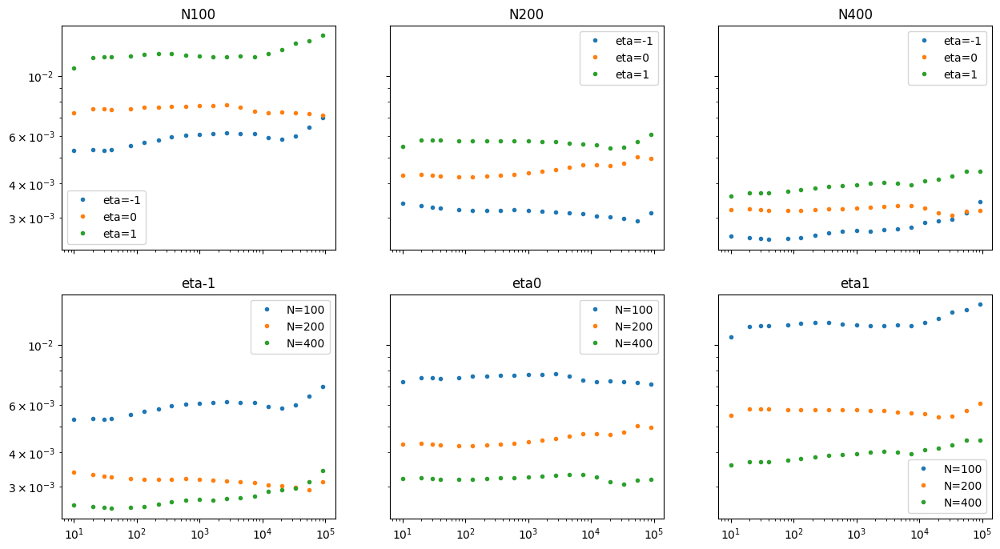

In [69]:
N_list=[100,200,400]
eta_list=["-1","0","1"]

fig,axs=plt.subplots(2,len(eta_list),sharex=True,sharey=True,figsize=(15,8))
for i in range(len(N_list)):
    for j in range(len(eta_list)):
        
        data=np.loadtxt(filebase+f"/KuramotoData/diffFTLE/J0.2/a0_J0.2_N{N_list[i]}_e{eta_list[j]}_fluct.txt")
        data=data[:-7,:]
        
        axs[0,i].plot(data[:,0],data[:,1]*data[:,0],".",label=f"eta={eta_list[j]}")
        axs[1,j].plot(data[:,0],data[:,1]*data[:,0],".",label=f"N={N_list[i]}")

        axs[0,i].set_title(f"N{N_list[i]}")
        axs[1,j].set_title(f"eta{eta_list[j]}")
        

for ax in axs.flatten():
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()

plt.show()



In [83]:
def fluctLoop(N,ndiv):
    
    T=np.empty((ndiv,len(N)),dtype=int)
    fluct=np.empty((ndiv,len(N)),dtype=np.float64)
    
    T[0]=np.ones(len(N))
    T[1]=T[0]*2
    
    for ni in range(len(N)):
        print(f"N={N[ni]}")
        
        ftle=np.fromfile(filebase+f"/testFTLE_MLE_N{N[ni]}.dat",dtype=np.float64)
        Nfile=len(ftle)
        le=np.mean(ftle)
        
        T[2:,ni]=np.geomspace(3,Nfile,num=ndiv-2,endpoint=False,dtype=int)
        
        for i in range(ndiv):
            w = T[i,ni]
            
            windows = sliding_window_view(ftle, window_shape=w)  
        
            letr_arr = windows.mean(axis=1)
            fluct[i,ni] = np.mean((letr_arr - le) ** 2)
        
            print(f"  division {i+1}: T={w}, windows={len(letr_arr)}, fluct={fluct[i,ni]:.4e}")

    return T,fluct

e=-1
N=100
100000
N=200
100000


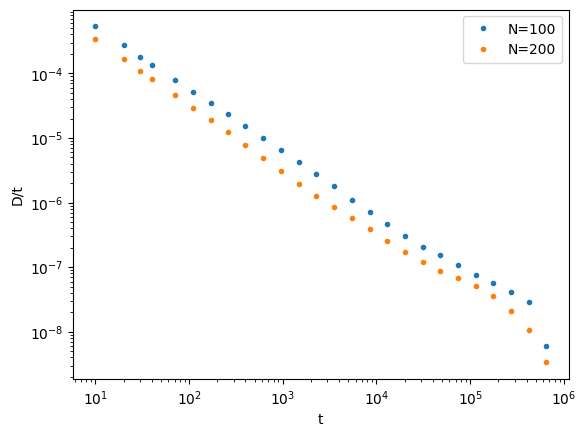

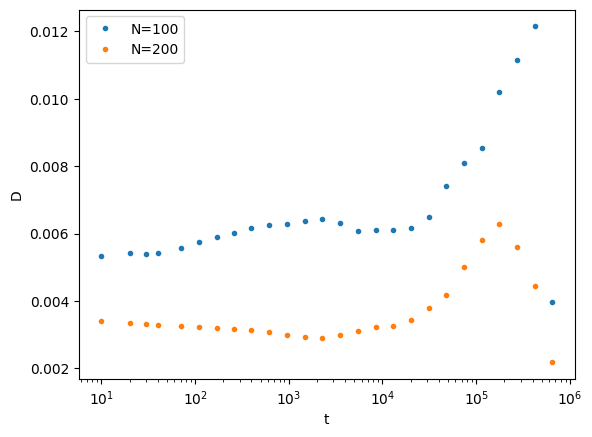

e=0
N=100
100000
N=200
100000


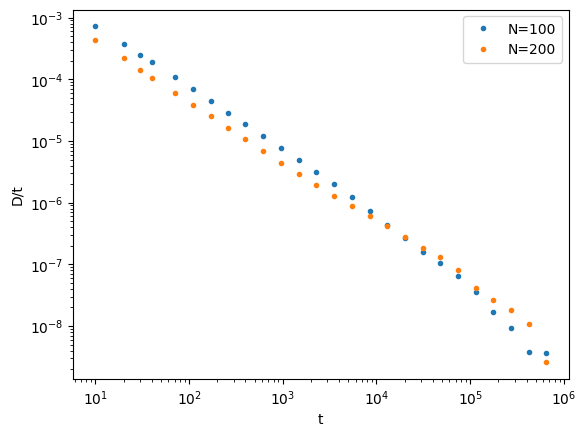

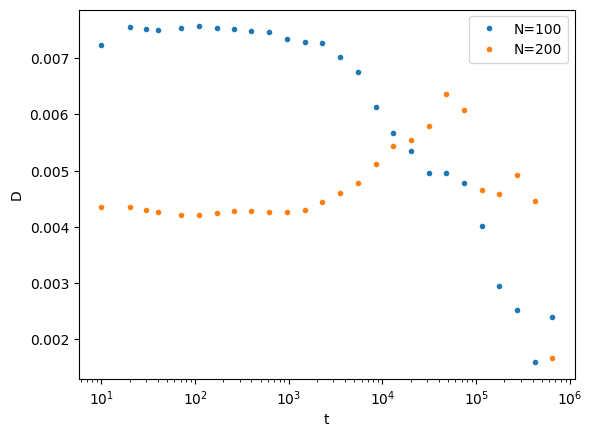

e=1
N=100
100000
N=200
100000


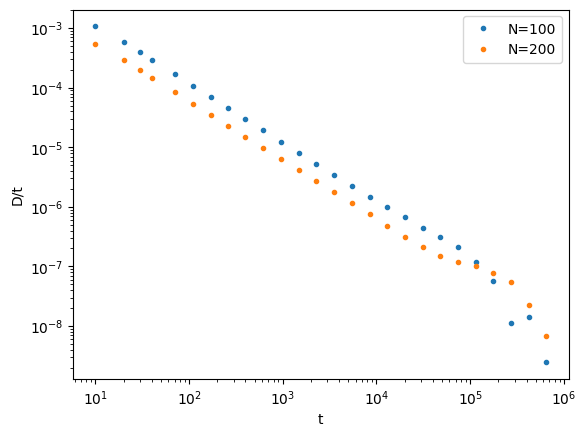

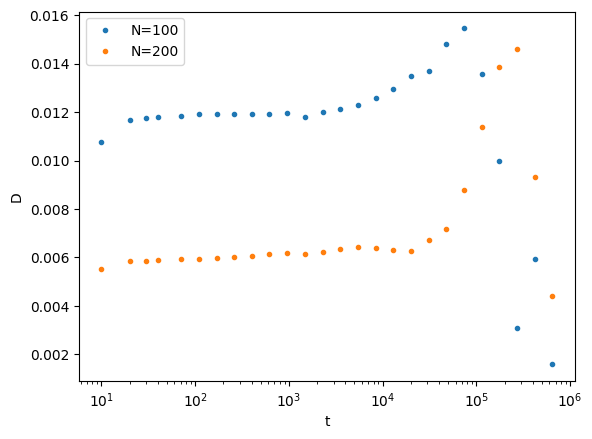

In [99]:
N=[100,200]
ndiv=26

T=np.empty((ndiv,len(N)),dtype=int)
fluct=np.empty((ndiv,len(N)),dtype=np.float64)

T[0]=np.ones(len(N))
T[1]=T[0]*2

for e in ["-1","0","1"]:
    print(f"e={e}")
    for ni in range(len(N)):
        print(f"N={N[ni]}")
        
        ftle=np.fromfile(filebase+f"/N{N[ni]}/a0_J0.2_e{e}_MLE.dat",dtype=np.float64)
        Nfile=len(ftle)
        le=np.mean(ftle)
        print(Nfile)
        
        T[2:,ni]=np.geomspace(3,Nfile,num=ndiv-2,endpoint=False,dtype=int)
        
        for i in range(ndiv):
            w = T[i,ni]
            
            windows = sliding_window_view(ftle, window_shape=w)  
        
            letr_arr = windows.mean(axis=1)
            fluct[i,ni] = np.mean((letr_arr - le) ** 2)
        
#            print(f"  division {i+1}: T={w}, windows={len(letr_arr)}, fluct={fluct[i,ni]:.4e}")
    
    plt.plot(T*10,fluct,".")
    plt.yscale("log")
    plt.xscale("log")
    plt.ylabel("D/t")
    plt.xlabel("t")
    plt.legend(labels=[f"N={n}" for n in N])
    plt.show()
    
    plt.plot(T*10,fluct*T*10,".")
    plt.legend(labels=[f"N={n}" for n in N])
    plt.ylabel("D")
    plt.xscale("log")
    plt.xlabel("t")
    plt.show()

In [105]:
path=os.path.expanduser('~')+"/Desktop/KuramotoData/diffFTLE/"
l=[1,5,10]
T=np.empty((ndiv,len(l)),dtype=int)
fluct=np.empty((ndiv,len(l)),dtype=np.float64)

T[0]=np.ones(len(l))
T[1]=T[0]*2

for li in range(len(l)):
    print(f"l={l[li]}")
    
    ftle=np.fromfile(path+f"/testFTLE_MLE_N100_l{l[li]}.dat",dtype=np.float64)
    Nfile=len(ftle)
    le=np.mean(ftle)
    
    T[2:,li]=np.geomspace(3,Nfile,num=ndiv-2,endpoint=False,dtype=int)
    
    for i in range(ndiv):
        w = T[i,li]
        
        windows = sliding_window_view(ftle, window_shape=w)  
    
        letr_arr = windows.mean(axis=1)
        fluct[i,li] = np.mean((letr_arr - le) ** 2)
    
        print(f"  division {i+1}: T={w}, windows={len(letr_arr)}, fluct={fluct[i,li]:.4e}")

l=1
  division 1: T=1, windows=100000, fluct=2.4897e-03
  division 2: T=2, windows=99999, fluct=1.9338e-03
  division 3: T=3, windows=99998, fluct=1.5051e-03
  division 4: T=4, windows=99997, fluct=1.2094e-03
  division 5: T=7, windows=99994, fluct=7.4357e-04
  division 6: T=11, windows=99990, fluct=4.9359e-04
  division 7: T=17, windows=99984, fluct=3.2136e-04
  division 8: T=26, windows=99975, fluct=2.0681e-04
  division 9: T=40, windows=99961, fluct=1.3607e-04
  division 10: T=62, windows=99939, fluct=8.9765e-05
  division 11: T=96, windows=99905, fluct=5.9234e-05
  division 12: T=149, windows=99852, fluct=3.9172e-05
  division 13: T=229, windows=99772, fluct=2.6403e-05
  division 14: T=354, windows=99647, fluct=1.7450e-05
  division 15: T=547, windows=99454, fluct=1.1711e-05
  division 16: T=845, windows=99156, fluct=7.9929e-06
  division 17: T=1304, windows=98697, fluct=5.2951e-06
  division 18: T=2013, windows=97988, fluct=3.2626e-06
  division 19: T=3107, windows=96894, fluct=1.

In [81]:
N=[100,200,1600]
ndiv=26 #No particular reason dw
T,fluct=fluctLoop(N,ndiv)

N=100
  division 1: T=1, windows=77824, fluct=5.3294e-04
  division 2: T=2, windows=77823, fluct=2.6968e-04
  division 3: T=3, windows=77822, fluct=1.7894e-04
  division 4: T=4, windows=77821, fluct=1.3505e-04
  division 5: T=6, windows=77819, fluct=9.1483e-05
  division 6: T=10, windows=77815, fluct=5.6775e-05
  division 7: T=16, windows=77809, fluct=3.6668e-05
  division 8: T=24, windows=77801, fluct=2.5001e-05
  division 9: T=38, windows=77787, fluct=1.6371e-05
  division 10: T=58, windows=77767, fluct=1.1006e-05
  division 11: T=88, windows=77737, fluct=7.3951e-06
  division 12: T=135, windows=77690, fluct=4.9487e-06
  division 13: T=207, windows=77618, fluct=3.3336e-06
  division 14: T=316, windows=77509, fluct=2.1961e-06
  division 15: T=483, windows=77342, fluct=1.4102e-06
  division 16: T=737, windows=77088, fluct=9.1762e-07
  division 17: T=1127, windows=76698, fluct=5.9831e-07
  division 18: T=1721, windows=76104, fluct=3.9627e-07
  division 19: T=2628, windows=75197, fluct=2

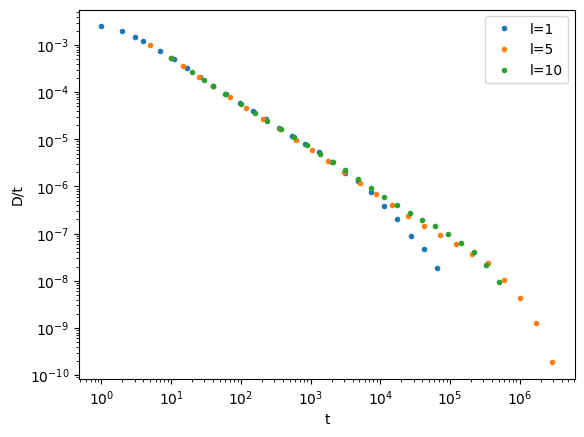

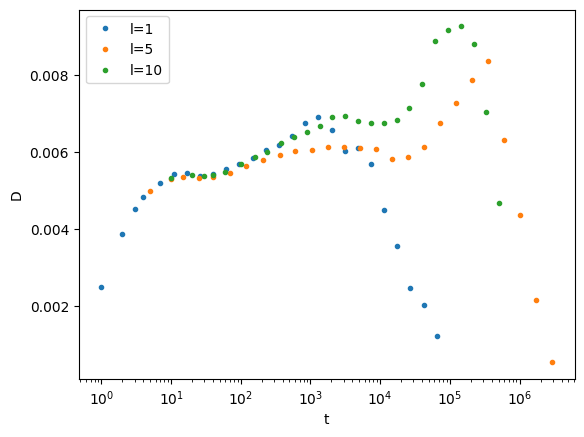

In [106]:
plt.plot(T*l,fluct,".")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("D/t")
plt.xlabel("t")
plt.legend(labels=[f"l={li}" for li in l])
plt.show()

plt.plot(T*l,fluct*T*l,".")
plt.legend(labels=[f"l={li}" for li in l])
plt.ylabel("D")
plt.xscale("log")
plt.xlabel("t")
plt.show()

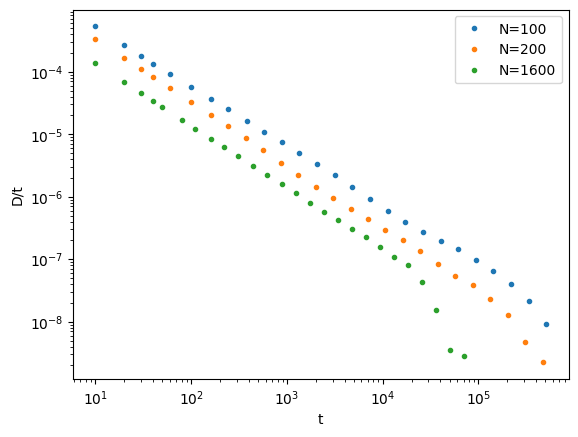

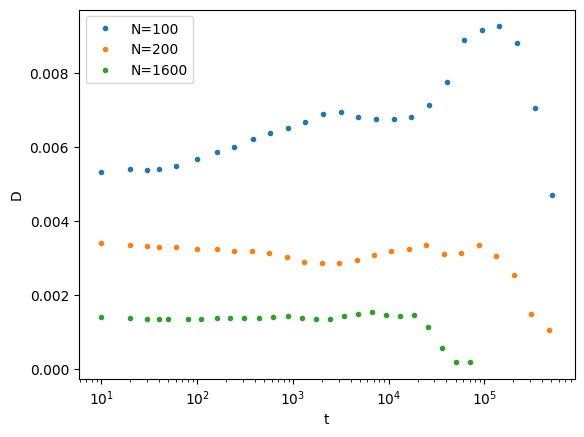

In [82]:
plt.plot(T*10,fluct,".")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("D/t")
plt.xlabel("t")
plt.legend(labels=[f"N={n}" for n in N])
plt.show()

plt.plot(T*10,fluct*T*10,".")
plt.legend(labels=[f"N={n}" for n in N])
plt.ylabel("D")
plt.xscale("log")
plt.xlabel("t")
plt.show()